# Etapa 00 - Contexto e Objetivo

### Regime de Fogo em Unidades de Conservação — Classificação em Pirorregiões

Esse projeto nasceu de uma pergunta simples: dá pra entender melhor como o fogo se comporta dentro das Unidades de Conservação federais, olhando não pra vegetação ou pro clima, mas pro próprio padrão do fogo?

A ideia vem de um conceito chamado pirorregião (pyroma), que trata o fogo como algo que tem características próprias, medíveis, que podem ser usadas pra agrupar territórios por semelhança. Duas áreas podem ter vegetação parecida e regime de fogo bem diferente, ou o contrário. Em vez de assumir que fogo e bioma andam sempre juntos, a proposta é medir o comportamento do fogo diretamente e deixar os padrões emergirem dos dados.

A metodologia usada aqui é inspirada no trabalho de Archibald et al, que definiu esse conceito olhando pra cinco características centrais de qualquer regime de fogo:

- frequência, de quanto em quanto tempo uma área volta a queimar
- intensidade, quanta energia o fogo libera quando ocorre
- sazonalidade, em que época do ano o fogo se concentra
- tamanho, a extensão do maior evento já registrado
- extensão média, quanto território queima, em média, todo ano

Essas cinco variáveis são calculadas pixel a pixel, ou no nosso caso célula a célula, numa grade espacial cobrindo o território que queremos estudar. Depois, um algoritmo de clusterização agrupa as células que têm combinações parecidas dessas cinco variáveis, formando grupos. Esses grupos são as pirorregiões, e cada uma representa um tipo distinto de comportamento do fogo, não um tipo de vegetação ou clima:

- FIL (Frequent Intense Large): fogo frequente, intenso e de grande extensão
- FCS (Frequent Cool Small): fogo frequente, de baixa intensidade e pequena extensão
- RIL (Rare Intense Large): fogo raro, intenso e de grande extensão. 
- RCS (Rare Cool Small): fogo raro, de baixa intensidade e pequena extensão.
- ICS (Intermediate Cool Small): fogo de frequência intermediária, baixa intensidade e pequena extensão.

O objetivo final do projeto é gerar essa classificação para o território das Unidades de Conservação federais brasileiras, entender o que cada pirorregião resultante representa em termos práticos, e usar isso como ponto de partida pra pensar estratégias de manejo do fogo mais adequadas a cada contexto, em vez de aplicar a mesma lógica em todo lugar.

---

Esse é um projeto em construção, com decisões metodológicas sendo tomadas e registradas conforme o trabalho avança pelas etapas de preparação dos dados, análise exploratória, pré-processamento e classificação.

In [2]:
# Bibliotecas padrão
import os
import gc
import json
import shutil
import zipfile

# Bibliotecas de terceiros
import ee
import geemap
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, silhouette_samples
from sklearn.mixture import GaussianMixture
from shapely.geometry import box
from sklearn.cluster import KMeans
from io import BytesIO
from glob import glob

print("Bibliotecas carregadas")

Bibliotecas carregadas


In [3]:
# Roda o comando no terminal : earthengine authenticate --auth_mode=notebook
ee.Authenticate()
ee.Initialize(project="spatial-yew-490017-r3")
print(ee.String("Hello from the Earth Engine servers!").getInfo())

Hello from the Earth Engine servers!


In [4]:
# mostrar todas as colunas
pd.set_option("display.max_columns", None)

# não quebrar a largura da tabela
pd.set_option("display.expand_frame_repr", False)

# opcional: aumentar a largura máxima exibida
pd.set_option("display.width", 1000)

In [5]:
os.environ["GDAL_DATA"] = os.path.join(
    os.environ["CONDA_PREFIX"], "Library", "share", "gdal"
)
os.environ["PROJ_LIB"] = os.path.join(
    os.environ["CONDA_PREFIX"], "Library", "share", "proj"
)

In [6]:
FILES_DIR = "files"
os.makedirs(FILES_DIR, exist_ok=True)

PRINTS_DIR = os.path.join(FILES_DIR, "prints")
os.makedirs(PRINTS_DIR, exist_ok=True)

In [7]:
def load_prepared_data(files_dir):
    outputs_dir = os.path.join(files_dir, "prepared")

    gdf_grid = gpd.read_parquet(os.path.join(outputs_dir, "grid.parquet"))
    cell_uc_membership = pd.read_parquet(os.path.join(outputs_dir, "cell_uc_membership.parquet"))
    gdf_aaf_metric = gpd.read_parquet(os.path.join(outputs_dir, "aaf_clipped.parquet"))
    aaf_events_unique = gpd.read_parquet(os.path.join(outputs_dir, "aaf_events_unique.parquet"))
    gdf_inpe_with_cell = gpd.read_parquet(os.path.join(outputs_dir, "inpe_with_cell.parquet"))
    gdf_ucs_metric = gpd.read_parquet(os.path.join(outputs_dir, "ucs_metric.parquet"))

    print("Grid:", gdf_grid.shape)
    print("Cell-UC membership:", cell_uc_membership.shape)
    print("AAF (recortado por célula):", gdf_aaf_metric.shape)
    print("AAF (eventos únicos):", aaf_events_unique.shape)
    print("INPE:", gdf_inpe_with_cell.shape)
    print("UCs:", gdf_ucs_metric.shape)

    return gdf_grid, cell_uc_membership, gdf_aaf_metric, aaf_events_unique, gdf_inpe_with_cell, gdf_ucs_metric

In [8]:
def seasonal_window(months, coverage=0.8):
    # quantos meses (do mais ativo ao menos ativo) somam a cobertura desejada
    counts = months.value_counts().sort_values(ascending=False)
    cumulative = counts.cumsum() / counts.sum()
    return (cumulative <= coverage).sum() + 1

# Etapa 01 - Importação dos dados
O projeto usa três fontes de dado, cada uma cumprindo um papel específico dentro das cinco variáveis do regime de fogo.

**Limites das Unidades de Conservação**

Vem do serviço WFS da INDE, mantido pelo ICMBio. É a base espacial de tudo, define onde fica cada UC e serve pra recortar a grade de células que vai ser usada no resto do projeto, sem esses limites não tem como saber quais eventos de fogo e quais focos de calor pertencem a qual UC.

**AAF, Área Afetada por Fogo (ICMBio)**

Registros de cicatrizes de fogo já confirmadas, mapeadas ano a ano desde 2010 até o ano corrente. Cada registro tem data, área queimada e a UC onde ocorreu. É a fonte usada pra calcular frequência, sazonalidade, tamanho do evento e extensão média anual, porque representa fogo que de fato aconteceu e foi validado, não só uma suspeita de calor detectada por satélite.

O acesso é feito via API do ArcGIS FeatureServer do ICMBio. Um detalhe importante descoberto ao longo do projeto: o nome do serviço muda de ano pra ano (às vezes até o esquema de colunas muda), então o download precisa lidar com essas variações e depois harmonizar tudo numa estrutura só antes de usar.

**Foco de calor (INPE)**

Detecções térmicas por satélite, disponíveis desde 2003. Diferente do AAF, um foco de calor não significa necessariamente uma cicatriz de fogo confirmada, é só uma anomalia térmica captada do espaço. Por isso essa fonte é usada só pra calcular intensidade, que é medida em energia radiativa e só o INPE fornece esse dado.

O download é feito ano a ano, direto do servidor público de dados abertos do INPE.

### Unidades de Conservação Federais - INDE/ICMBio

In [9]:
# Limites das UCs federais, via serviço WFS da INDE/ICMBio

ucs_dir = os.path.join(FILES_DIR, "limites_ucs")
os.makedirs(ucs_dir, exist_ok=True)

uc_typename = "ICMBio:limiteucsfederais_a"
uc_output_path = os.path.join(ucs_dir, "limites_ucs.geojson")

if os.path.exists(uc_output_path):
    print(f"Already downloaded: {uc_output_path}")
else:
    wfs_url = (
        "https://geoservicos.inde.gov.br/geoserver/ICMBio/ows"
        f"?service=WFS&version=2.0.0&request=GetFeature"
        f"&typeName={uc_typename}&outputFormat=application/json"
    )
    response = requests.get(wfs_url, timeout=180, verify=False)
    response.raise_for_status()
    with open(uc_output_path, "wb") as f:
        f.write(response.content)
    print(f"Saved: {uc_output_path}")

gdf_ucs = gpd.read_file(uc_output_path)

print("Shape:", gdf_ucs.shape)
print("Columns:", gdf_ucs.columns.tolist())
print("CRS:", gdf_ucs.crs)

Already downloaded: files\limites_ucs\limites_ucs.geojson
Shape: (347, 22)
Columns: ['ogc_fid', 'id', 'nomeuc', 'cnuc', 'criacaoano', 'areahaalb', 'perimm', 'criacaoato', 'esferaadm', 'grupouc', 'biomas', 'gregional', 'fusoabrang', 'demarcacao', 'escalauc', 'bioma_pred', 'cat_iucn', 'uf', 'categoria_', 'sigla_cate', 'dominio', 'geometry']
CRS: EPSG:4674


In [10]:
# Reprojetar para CRS métrico, necessário pra qualquer cálculo de área ou distância real

METRIC_CRS = "EPSG:5880"  # SIRGAS 2000 / Brazil Polyconic

gdf_ucs_metric = gdf_ucs.to_crs("EPSG:5880")
gdf_ucs_metric["geometry"] = gdf_ucs_metric.geometry.buffer(0)  # corrige geometrias inválidas

print("Geometrias inválidas em gdf_ucs_metric:", (~gdf_ucs_metric.is_valid).sum())

Geometrias inválidas em gdf_ucs_metric: 0


### Foco de Calor  INPE

In [11]:
# Download do foco de calor, ano a ano


inpe_dir = os.path.join(FILES_DIR, "inpe_focos")
os.makedirs(inpe_dir, exist_ok=True)

INPE_YEARS = [2003, 2025]
inpe_years_to_download = (
    INPE_YEARS
    if len(INPE_YEARS) == 1
    else list(range(min(INPE_YEARS), max(INPE_YEARS) + 1))
)


inpe_downloaded_files = {}

for year in inpe_years_to_download:

    csv_filename = f"focos_br_ref_{year}.csv"
    csv_path = os.path.join(inpe_dir, csv_filename)

    if os.path.exists(csv_path):
        inpe_downloaded_files[year] = csv_path
        continue

    zip_url = f"https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/anual/Brasil_todos_sats/focos_br_todos-sats_{year}.zip"

    try:
        response = requests.get(zip_url, timeout=180)
        response.raise_for_status()

        tmp_dir = os.path.join(inpe_dir, f"tmp_{year}")
        os.makedirs(tmp_dir, exist_ok=True)

        with zipfile.ZipFile(BytesIO(response.content)) as z:
            z.extractall(tmp_dir)

        found_csvs = glob(os.path.join(tmp_dir, "**", "*.csv"), recursive=True)

        if found_csvs:
            shutil.move(found_csvs[0], csv_path)
            inpe_downloaded_files[year] = csv_path
        else:
            print(f"[{year}] No CSV found in zip")

        shutil.rmtree(tmp_dir, ignore_errors=True)

    except requests.exceptions.RequestException:
        print(f"[{year}] Download failed")

print("Done:", list(inpe_downloaded_files.keys()))

Done: [2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [12]:
# Leitura e filtro espacial do foco de calor, ano a ano
# Processar um ano por vez evita estourar memória com o volume total (dezenas de milhões de linhas)

colunas_necessarias = [
    "latitude", "longitude", "data_pas", "satelite", "bioma",
    "estado", "municipio", "frp", "risco_fogo", "numero_dias_sem_chuva",
]

dtypes_reduzidos = {
    "satelite": "category", "bioma": "category", "estado": "category",
    "municipio": "category", "frp": "float32", "risco_fogo": "float32",
    "numero_dias_sem_chuva": "float32", "latitude": "float64", "longitude": "float64",
}

inpe_df_list = []

for year, path in inpe_downloaded_files.items():

    df_year = pd.read_csv(path, usecols=colunas_necessarias, dtype=dtypes_reduzidos)

    # geometria temporária, só pra filtrar espacialmente este ano, descartada em seguida
    points_year = gpd.GeoDataFrame(
        df_year[["latitude", "longitude"]],
        geometry=gpd.points_from_xy(df_year["longitude"], df_year["latitude"]),
        crs="EPSG:4326",
    ).to_crs(METRIC_CRS)

    matched = gpd.sjoin(
        points_year, gdf_ucs_metric[["cnuc", "geometry"]],
        how="inner", predicate="within",
    )

    df_year_filtered = df_year.loc[matched.index].copy()
    df_year_filtered["file_year"] = year

    print(f"[{year}] Total: {len(df_year)} | Dentro de alguma UC: {len(df_year_filtered)}")

    inpe_df_list.append(df_year_filtered)

    del df_year, points_year, matched, df_year_filtered
    gc.collect()

df_inpe = pd.concat(inpe_df_list, ignore_index=True)
del inpe_df_list
gc.collect()

print("\nShape final, já filtrado por UC:", df_inpe.shape)
print("Anos presentes:", sorted(df_inpe["file_year"].unique()))

[2003] Total: 966656 | Dentro de alguma UC: 29283
[2004] Total: 1149637 | Dentro de alguma UC: 34684
[2005] Total: 1075006 | Dentro de alguma UC: 33264
[2006] Total: 678258 | Dentro de alguma UC: 23871
[2007] Total: 1153803 | Dentro de alguma UC: 38341
[2008] Total: 642397 | Dentro de alguma UC: 21645
[2009] Total: 427119 | Dentro de alguma UC: 12774
[2010] Total: 1103840 | Dentro de alguma UC: 47331
[2011] Total: 516137 | Dentro de alguma UC: 21234
[2012] Total: 2562540 | Dentro de alguma UC: 114294
[2013] Total: 1301523 | Dentro de alguma UC: 48037
[2014] Total: 1855400 | Dentro de alguma UC: 82398
[2015] Total: 2638964 | Dentro de alguma UC: 112881
[2016] Total: 1982628 | Dentro de alguma UC: 88590
[2017] Total: 2864700 | Dentro de alguma UC: 125821
[2018] Total: 1826081 | Dentro de alguma UC: 58706
[2019] Total: 4070300 | Dentro de alguma UC: 189988
[2020] Total: 5212990 | Dentro de alguma UC: 252903
[2021] Total: 4435088 | Dentro de alguma UC: 195855
[2022] Total: 4590402 | Dentro

### Áreas Atingidas por Fogo em UCs - ICMBio

In [13]:
# AAF — download via ArcGIS FeatureServer (anos 2010-2026)

BASE_URL = "https://services3.arcgis.com/KYEMegXJrTiWSYWk/arcgis/rest/services"
PAGE_SIZE = 2000

aaf_urls_by_year = {}

# Padrão dinâmico — anos 2010 a 2022 seguem a mesma convenção de nome
for year in range(2010, 2023):
    aaf_urls_by_year[year] = (
        f"{BASE_URL}/db_geo_compartilhado_dmif_fogo_aaf_{year}/FeatureServer/0"
    )

# Exceções — nomes de serviço mudaram ano a ano a partir de 2023
aaf_urls_by_year[2023] = f"{BASE_URL}/AAF_2023_DGEO_ICMBIO_oficial/FeatureServer/0"
aaf_urls_by_year[2024] = f"{BASE_URL}/AAF_2024_DGEO_ICMBIO_oficial/FeatureServer/0"
aaf_urls_by_year[2025] = f"{BASE_URL}/AAF_2025_DGEO_oficial/FeatureServer/0"
aaf_urls_by_year[2026] = f"{BASE_URL}/AAF_2026/FeatureServer/0"

print("Total de anos mapeados:", len(aaf_urls_by_year))

Total de anos mapeados: 17


In [14]:
# Download com paginação, salvando um GeoJSON por ano

aaf_dir = os.path.join(FILES_DIR, "aaf")
os.makedirs(aaf_dir, exist_ok=True)

aaf_downloaded_files = {}

for year, base_url in aaf_urls_by_year.items():

    output_path = os.path.join(aaf_dir, f"aaf_{year}.geojson")

    if os.path.exists(output_path):
        aaf_downloaded_files[year] = output_path
        continue

    # Paginação — segue baixando enquanto o servidor retornar página cheia
    all_features = []
    offset = 0

    while True:
        query_url = (
            f"{base_url}/query?where=1%3D1&outFields=*&outSR=4326&f=geojson"
            f"&resultOffset={offset}&resultRecordCount={PAGE_SIZE}"
        )
        response = requests.get(query_url, timeout=120)
        response.raise_for_status()
        page_data = response.json()

        features = page_data.get("features", [])
        if not features:
            break

        all_features.extend(features)

        if len(features) < PAGE_SIZE:
            break

        offset += PAGE_SIZE

    # Salvar como GeoJSON válido
    final_geojson = {"type": "FeatureCollection", "features": all_features}

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(final_geojson, f)

    aaf_downloaded_files[year] = output_path
    print(f"[{year}] Salvo — {len(all_features)} registros")

print("\nAnos baixados:", list(aaf_downloaded_files.keys()))


Anos baixados: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


In [15]:
# Carregar todos os anos, checando consistência de colunas antes de concatenar

aaf_gdf_list = []
reference_columns = None

for year, path in aaf_downloaded_files.items():
    gdf_year = gpd.read_file(path)

    if reference_columns is None:
        reference_columns = set(gdf_year.columns)
    else:
        diff = set(gdf_year.columns).symmetric_difference(reference_columns)
        if diff:
            print(f"[{year}] Diferença de colunas em relação ao primeiro ano: {diff}")

    gdf_year["file_year"] = year
    aaf_gdf_list.append(gdf_year)

gdf_aaf = gpd.GeoDataFrame(pd.concat(aaf_gdf_list, ignore_index=True))


print("Shape:", gdf_aaf.shape)
print("Colunas:", gdf_aaf.columns.tolist())
print("Anos presentes:", sorted(gdf_aaf["file_year"].unique()))

[2024] Diferença de colunas em relação ao primeiro ano: {'local', 'area_uc', 'area_ent', 'pk_aaf', 'ano', 'FID', 'ct', 'gr_nome', 'GlobalID', 'data_img', 'bioma', 'mes_nome', 'ngi', 'categoria', 'cr', 'data', 'mes_num'}
[2025] Diferença de colunas em relação ao primeiro ano: {'area_uc', 'area_ent', 'ano', 'FID', 'acao', 'GlobalID', 'classe', 'ngi', 'categoria', 'Shape__Len', 'Shape__Are', 'mes_num', 'tipo', 'local', 'pk_aaf', 'ct', 'gr_nome', 'data_img', 'bioma', 'mes_nome', 'cr', 'data'}
[2026] Diferença de colunas em relação ao primeiro ano: {'area_uc', 'area_ent', 'ano', 'FID', 'acao', 'GlobalID', 'classe', 'ngi', 'categoria', 'Shape__Len', 'Shape__Are', 'mes_num', 'tipo', 'local', 'GlobalID_2', 'pk_aaf', 'ct', 'gr_nome', 'data_img', 'bioma', 'mes_nome', 'cr', 'data'}
Shape: (41667, 33)
Colunas: ['pk_aaf', 'cnuc', 'nome_uc', 'area_ha', 'data_img', 'classe', 'satelite', 'obs', 'juliano', 'Shape__Area', 'Shape__Length', 'geometry', 'file_year', 'FID', 'data', 'ano', 'mes_nome', 'mes_n

In [16]:
# Harmonizar colunas divergentes entre as diferentes eras do esquema do AAF

gdf_aaf["event_year"] = gdf_aaf["file_year"]

# 'data' vem como epoch em milissegundos no esquema antigo, 'data_img' como texto no esquema novo
date_from_old_schema = pd.to_datetime(gdf_aaf["data"], unit="ms", errors="coerce")
date_from_new_schema = pd.to_datetime(gdf_aaf["data_img"], errors="coerce")
gdf_aaf["event_date"] = date_from_old_schema.combine_first(date_from_new_schema)

# recupera a data via dia juliano, quando 'data' e 'data_img' estão ausentes
julian_fallback = pd.to_datetime(
    gdf_aaf["file_year"].astype(str), format="%Y", errors="coerce"
) + pd.to_timedelta(gdf_aaf["juliano"] - 1, unit="D")
gdf_aaf["event_date"] = gdf_aaf["event_date"].combine_first(julian_fallback)
gdf_aaf["event_month"] = gdf_aaf["event_date"].dt.month

# coalesce entre nomenclatura abreviada e completa do atributo de área do polígono
gdf_aaf["shape_area"] = gdf_aaf["Shape__Are"].combine_first(gdf_aaf["Shape__Area"])
gdf_aaf["shape_length"] = gdf_aaf["Shape__Len"].combine_first(gdf_aaf["Shape__Length"])

# descartar eventos sem data válida em nenhuma das três fontes acima
n_before = len(gdf_aaf)
gdf_aaf = gdf_aaf[gdf_aaf["event_date"].notna()].copy()

print(f"Eventos descartados por falta de data: {n_before - len(gdf_aaf)} ({(n_before - len(gdf_aaf)) / n_before * 100:.1f}%)")
print(f"Total de eventos final: {len(gdf_aaf)}")

Eventos descartados por falta de data: 386 (0.9%)
Total de eventos final: 41281


# Etapa 02 - Preparação dos dados

Aqui os dados brutos das três fontes viram a estrutura usada no resto do projeto: uma grade espacial dentro dos limites das UCs, com AAF e focos de calor vinculados a cada célula.

**Problemas encontrados:**

* **Geometrias inválidas no AAF**: dois registros vieram com geometria malformada, provável auto-interseção no polígono. Corrigidos com `buffer(0)`, e o que ainda ficou inválido depois disso foi descartado.
* **Duplicatas geométricas no AAF**: 238 registros eram cópias exatas de outro evento já existente, mesma geometria byte a byte. Removidas antes de qualquer cálculo.
* **Fragmentação de evento pelo recorte de célula**: um evento que atravessa mais de uma célula da grade vira várias linhas depois do recorte, o que é necessário pra saber quanto de área caiu em cada célula, mas também significa que contar linhas direto conta fragmento, não evento real. `aaf_events_unique` foi criado à parte pra reconstituir o evento original e permitir contagem correta.
* **Valor sentinela no INPE**: as colunas de risco de fogo e dias sem chuva usavam -999 como código de ausência de dado, o que distorcia qualquer média calculada em cima delas. Convertido pra ausência real (NaN) antes de qualquer análise.
* **String "None" no AAF**: a coluna `classe` tinha a palavra "None" escrita como texto em algumas linhas, sendo contada como se fosse uma categoria válida. Corrigida pra ser tratada como ausência real.
* **Esquema de colunas mudando entre anos**: o AAF trocou nome de colunas e formato de data mais de uma vez ao longo da série (`classe` num período, `acao` e `tipo` em outro). Unificadas numa única coluna, `event_type`, seguindo um mapeamento entre as categorias antigas e novas.

**Resultado final:**

Seis datasets persistidos em Parquet:

* `gdf_grid`, malha de 82.045 células
* `cell_uc_membership`, relação célula-UC
* `gdf_aaf_metric`, AAF recortado por célula
* `aaf_events_unique`, eventos sem fragmentação
* `gdf_inpe_with_cell`, focos de calor por célula
* `gdf_ucs_metric`, limites e atributos das UCs

In [17]:
# CELL_SIZE_M = 5000        # tamanho da célula da grade, 5km x 5km
CELL_SIZE_M = 10000        # teste

In [ ]:
# Reprojetar AAF

gdf_aaf_metric = gdf_aaf.to_crs(METRIC_CRS)
print("CRS AAF após reprojeção:", gdf_aaf_metric.crs)

CRS AAF após reprojeção: EPSG:5880


In [19]:
gdf_aaf_metric["geometry"] = gdf_aaf_metric.geometry.buffer(0)
print("Geometrias inválidas em gdf_aaf_metric:", (~gdf_aaf_metric.is_valid).sum())

Geometrias inválidas em gdf_aaf_metric: 2


In [20]:
# Descartar volume irrelevante
n_before = len(gdf_aaf_metric)
gdf_aaf_metric = gdf_aaf_metric[gdf_aaf_metric.is_valid].copy()

print(
    f"\nRegistros descartados por geometria inválida: {n_before - len(gdf_aaf_metric)}"
)
print(f"Total de eventos final: {len(gdf_aaf_metric)}")


Registros descartados por geometria inválida: 2
Total de eventos final: 41279


In [21]:
# Remover as poucas duplicatas geométricas reais
n_before = len(gdf_aaf_metric)
gdf_aaf_metric = gdf_aaf_metric[
    ~gdf_aaf_metric.geometry.apply(lambda g: g.wkb).duplicated()
].copy()

print(f"Duplicatas geométricas removidas: {n_before - len(gdf_aaf_metric)}")
print(f"Total final: {len(gdf_aaf_metric)}")

Duplicatas geométricas removidas: 238
Total final: 41041


In [22]:
# Origem global fixa

global_minx, global_miny, _, _ = gdf_ucs_metric.total_bounds

grid_records = []

for idx, row in gdf_ucs_metric.iterrows():
    uc_geom = row.geometry
    minx, miny, maxx, maxy = uc_geom.bounds

    i_start = int((minx - global_minx) // CELL_SIZE_M)
    i_end = int((maxx - global_minx) // CELL_SIZE_M) + 1
    j_start = int((miny - global_miny) // CELL_SIZE_M)
    j_end = int((maxy - global_miny) // CELL_SIZE_M) + 1

    for i in range(i_start, i_end):
        for j in range(j_start, j_end):
            cell_x = global_minx + i * CELL_SIZE_M
            cell_y = global_miny + j * CELL_SIZE_M
            cell = box(cell_x, cell_y, cell_x + CELL_SIZE_M, cell_y + CELL_SIZE_M)

            if uc_geom.intersects(cell):
                clipped = uc_geom.intersection(cell)
                if not clipped.is_empty:
                    grid_records.append({"cell_id": f"{i}_{j}", "geometry": clipped})

gdf_grid_raw = gpd.GeoDataFrame(grid_records, crs=METRIC_CRS)
print("Peças de célula geradas:", len(gdf_grid_raw))

gdf_grid = gdf_grid_raw.dissolve(by="cell_id", as_index=False)
del gdf_grid_raw, grid_records
gc.collect()

print("Total de células globais únicas:", len(gdf_grid))


Peças de célula geradas: 24279
Total de células globais únicas: 22687


In [23]:
# Tabela de associação de célula UC.

cell_uc_membership = gpd.sjoin(
    gdf_grid, gdf_ucs_metric[["cnuc", "geometry"]], how="left", predicate="intersects"
)[["cell_id", "cnuc"]]

cells_per_uc_count = cell_uc_membership.groupby("cell_id").size()
print("Células pertencentes a mais de um UC:", (cells_per_uc_count > 1).sum())

Células pertencentes a mais de um UC: 1512


In [24]:
# Atribua eventos AAF a células da grade via sobreposição

gdf_aaf_metric = gpd.overlay(
    gdf_aaf_metric, gdf_grid[["cell_id", "geometry"]], how="intersection"
)

gdf_aaf_metric["area_ha_cell"] = gdf_aaf_metric.geometry.area / 10000

print("Total de linhas após a sobreposição:", len(gdf_aaf_metric))

Total de linhas após a sobreposição: 58978


c:\Users\a-a-c\miniconda3\envs\geo\Lib\site-packages\geopandas\tools\overlay.py:375: UserWarning: `keep_geom_type=True` in overlay resulted in 9 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


In [25]:
n_before = len(df_inpe)
df_inpe = df_inpe.drop_duplicates(
    subset=["latitude", "longitude", "data_pas", "satelite", "frp"]
).copy()
print(f"Duplicatas removidas de df_inpe: {n_before - len(df_inpe)}")
print(f"Total final: {len(df_inpe)}")

Duplicatas removidas de df_inpe: 40622
Total final: 2565532


In [26]:
# Filtro em cascata para o INPE

gdf_inpe_points = gpd.GeoDataFrame(
    df_inpe,
    geometry=gpd.points_from_xy(df_inpe["longitude"], df_inpe["latitude"]),
    crs="EPSG:4326",
).to_crs(METRIC_CRS)

gdf_inpe_with_cell = gpd.sjoin(
    gdf_inpe_points, gdf_grid[["cell_id", "geometry"]], how="inner", predicate="within"
)

print("Total de pontos:", len(gdf_inpe_points))
print("Total dentro de alguma célula:", len(gdf_inpe_with_cell))

del gdf_inpe_points
gc.collect()

Total de pontos: 2565532
Total dentro de alguma célula: 2565532


0

In [27]:
# Corrigir valor sentinela -999 (INPE) 

gdf_inpe_with_cell['risco_fogo'] = gdf_inpe_with_cell['risco_fogo'].replace(-999, np.nan)
gdf_inpe_with_cell['numero_dias_sem_chuva'] = gdf_inpe_with_cell['numero_dias_sem_chuva'].replace(-999, np.nan)

# Corrigir string "None" tratada como categoria válida em 'classe' (AAF)
gdf_aaf_metric['classe'] = gdf_aaf_metric['classe'].replace('None', np.nan)

In [28]:
# Harmonizar classe (2020-2024) e acao (2025-2026) em uma única coluna de tipo de evento

harmonization_map = {
    'aceiro': 'aceiro',
    'fogo natural': 'natural',
    'raio': 'natural',
    'gestao de ignicao natural': 'natural',
    'incendio': 'incendio',
    'indigena': 'antropica',
    'gestao de ignicao antropica': 'antropica',
    'queima por indigenas isolados': 'antropica',
    'outros': 'outros',
    'queima controlada': 'queima controlada',
    'queima prescrita': 'queima prescrita',
}

gdf_aaf_metric['event_type'] = (
    gdf_aaf_metric['classe']
    .combine_first(gdf_aaf_metric['acao'])
    .map(harmonization_map)
)

In [29]:
# Descartar coluna residual do sjoin, sem uso analítico
gdf_inpe_with_cell = gdf_inpe_with_cell.drop(columns=['index_right'], errors='ignore')

In [30]:
# Salvar eventos únicos do AAF como dataset separado
# evita contar o mesmo evento várias vezes por causa do recorte por célula

event_key_cols = ['cnuc', 'area_ha', 'event_date', 'satelite']
aaf_events_unique = gdf_aaf_metric.drop_duplicates(subset=event_key_cols).copy()

print("Linhas recortadas (por célula):", len(gdf_aaf_metric))
print("Eventos únicos:", len(aaf_events_unique))

Linhas recortadas (por célula): 58978
Eventos únicos: 32026


In [31]:
# Corrigir bioma_pred faltante usando a coluna 'biomas' como fallback
gdf_ucs_metric['bioma_pred'] = gdf_ucs_metric['bioma_pred'].fillna(gdf_ucs_metric['biomas'].str.title())

print("Nulos em bioma_pred após correção:", gdf_ucs_metric['bioma_pred'].isna().sum())

Nulos em bioma_pred após correção: 0


In [32]:
gdf_grid.head(5)

,cell_id,geometry
0,0_287,"POLYGON ((2804392.602 9106073.861, 2804196.35 ..."
1,0_288,"POLYGON ((2794566.026 9116409.696, 2794745.492..."
2,0_289,"POLYGON ((2801893.78 9124669.529, 2801930.402 ..."
3,0_290,"POLYGON ((2797141.395 9134793.207, 2797027.858..."
4,100_252,"POLYGON ((3794457.32 8763702.069, 3794457.32 8..."


In [33]:
cell_uc_membership.head(5)

,cell_id,cnuc
0,0_287,0000.00.0149
1,0_288,0000.00.0149
2,0_289,0000.00.0149
3,0_290,0000.00.0149
4,100_252,0000.00.0256


In [34]:
gdf_aaf_metric.head(3)

,pk_aaf,cnuc,nome_uc,area_ha,data_img,classe,satelite,obs,juliano,Shape__Area,Shape__Length,file_year,FID,data,ano,mes_nome,mes_num,categoria,local,area_uc,area_ent,bioma,gr_nome,ngi,cr,GlobalID,ct,acao,tipo,Shape__Are,Shape__Len,GlobalID_2,event_year,event_date,event_month,shape_area,shape_length,cell_id,geometry,area_ha_cell,event_type
0,1.0,0000.00.0027,APA Morro da Pedreira,217.3214,2011-08-17 00:00:00,None,modis_aqua,None,229,0.000187,0.117502,2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011,2011-08-17,8.0,0.000187,0.117502,329_161,"POLYGON ((6089730.076 7854445.769, 6090059.887...",194.842393,NaN
1,1.0,0000.00.0027,APA Morro da Pedreira,217.3214,2011-08-17 00:00:00,None,modis_aqua,None,229,0.000187,0.117502,2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011,2011-08-17,8.0,0.000187,0.117502,329_162,"MULTIPOLYGON (((6089954.03 7854681.614, 608984...",25.673187,NaN
2,2.0,0000.00.0027,APA Morro da Pedreira,268.8861,2011-08-24 00:00:00,None,modis_terra,None,236,0.000231,0.066348,2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011,2011-08-24,8.0,0.000231,0.066348,329_159,"POLYGON ((6093316 7834215.078, 6093529.449 783...",272.857686,NaN


In [35]:
aaf_events_unique.head(3)

,pk_aaf,cnuc,nome_uc,area_ha,data_img,classe,satelite,obs,juliano,Shape__Area,Shape__Length,file_year,FID,data,ano,mes_nome,mes_num,categoria,local,area_uc,area_ent,bioma,gr_nome,ngi,cr,GlobalID,ct,acao,tipo,Shape__Are,Shape__Len,GlobalID_2,event_year,event_date,event_month,shape_area,shape_length,cell_id,geometry,area_ha_cell,event_type
0,1.0,0000.00.0027,APA Morro da Pedreira,217.3214,2011-08-17 00:00:00,None,modis_aqua,None,229,0.000187,0.117502,2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011,2011-08-17,8.0,0.000187,0.117502,329_161,"POLYGON ((6089730.076 7854445.769, 6090059.887...",194.842393,NaN
2,2.0,0000.00.0027,APA Morro da Pedreira,268.8861,2011-08-24 00:00:00,None,modis_terra,None,236,0.000231,0.066348,2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011,2011-08-24,8.0,0.000231,0.066348,329_159,"POLYGON ((6093316 7834215.078, 6093529.449 783...",272.857686,NaN
3,3.0,0000.00.0027,APA Morro da Pedreira,124.4476,2011-08-26 00:00:00,None,modis_terra,None,238,0.000107,0.049803,2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011,2011-08-26,8.0,0.000107,0.049803,329_159,"POLYGON ((6092838.536 7834418.155, 6092812.339...",15.282441,NaN


In [36]:
gdf_inpe_with_cell.head(5)


,latitude,longitude,data_pas,satelite,estado,municipio,bioma,numero_dias_sem_chuva,risco_fogo,frp,file_year,geometry,cell_id
0,-16.31333,-41.03667,2003-10-23 19:37:48,NOAA-12,MINAS GERAIS,JEQUITINHONHA,Mata Atlântica,NaN,NaN,NaN,2003,POINT (6384406.755 8151677.749),358_191
1,-3.61333,-40.93167,2003-11-29 19:33:24,NOAA-12,CEARÁ,TIANGUÁ,Caatinga,NaN,NaN,NaN,2003,POINT (6451837.217 9590018.397),365_335
2,-7.49000,-40.14000,2003-10-01 16:57:54,NOAA-16,PERNAMBUCO,IPUBI,Caatinga,NaN,NaN,NaN,2003,POINT (6529557.15 9147633.873),373_291
3,-10.79667,-46.05000,2003-10-08 17:17:58,NOAA-16,BAHIA,FORMOSA DO RIO PRETO,Cerrado,NaN,NaN,NaN,2003,POINT (5869328.216 8794726.728),307_256
4,-3.87000,-41.66833,2003-10-11 16:46:09,NOAA-16,PIAUÍ,PIRACURUCA,Caatinga,NaN,NaN,NaN,2003,POINT (6369597.721 9562123.202),357_332


In [37]:
gdf_ucs_metric.head(3)

,ogc_fid,id,nomeuc,cnuc,criacaoano,areahaalb,perimm,criacaoato,esferaadm,grupouc,biomas,gregional,fusoabrang,demarcacao,escalauc,bioma_pred,cat_iucn,uf,categoria_,sigla_cate,dominio,geometry
0,1,2085,RESERVA DE DESENVOLVIMENTO SUSTENTÁVEL CÓRREGO...,0000.00.5332,2026,40834.549015,1.878476e+05,DEC 12.888 de 23/03/2026,Federal,US,CERRADO E CAATINGA,GR4 Sudeste,23S,Não demarcada,Dado não disponível,Cerrado,Category VI,MG,Reserva de Desenvolvimento Sustentável,RDS,Público,"POLYGON ((6190327.048 8180847.762, 6190313.43 ..."
1,2,2086,PARQUE NACIONAL DO PANTANAL MATO-GROSSENSE,0000.00.0175,1981,183094.585492,2.797924e+05,"DEC 86.392, de 24/09/1981, DEC 12.886 de 23/03...",Federal,PI,PANTANAL,GR3 Centro-Oeste,21S,Não demarcada,Dado não disponível,Pantanal,Category II,MT,Parque Nacional,PARNA,Público,"POLYGON ((4636149.152 8020950.981, 4634087.81 ..."
2,3,2088,ÁREA DE PROTEÇÃO AMBIENTAL MANANCIAIS DO RIO P...,0000.00.1521,1982,604508.658230,3.325200e+06,DEC 87.561 de 13/09/1982,Federal,US,MATA ATLÂNTICA,GR4 Sudeste,23/24S,Não se aplica,1:25.000,Mata Atlântica,Category V,MG/RJ/SP,Área de Proteção Ambiental,APA,Público e privado,"MULTIPOLYGON (((6283361.165 7596945.187, 62833..."


In [38]:
# Nulos por coluna — gdf_aaf_metric

pd.DataFrame(
    {
        "n_nulos": gdf_aaf_metric.isna().sum(),
        "pct_nulos": (gdf_aaf_metric.isna().sum() / len(gdf_aaf_metric) * 100).round(2),
    }
).sort_values("pct_nulos", ascending=False)


,n_nulos,pct_nulos
Shape__Are,58978,100.00
Shape__Len,58978,100.00
GlobalID_2,56785,96.28
tipo,52677,89.32
acao,52677,89.32
GlobalID,49206,83.43
ct,44510,75.47
FID,42905,72.75
bioma,42905,72.75
area_ent,42905,72.75


In [39]:
# Nulos por coluna — gdf_inpe_with_cell

pd.DataFrame(
    {
        "n_nulos": gdf_inpe_with_cell.isna().sum(),
        "pct_nulos": (gdf_inpe_with_cell.isna().sum() / len(gdf_inpe_with_cell) * 100).round(2),
    }
).sort_values("pct_nulos", ascending=False)


,n_nulos,pct_nulos
frp,991322,38.64
risco_fogo,474904,18.51
numero_dias_sem_chuva,457585,17.84
longitude,0,0.00
latitude,0,0.00
estado,0,0.00
satelite,0,0.00
data_pas,0,0.00
bioma,3,0.00
municipio,0,0.00


In [40]:
# Persistir os datasets finais, já tratados, em Parquet

OUTPUTS_DIR = os.path.join(FILES_DIR, "prepared")
os.makedirs(OUTPUTS_DIR, exist_ok=True)

gdf_grid.to_parquet(os.path.join(OUTPUTS_DIR, "grid.parquet"))
cell_uc_membership.to_parquet(os.path.join(OUTPUTS_DIR, "cell_uc_membership.parquet"))
gdf_aaf_metric.to_parquet(os.path.join(OUTPUTS_DIR, "aaf_clipped.parquet"))
aaf_events_unique.to_parquet(os.path.join(OUTPUTS_DIR, "aaf_events_unique.parquet"))
gdf_inpe_with_cell.to_parquet(os.path.join(OUTPUTS_DIR, "inpe_with_cell.parquet"))
gdf_ucs_metric.to_parquet(os.path.join(OUTPUTS_DIR, "ucs_metric.parquet"))

print("Arquivos salvos em:", OUTPUTS_DIR)
for f in os.listdir(OUTPUTS_DIR):
    path = os.path.join(OUTPUTS_DIR, f)
    print(f"  {f}: {os.path.getsize(path) / 1e6:.1f} MB")

Arquivos salvos em: files\prepared
  aaf_clipped.parquet: 156.5 MB
  aaf_events_unique.parquet: 86.7 MB
  cell_uc_membership.parquet: 0.3 MB
  fire_regime_vector.parquet: 25.5 MB
  grid.parquet: 23.2 MB
  inpe_with_cell.parquet: 101.7 MB
  ucs_metric.parquet: 25.2 MB


# Etapa 03 - Análise exploratória de dados (EDA)

Com os dados já preparados, essa etapa investiga o comportamento do fogo dentro das UCs a partir de quatro ângulos: ranking entre unidades, evolução no tempo, comparação entre AAF e foco de calor, e por fim uma primeira leitura das cinco variáveis do regime de fogo em si.

**Como foi montada**

A EDA começa carregando os seis conjuntos de dado já persistidos na etapa de preparação e segue por quatro blocos temáticos:

- **Ranking por UC:** Quais unidades concentram mais área queimada, mais eventos e como isso se relaciona com bioma predominante e tamanho da própria UC.
- **Temporal:** Como a área queimada se distribui ao longo dos anos e dos meses, tanto de forma acumulada quanto numa série contínua sem agregar os anos entre si.
- **Comparativo AAF x INPE:** As duas fontes são independentes, uma registra cicatriz confirmada, a outra detecção térmica, então vale conferir se os padrões batem entre si, por bioma e ao longo do tempo.
- **Regime de fogo:** Uma primeira exploração direta das cinco variáveis (intensidade, frequência, sazonalidade, tamanho, extensão média), antes de qualquer normalização ou clusterização, só pra entender a forma dos dados.

**Descobertas e observações**

- **Concentração forte em poucas UCs:** As dez unidades com maior área queimada respondem por uma fatia desproporcional do total, com destaque pra PARQUE NACIONAL DO ARAGUAIA(`0000.00.0168`), que sozinha já passa de 3,2 milhões de hectares acumulados, mais que o dobro da segunda colocada.

- **AAF e foco de calor nem sempre andam juntos:** Na UC FLORESTA NACIONAL DO JAMANXIM(`0000.00.0266`), os focos de calor superam bastante o esperado pela área queimada registrada, sugerindo que ali existe muita detecção térmica sem correspondência direta em cicatriz confirmada, algo a considerar quando FRP for cruzado com as outras variáveis.

- **Sazonalidade muito marcada:** Tanto em área queimada quanto em quantidade de eventos, setembro concentra o pico absoluto, com agosto e outubro logo atrás. Os três meses juntos respondem pela maior parte do total anual, um padrão que se repete de forma consistente entre AAF e INPE.

- **2024 foi um ano atípico:** A área queimada total naquele ano passa de 2,6 milhões de hectares, mais que o dobro de qualquer outro ano da série. Podendo ser por causa do "Dia do Fogo".

- **Incêndio domina a contagem por tipo, mas queima prescrita tem volume relevante:** Entre os tipos de evento harmonizados, incêndio responde por mais de 32 mil ocorrências, uma escala bem maior que os demais, mas queima prescrita ainda aparece com quase 10 mil eventos, mostrando que manejo planejado tem presença real dentro das UCs, não é uma exceção pontual.

- **Robustez baixa pra caracterizar regime de fogo por célula:** Das 82 mil células da grade, a maioria não tem eventos suficientes pra sustentar um cálculo confiável de frequência ou sazonalidade, algo que já era esperado e que vai orientar diretamente as decisões da etapa seguinte, de pré-processamento.

- **Limitante da cobertura:** O foco de calor sozinho já teria cobertura confiável em 26,7% da grade, enquanto o AAF sozinho cobre só 5,7%, praticamente o mesmo valor do Grupo A final. Isso indica que a robustez do pipeline depende, sobretudo, da disponibilidade de cicatriz de fogo confirmada, não da detecção térmica.

In [41]:
# Busca única, direta

codigo = '0000.00.0266'
nome = gdf_ucs_metric.loc[gdf_ucs_metric['cnuc'] == codigo, 'nomeuc'].values[0]
print(nome)

FLORESTA NACIONAL DO JAMANXIM


In [42]:
(
    gdf_grid,
    cell_uc_membership,
    gdf_aaf_metric,
    aaf_events_unique,
    gdf_inpe_with_cell,
    gdf_ucs_metric,
) = load_prepared_data(FILES_DIR)

Grid: (22687, 2)
Cell-UC membership: (24279, 2)
AAF (recortado por célula): (58978, 41)
AAF (eventos únicos): (32026, 41)
INPE: (2565532, 13)
UCs: (347, 22)


In [43]:
print("Linhas em gdf_ucs_metric:", len(gdf_ucs_metric))
print("cnuc únicos:", gdf_ucs_metric['cnuc'].nunique())

Linhas em gdf_ucs_metric: 347
cnuc únicos: 347


In [44]:
months_label = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

def format_thousands(values):
    # formata rótulos com separador de milhar no padrão brasileiro
    return [f'{v:,.0f}'.replace(',', '.') for v in values]

### Ranking por UC — área, eventos, bioma, tamanho

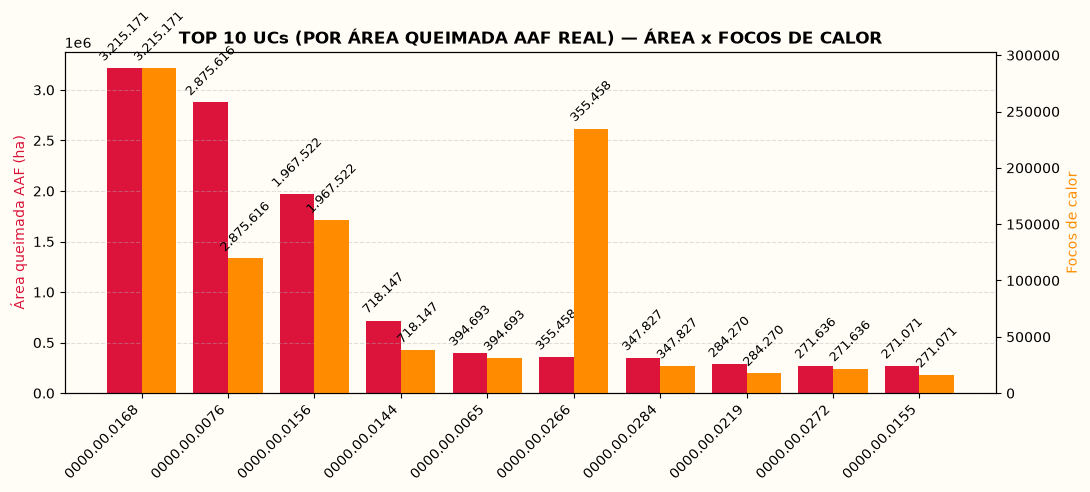

In [45]:
# Top 10 UCs — área queimada real x total de focos de calor

aaf_area_by_uc = gdf_aaf_metric.groupby('cnuc')['area_ha_cell'].sum().rename('aaf_area_ha')
hotspot_count_by_uc = (
    gdf_inpe_with_cell.merge(cell_uc_membership, on='cell_id', how='left')
    .groupby('cnuc').size().rename('hotspot_count')
)

top10_area = (
    pd.concat([aaf_area_by_uc, hotspot_count_by_uc], axis=1)
    .fillna(0)
    .merge(gdf_ucs_metric, on='cnuc', how='left')
    .nlargest(10, 'aaf_area_ha')
)

fig, ax1 = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#FFFDF5')
ax1.set_facecolor('#FFFDF5')

x = np.arange(len(top10_area))
width = 0.4

bars1 = ax1.bar(x - width/2, top10_area['aaf_area_ha'], width, color='crimson', label='Área queimada AAF (ha)')
ax1.bar_label(bars1, labels= format_thousands(top10_area['aaf_area_ha']), fontsize=9, rotation=45, padding=3)
ax1.set_ylabel('Área queimada AAF (ha)', color='crimson')
ax1.set_xticks(x)
ax1.set_xticklabels(top10_area['cnuc'], rotation=45, ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, top10_area['hotspot_count'], width, color='darkorange', label='Focos de calor')
ax2.bar_label(bars2, labels=format_thousands(top10_area['aaf_area_ha']), fontsize=9, rotation=45, padding=3)
ax2.set_ylabel('Focos de calor', color='darkorange')

plt.title('TOP 10 UCs (POR ÁREA QUEIMADA AAF REAL) — ÁREA x FOCOS DE CALOR', fontweight='bold')
fig.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "top10_ucs_area_x_focos.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

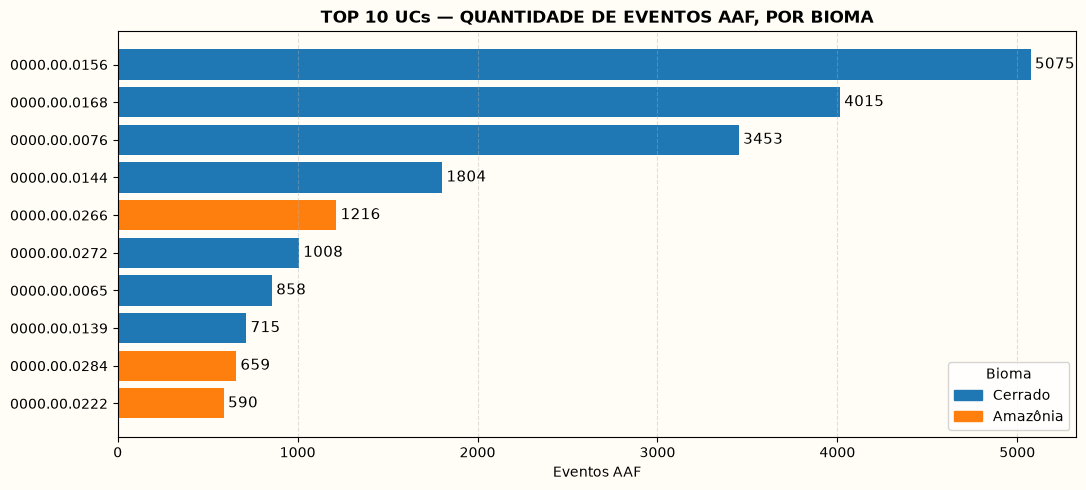

In [46]:
# Top 10 UCs — quantidade de eventos por bioma predominante

uc_info = gdf_ucs_metric[['cnuc', 'nomeuc', 'bioma_pred']].drop_duplicates()

top10_events_bioma = (
    aaf_events_unique.groupby('cnuc').size().rename('n_events')
    .reset_index()
    .merge(uc_info, on='cnuc', how='left')
    .nlargest(10, 'n_events')
)

biomas_unicos = top10_events_bioma['bioma_pred'].unique()
cores_bioma = dict(zip(biomas_unicos, plt.cm.tab10.colors[:len(biomas_unicos)]))
cores_barras = top10_events_bioma['bioma_pred'].map(cores_bioma)

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#FFFDF5')
ax.set_facecolor('#FFFDF5')

bars = ax.barh(top10_events_bioma['cnuc'], top10_events_bioma['n_events'], color=cores_barras)
ax.bar_label(bars, fmt='%.0f', fontsize=11, padding=3)
ax.invert_yaxis()
ax.set_xlabel('Eventos AAF')
ax.set_title('TOP 10 UCs — QUANTIDADE DE EVENTOS AAF, POR BIOMA', fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.4)

legend_handles = [plt.Rectangle((0, 0), 1, 1, color=cor) for cor in cores_bioma.values()]
ax.legend(legend_handles, cores_bioma.keys(), title='Bioma', loc='lower right')

plt.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "top_10_uc_qtd_aaf_biomas.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

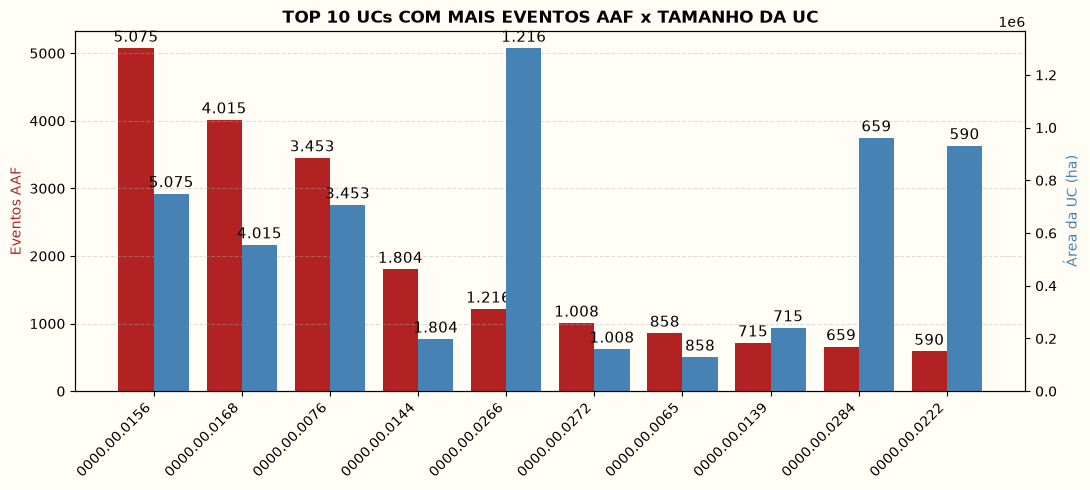

In [47]:
# Top 10 UCs por eventos, comparadas ao tamanho (área total) da UC

top10_events_size = (
    aaf_events_unique.groupby('cnuc').size().rename('n_events')
    .reset_index()
    .merge(gdf_ucs_metric, on='cnuc', how='left')
    .nlargest(10, 'n_events')
)

fig, ax1 = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#FFFDF5')
ax1.set_facecolor('#FFFDF5')

x = np.arange(len(top10_events_size))
width = 0.4

bars1 = ax1.bar(x - width/2, top10_events_size['n_events'], width, color='firebrick', label='Eventos AAF')
ax1.bar_label(bars1, labels=format_thousands(top10_events_size['n_events']), fontsize=11, padding=2)
ax1.set_ylabel('Eventos AAF', color='firebrick')
ax1.set_xticks(x)
ax1.set_xticklabels(top10_events_size['cnuc'], rotation=45, ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, top10_events_size['areahaalb'], width, color='steelblue', label='Área da UC (ha)')
ax2.bar_label(bars2, labels=format_thousands(top10_events_size['n_events']), fontsize=11, padding=2)
ax2.set_ylabel('Área da UC (ha)', color='steelblue')

plt.title('TOP 10 UCs COM MAIS EVENTOS AAF x TAMANHO DA UC', fontweight='bold')
fig.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "top_10_uc_qtd_aaf_vs_ha_uc.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

### Temporal — anual, mensal, acumulado

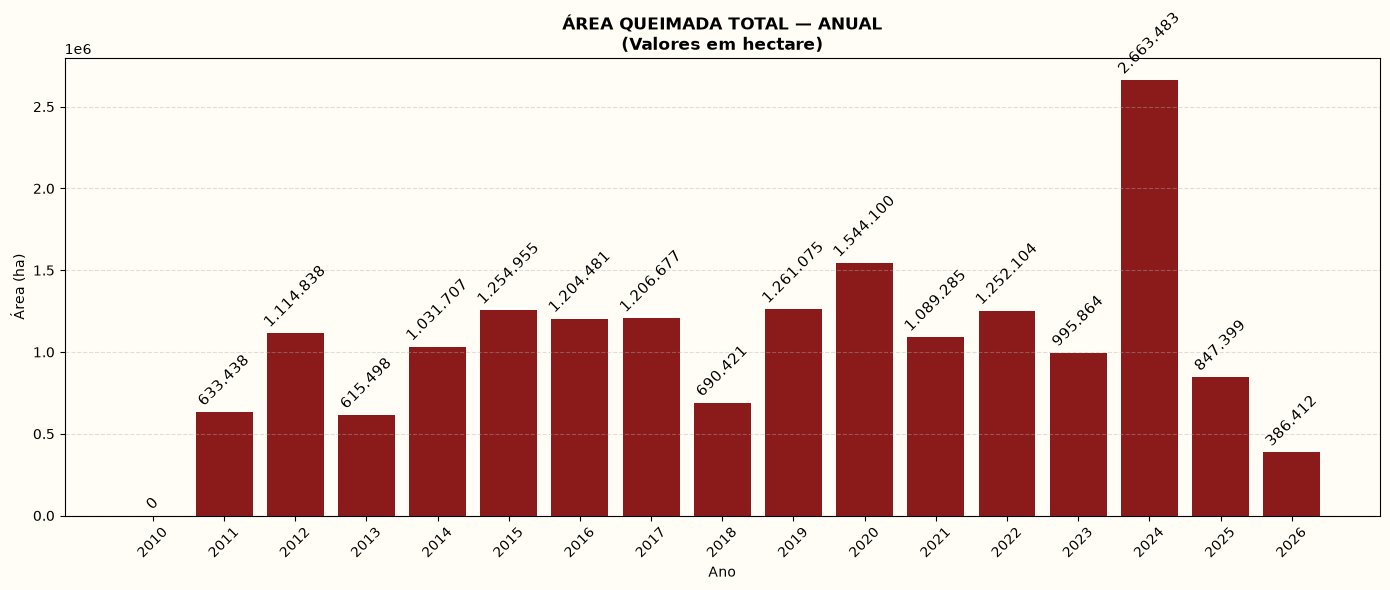

In [48]:
# Área queimada total, por ano

annual_area = gdf_aaf_metric.groupby('event_year')['area_ha_cell'].sum().reindex(range(2010, 2027), fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#FFFDF5')
ax.set_facecolor('#FFFDF5')

bars = ax.bar(annual_area.index.astype(str), annual_area.values, color='#8b1a1a')
ax.bar_label(bars, labels=format_thousands(annual_area.values), fontsize=11, rotation=45, padding=2)

ax.set_xlabel('Ano')
ax.set_ylabel('Área (ha)')
ax.set_title('ÁREA QUEIMADA TOTAL — ANUAL\n(Valores em hectare)', fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "aaf_total_anual.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

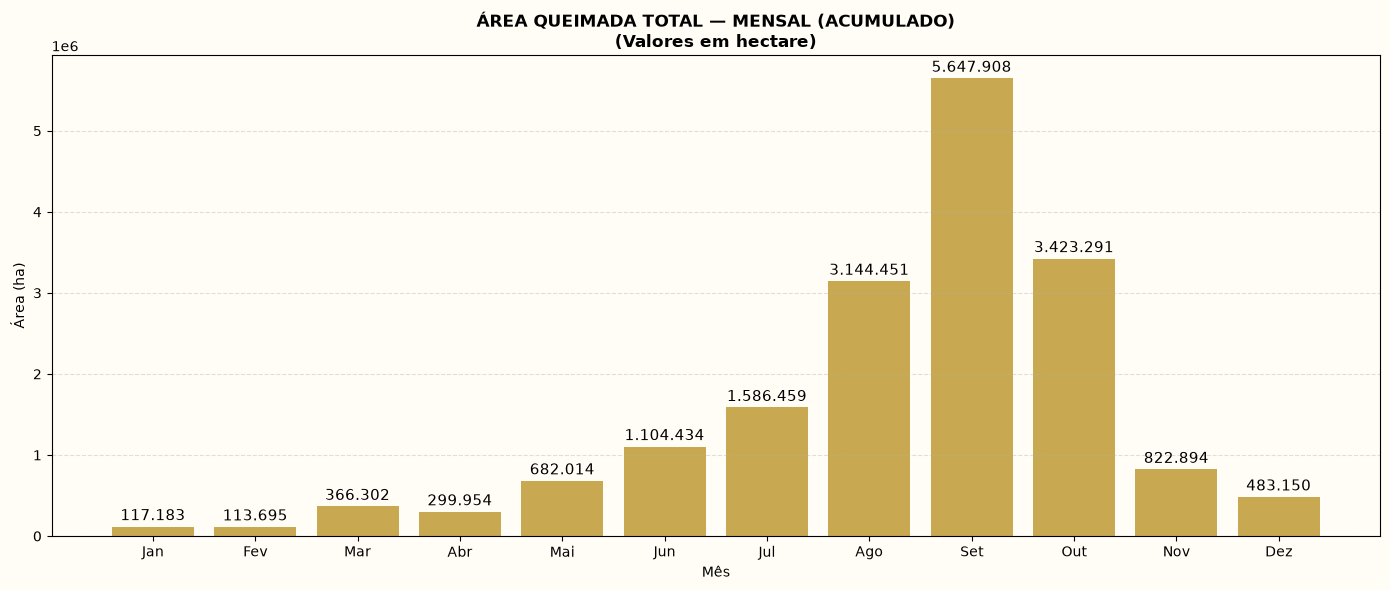

In [49]:
# Área queimada total, por mês (acumulado, todos os anos)

monthly_area = gdf_aaf_metric.groupby('event_month')['area_ha_cell'].sum().reindex(range(1, 13), fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#FFFDF5')
ax.set_facecolor('#FFFDF5')

bars = ax.bar(months_label, monthly_area.values, color='#c8a951')
ax.bar_label(bars, labels=format_thousands(monthly_area.values), fontsize=11, padding=2)

ax.set_xlabel('Mês')
ax.set_ylabel('Área (ha)')
ax.set_title('ÁREA QUEIMADA TOTAL — MENSAL (ACUMULADO)\n(Valores em hectare)', fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "aaf_total_mensal.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

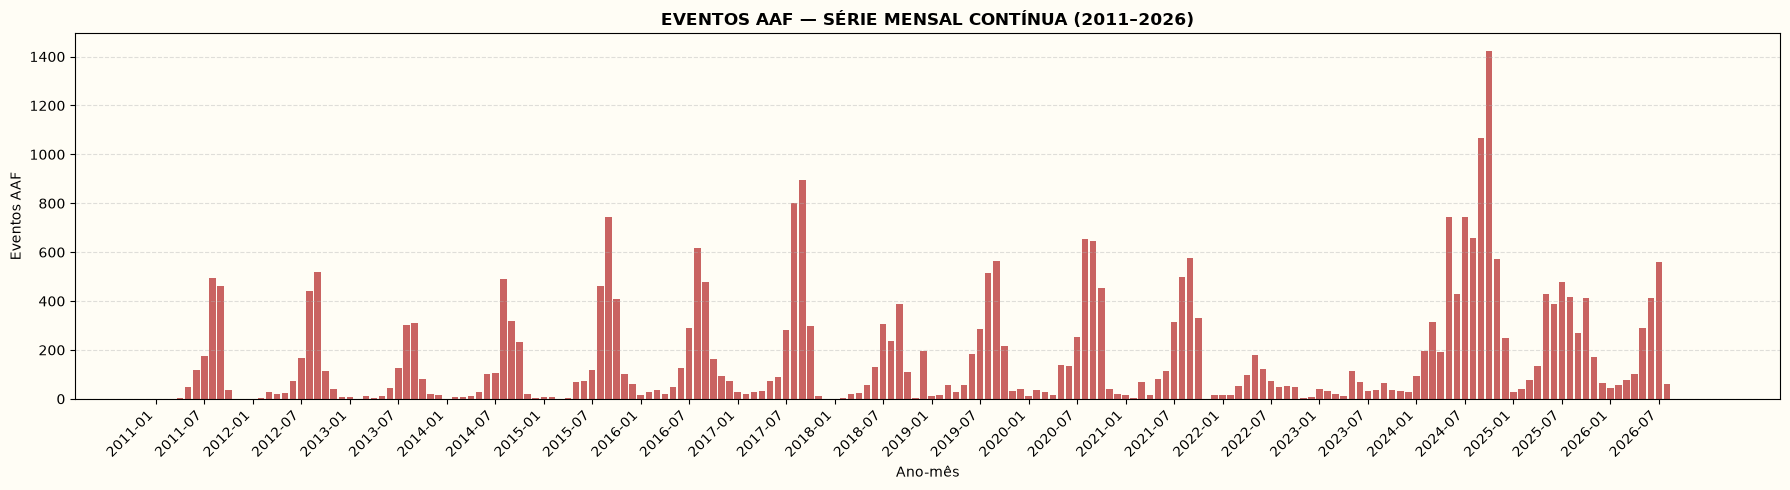

In [50]:
# Série mensal contínua, sem acumular anos (cada ponto = um mês de um ano específico)

min_year = aaf_events_unique['event_year'].min()
max_year = aaf_events_unique['event_year'].max()

aaf_events_unique['year_month'] = pd.to_datetime(
    aaf_events_unique['event_year'].astype(int).astype(str) + '-' +
    aaf_events_unique['event_month'].astype(int).astype(str)
).dt.to_period('M')

events_by_yearmonth = aaf_events_unique.groupby('year_month').size()

full_range = pd.period_range(start=f'{min_year}-01', end=f'{max_year}-12', freq='M')
events_by_yearmonth = events_by_yearmonth.reindex(full_range, fill_value=0)

x_labels = full_range.astype(str)

fig, ax = plt.subplots(figsize=(18, 5))
fig.patch.set_facecolor('#FFFDF5')
ax.set_facecolor('#FFFDF5')

ax.bar(x_labels, events_by_yearmonth.values, color='firebrick', alpha=0.7)
ax.set_xticks(range(0, len(x_labels), 6))
ax.set_xticklabels(x_labels[::6], rotation=45, ha='right')
ax.set_xlabel('Ano-mês')
ax.set_ylabel('Eventos AAF')
ax.set_title(f'EVENTOS AAF — SÉRIE MENSAL CONTÍNUA ({min_year}–{max_year})', fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "aff_2011_2026.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

### Comparativo AAF x INPE (bioma, temporal)


In [51]:
MIN_YEARS_FOR_FRI_EDA = 3
MIN_HOTSPOTS_FOR_FRP_EDA = 5
MIN_EVENTS_FOR_SEASONALITY_EDA = 3
MIN_YEARS_FOR_AREA_EDA = 3

TOTAL_CELLS_EDA = len(gdf_grid)

years_by_cell_eda = gdf_aaf_metric.groupby("cell_id")["event_year"].nunique()
events_by_cell_eda = gdf_aaf_metric.groupby("cell_id").size()

fri_ok_eda = set(years_by_cell_eda[years_by_cell_eda >= MIN_YEARS_FOR_FRI_EDA].index)
area_ok_eda = set(years_by_cell_eda[years_by_cell_eda >= MIN_YEARS_FOR_AREA_EDA].index)
seasonality_ok_eda = set(events_by_cell_eda[events_by_cell_eda >= MIN_EVENTS_FOR_SEASONALITY_EDA].index)

aaf_confiavel_eda = fri_ok_eda & area_ok_eda & seasonality_ok_eda

print(f"Total de células na grade: {TOTAL_CELLS_EDA}")
print(f"Células confiáveis nas 3 variáveis do AAF: {len(aaf_confiavel_eda)} ({len(aaf_confiavel_eda) / TOTAL_CELLS_EDA * 100:.1f}%)")

Total de células na grade: 22687
Células confiáveis nas 3 variáveis do AAF: 1297 (5.7%)


In [52]:
hotspots_by_cell_eda = gdf_inpe_with_cell.groupby("cell_id").size()
frp_confiavel_eda = set(hotspots_by_cell_eda[hotspots_by_cell_eda >= MIN_HOTSPOTS_FOR_FRP_EDA].index)

print(f"Células confiáveis em FRP (INPE): {len(frp_confiavel_eda)} ({len(frp_confiavel_eda) / TOTAL_CELLS_EDA * 100:.1f}%)")

Células confiáveis em FRP (INPE): 6055 (26.7%)


In [53]:
grupo_a_potencial_eda = aaf_confiavel_eda & frp_confiavel_eda
so_falta_frp = aaf_confiavel_eda - frp_confiavel_eda
so_falta_aaf = frp_confiavel_eda - aaf_confiavel_eda

print(f"\nCélulas confiáveis nas duas fontes ao mesmo tempo: {len(grupo_a_potencial_eda)} ({len(grupo_a_potencial_eda) / TOTAL_CELLS_EDA * 100:.1f}%)")
print(f"Confiáveis no AAF, mas perdidas por falta de FRP: {len(so_falta_frp)} ({len(so_falta_frp) / TOTAL_CELLS_EDA * 100:.1f}%)")
print(f"Confiáveis em FRP, mas perdidas por falta de AAF: {len(so_falta_aaf)} ({len(so_falta_aaf) / TOTAL_CELLS_EDA * 100:.1f}%)")



Células confiáveis nas duas fontes ao mesmo tempo: 1289 (5.7%)
Confiáveis no AAF, mas perdidas por falta de FRP: 8 (0.0%)
Confiáveis em FRP, mas perdidas por falta de AAF: 4766 (21.0%)


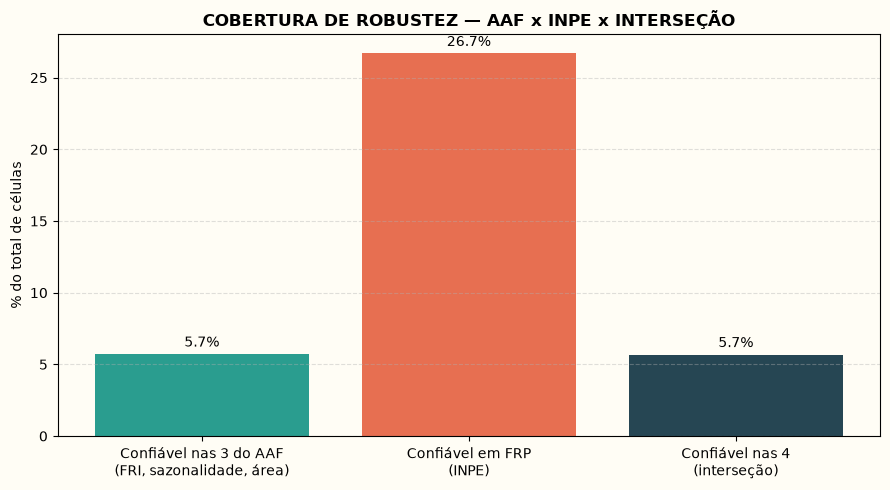

In [54]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("#FFFDF5")
ax.set_facecolor("#FFFDF5")

bars_data = {
    "Confiável nas 3 do AAF\n(FRI, sazonalidade, área)": len(aaf_confiavel_eda)
    / TOTAL_CELLS_EDA
    * 100,
    "Confiável em FRP\n(INPE)": len(frp_confiavel_eda) / TOTAL_CELLS_EDA * 100,
    "Confiável nas 4\n(interseção)": len(grupo_a_potencial_eda) / TOTAL_CELLS_EDA * 100,
}

bars = ax.bar(
    bars_data.keys(), bars_data.values(), color=["#2a9d8f", "#e76f51", "#264653"]
)
ax.bar_label(bars, fmt="%.1f%%", fontsize=10, padding=3)

ax.set_ylabel("% do total de células")
ax.set_title("COBERTURA DE ROBUSTEZ — AAF x INPE x INTERSEÇÃO", fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(
    os.path.join(PRINTS_DIR, "diagnostico_gargalo_fonte.png"),
    dpi=200,
    bbox_inches="tight",
    facecolor="#FFFDF5",
)
plt.show()

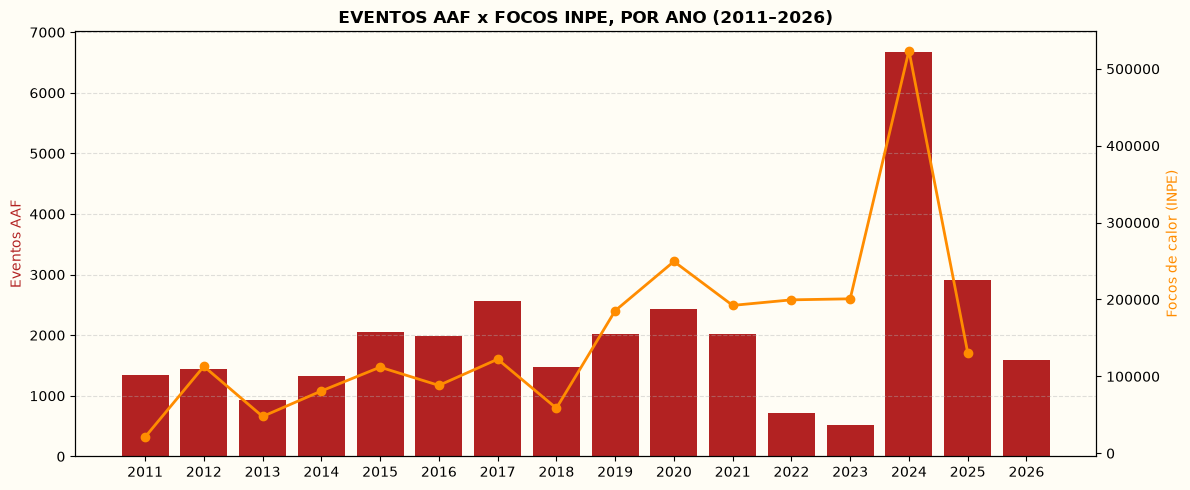

In [55]:
# Eventos AAF x focos INPE, por ano (mesmo intervalo do AAF)

min_year = aaf_events_unique['event_year'].min()
max_year = aaf_events_unique['event_year'].max()

aaf_by_year = aaf_events_unique.groupby('event_year').size()
inpe_by_year = gdf_inpe_with_cell[
    (gdf_inpe_with_cell['file_year'] >= min_year) & (gdf_inpe_with_cell['file_year'] <= max_year)
].groupby('file_year').size()

fig, ax1 = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#FFFDF5")
ax1.set_facecolor("#FFFDF5")

ax1.bar(aaf_by_year.index.astype(str), aaf_by_year.values, color='firebrick', label='Eventos AAF')
ax1.set_ylabel('Eventos AAF', color='firebrick')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
ax2.plot(aaf_by_year.index.astype(str), inpe_by_year.reindex(aaf_by_year.index).values,
          color='darkorange', marker='o', linewidth=2, label='Focos INPE')
ax2.set_ylabel('Focos de calor (INPE)', color='darkorange')

plt.title(f'EVENTOS AAF x FOCOS INPE, POR ANO ({min_year}–{max_year})', fontweight='bold')
plt.xticks(rotation=45)
fig.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "aff_vs_inpe_ano.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()


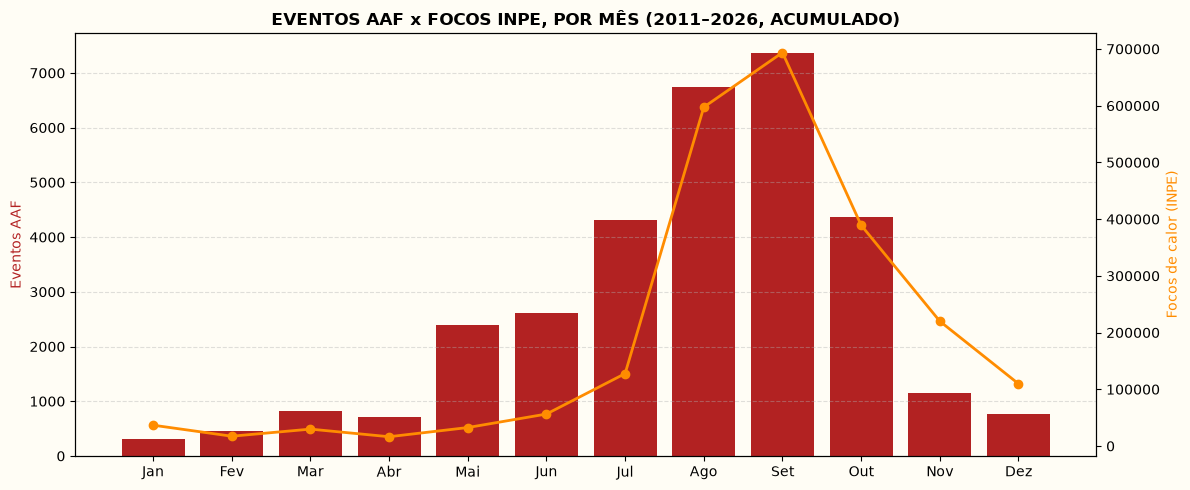

In [56]:
# Eventos AAF x focos INPE, por mês (acumulado, mesmo intervalo do AAF)

aaf_by_month = aaf_events_unique.groupby('event_month').size().reindex(range(1, 13), fill_value=0)

gdf_inpe_with_cell['month'] = pd.to_datetime(gdf_inpe_with_cell['data_pas'], errors='coerce').dt.month
inpe_by_month = gdf_inpe_with_cell[
    (gdf_inpe_with_cell['file_year'] >= min_year) & (gdf_inpe_with_cell['file_year'] <= max_year)
].groupby('month').size().reindex(range(1, 13), fill_value=0)

fig, ax1 = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#FFFDF5")
ax1.set_facecolor("#FFFDF5")

ax1.bar(months_label, aaf_by_month.values, color='firebrick', label='Eventos AAF')
ax1.set_ylabel('Eventos AAF', color='firebrick')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
ax2.plot(months_label, inpe_by_month.values, color='darkorange', marker='o', linewidth=2, label='Focos INPE')
ax2.set_ylabel('Focos de calor (INPE)', color='darkorange')

plt.title(f'EVENTOS AAF x FOCOS INPE, POR MÊS ({min_year}–{max_year}, ACUMULADO)', fontweight='bold')
fig.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "aff_vs_inpe_mes.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

### Tipo de evento harmonizado (contagem, área, FRP, espacial)


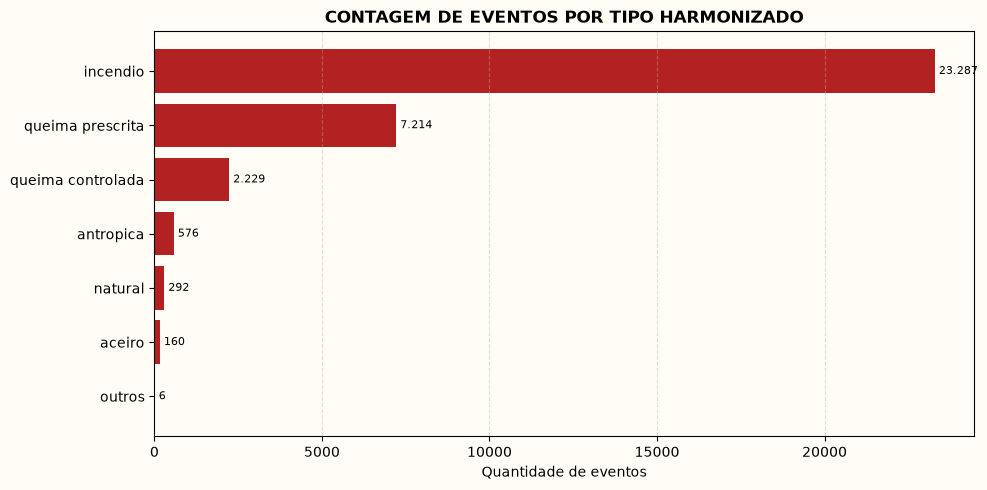

In [57]:
# Contagem de eventos por tipo

event_type_counts = gdf_aaf_metric.dropna(subset=['event_type'])['event_type'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#FFFDF5")
ax.set_facecolor("#FFFDF5")

bars = ax.barh(event_type_counts.index, event_type_counts.values, color='firebrick')
ax.bar_label(bars, labels=format_thousands(event_type_counts.values), fontsize=8, padding=3)
ax.invert_yaxis()
ax.set_xlabel('Quantidade de eventos')
ax.set_title('CONTAGEM DE EVENTOS POR TIPO HARMONIZADO', fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "aaf_por_tipo.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

In [58]:
# FRP médio associado a cada tipo harmonizado (vínculo aproximado: mesma célula + ano + mês)

frp_by_cell_period = (
    gdf_inpe_with_cell.groupby(['cell_id', 'file_year', 'month'])['frp']
    .mean()
    .rename('frp_mean_period')
    .reset_index()
)

aaf_with_frp = gdf_aaf_metric.dropna(subset=['event_type']).merge(
    frp_by_cell_period,
    left_on=['cell_id', 'file_year', 'event_month'],
    right_on=['cell_id', 'file_year', 'month'],
    how='inner'
)

aaf_with_frp['event_type'].value_counts()

event_type
incendio             20209
queima prescrita      4607
queima controlada     1743
antropica              478
natural                263
aceiro                  89
outros                   5
Name: count, dtype: int64

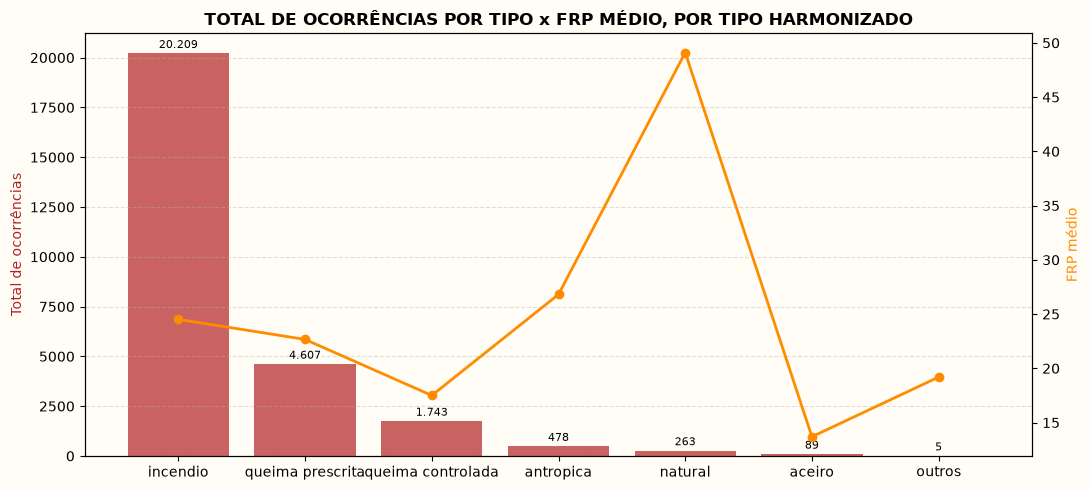

In [59]:
# Total de ocorrências por tipo x FRP médio, por tipo harmonizado

occurrence_by_type = aaf_with_frp['event_type'].value_counts()
frp_mean_by_type = aaf_with_frp.groupby('event_type')['frp_mean_period'].mean()

combo_df = pd.concat([occurrence_by_type.rename('n_events'), frp_mean_by_type.rename('frp_mean')], axis=1)
combo_df = combo_df.sort_values('n_events', ascending=False)

fig, ax1 = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor("#FFFDF5")
ax1.set_facecolor("#FFFDF5")

bars = ax1.bar(combo_df.index, combo_df['n_events'], color='firebrick', alpha=0.7, label='Ocorrências')
ax1.bar_label(bars, labels=format_thousands(combo_df['n_events']), fontsize=8, padding=2)
ax1.set_ylabel('Total de ocorrências', color='firebrick')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
ax2.plot(combo_df.index, combo_df['frp_mean'], color='darkorange', marker='o', linewidth=2, label='FRP médio')
ax2.set_ylabel('FRP médio', color='darkorange')

plt.title('TOTAL DE OCORRÊNCIAS POR TIPO x FRP MÉDIO, POR TIPO HARMONIZADO', fontweight='bold')
plt.xticks(rotation=30, ha='right')
fig.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "tipo_vs_frp_medio.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()


### Regime do Fogo

In [60]:
#  FRP médio e máximo, por célula — todas as células com foco de calor dentro das UCs

frp_by_cell_full = gdf_inpe_with_cell.groupby('cell_id')['frp'].agg(
    frp_mean='mean', frp_max='max', n_hotspots='count'
).dropna(subset=['frp_mean'])

total_cells = len(gdf_grid)
cells_with_hotspot = gdf_inpe_with_cell['cell_id'].nunique()
cells_with_frp = len(frp_by_cell_full)
cells_no_hotspot = total_cells - cells_with_hotspot

print(f"Total de células na grade: {total_cells}")
print(f"Células com pelo menos 1 foco de calor: {cells_with_hotspot}")
print(f"Células com FRP calculável (foco válido, não nulo): {cells_with_frp}")
print(f"Células sem nenhum foco de calor registrado: {cells_no_hotspot}")

Total de células na grade: 22687
Células com pelo menos 1 foco de calor: 9181
Células com FRP calculável (foco válido, não nulo): 6836
Células sem nenhum foco de calor registrado: 13506


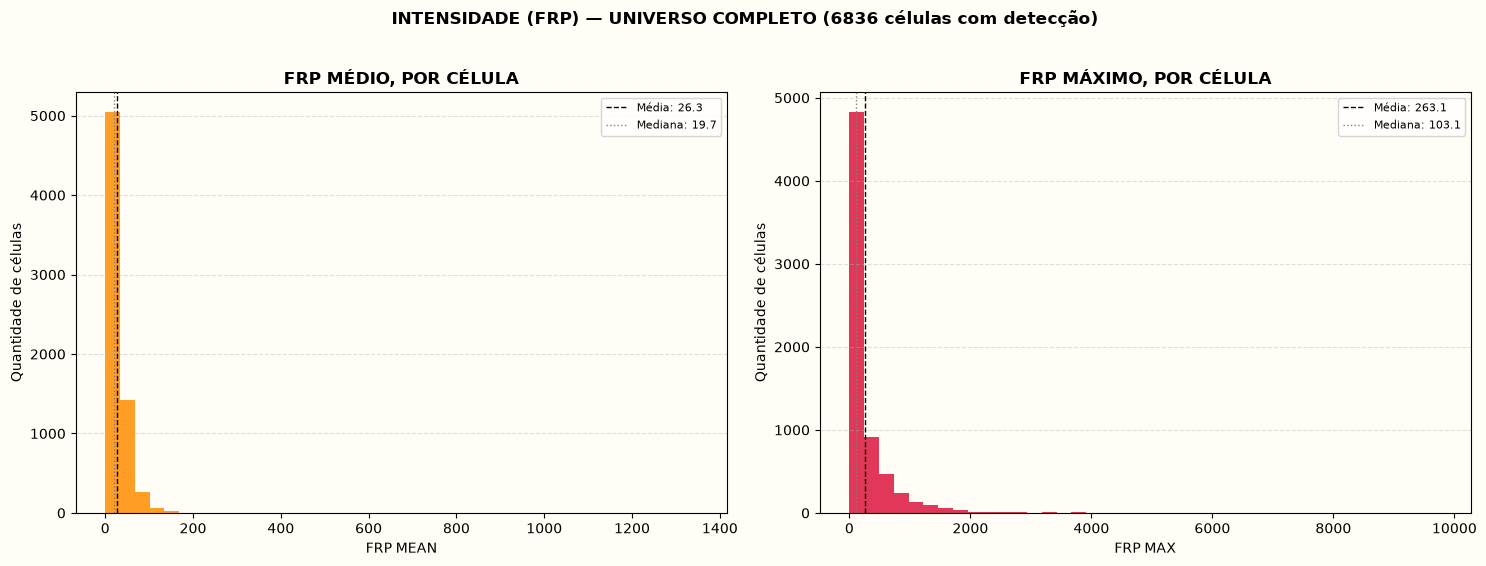

In [61]:
# Histogramas — FRP médio e máximo, com estatísticas-chave marcadas

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.patch.set_facecolor("#FFFDF5")

for ax, col, color, title in [
    (axes[0], 'frp_mean', 'darkorange', 'FRP MÉDIO, POR CÉLULA'),
    (axes[1], 'frp_max', 'crimson', 'FRP MÁXIMO, POR CÉLULA'),
]:
    ax.set_facecolor("#FFFDF5")
    data = frp_by_cell_full[col]
    ax.hist(data, bins=40, color=color, alpha=0.85)

    mean_val = data.mean()
    median_val = data.median()
    ax.axvline(mean_val, color='black', linestyle='--', linewidth=1, label=f'Média: {mean_val:,.1f}'.replace(',', '.'))
    ax.axvline(median_val, color='gray', linestyle=':', linewidth=1, label=f'Mediana: {median_val:,.1f}'.replace(',', '.'))

    ax.set_xlabel(col.replace('_', ' ').upper())
    ax.set_ylabel('Quantidade de células')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle(f'INTENSIDADE (FRP) — UNIVERSO COMPLETO ({cells_with_frp} células com detecção)', fontweight='bold', y=1.02)
plt.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "frp.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

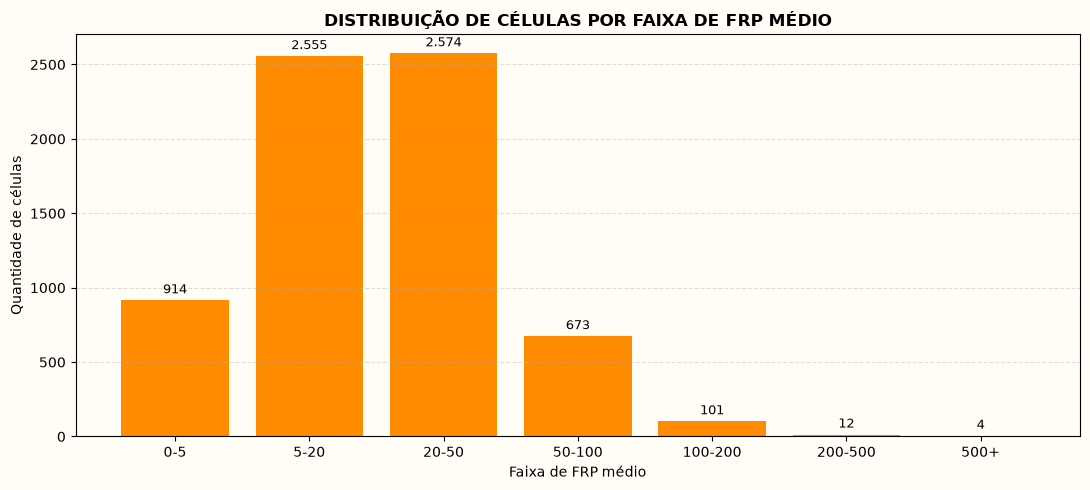

In [62]:
# Comparativo — % de células por faixa de FRP médio (visão de distribuição em degraus)

frp_bins = [0, 5, 20, 50, 100, 200, 500, float('inf')]
frp_labels = ['0-5', '5-20', '20-50', '50-100', '100-200', '200-500', '500+']

frp_by_cell_full['frp_range'] = pd.cut(frp_by_cell_full['frp_mean'], bins=frp_bins, labels=frp_labels)
frp_range_counts = frp_by_cell_full['frp_range'].value_counts().reindex(frp_labels)

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor("#FFFDF5")
ax.set_facecolor("#FFFDF5")

bars = ax.bar(frp_range_counts.index.astype(str), frp_range_counts.values, color='darkorange')
ax.bar_label(bars, labels=format_thousands(frp_range_counts.values), fontsize=9, padding=3)
ax.set_xlabel('Faixa de FRP médio')
ax.set_ylabel('Quantidade de células')
ax.set_title('DISTRIBUIÇÃO DE CÉLULAS POR FAIXA DE FRP MÉDIO', fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "distribuicao_cel_frp_medio.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

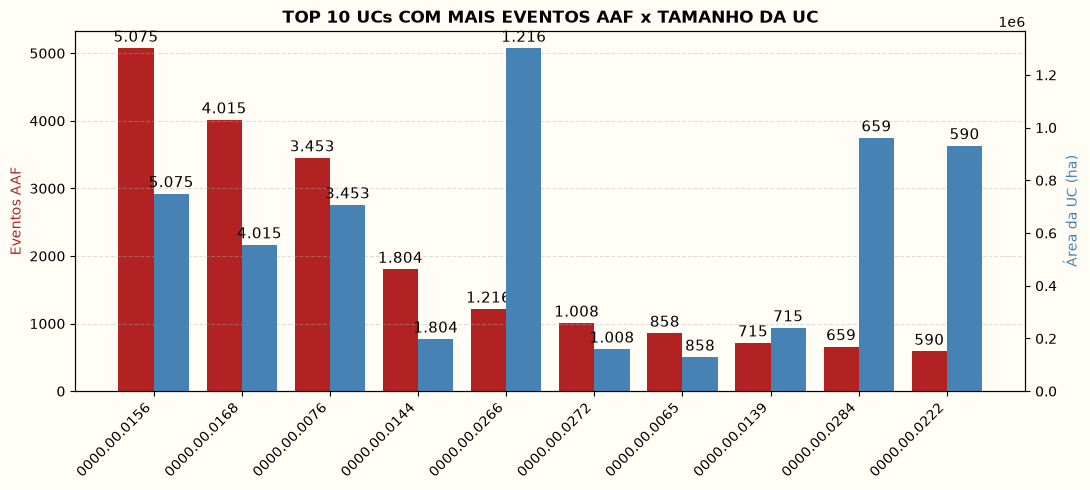

In [63]:
# Top 10 UCs por eventos, comparadas ao tamanho (área total) da UC

top10_events_size = (
    aaf_events_unique.groupby('cnuc').size().rename('n_events')
    .reset_index()
    .merge(gdf_ucs_metric, on='cnuc', how='left')
    .nlargest(10, 'n_events')
)

fig, ax1 = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#FFFDF5')
ax1.set_facecolor('#FFFDF5')

x = np.arange(len(top10_events_size))
width = 0.4

bars1 = ax1.bar(x - width/2, top10_events_size['n_events'], width, color='firebrick', label='Eventos AAF')
ax1.bar_label(bars1, labels=format_thousands(top10_events_size['n_events']), fontsize=11, padding=2)
ax1.set_ylabel('Eventos AAF', color='firebrick')
ax1.set_xticks(x)
ax1.set_xticklabels(top10_events_size['cnuc'], rotation=45, ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, top10_events_size['areahaalb'], width, color='steelblue', label='Área da UC (ha)')
ax2.bar_label(bars2, labels=format_thousands(top10_events_size['n_events']), fontsize=11, padding=2)
ax2.set_ylabel('Área da UC (ha)', color='steelblue')

plt.title('TOP 10 UCs COM MAIS EVENTOS AAF x TAMANHO DA UC', fontweight='bold')
fig.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "top_10_uc_qtd_aaf_vs_ha_uc.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

In [64]:
# Anos distintos com evento e FRI médio, por célula

years_by_cell = gdf_aaf_metric.groupby('cell_id')['event_year'].apply(lambda x: sorted(x.unique()))

def mean_return_interval(years_list):
    if len(years_list) < 2:
        return np.nan
    return np.diff(years_list).mean()

fri_by_cell = pd.DataFrame({
    'cell_id': years_by_cell.index,
    'n_fire_years': years_by_cell.apply(len),
    'fri_mean': years_by_cell.apply(mean_return_interval),
}).reset_index(drop=True)

total_cells = len(gdf_grid)
cells_with_aaf = len(fri_by_cell)
cells_never_burned = total_cells - cells_with_aaf
cells_single_year = (fri_by_cell['n_fire_years'] == 1).sum()
cells_fri_calculable = fri_by_cell['fri_mean'].notna().sum()

print(f"Total de células na grade: {total_cells}")
print(f"Células sem nenhum evento AAF: {cells_never_burned}")
print(f"Células com evento AAF em apenas 1 ano (FRI não calculável): {cells_single_year}")
print(f"Células com FRI calculável (2+ anos distintos): {cells_fri_calculable}")
print()
print("FRI médio — estatísticas (apenas células calculáveis):")
print(fri_by_cell['fri_mean'].describe())

Total de células na grade: 22687
Células sem nenhum evento AAF: 19985
Células com evento AAF em apenas 1 ano (FRI não calculável): 968
Células com FRI calculável (2+ anos distintos): 1734

FRI médio — estatísticas (apenas células calculáveis):
count    1734.000000
mean        2.768944
std         2.193546
min         1.000000
25%         1.166667
50%         2.000000
75%         3.500000
max        14.000000
Name: fri_mean, dtype: float64


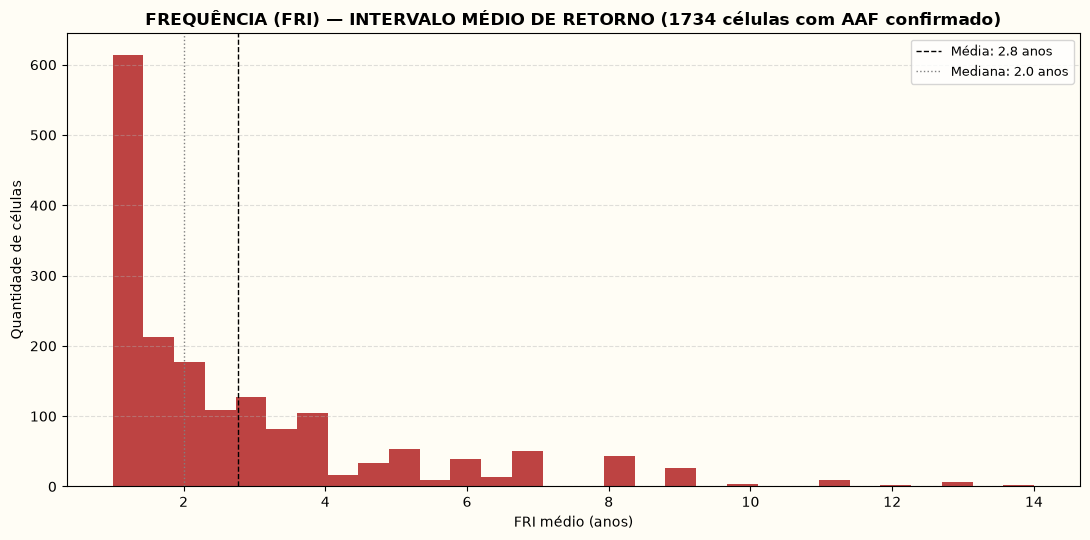

In [65]:
# Histograma do FRI médio, com estatísticas-chave marcadas

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor("#FFFDF5")
ax.set_facecolor("#FFFDF5")

fri_valid = fri_by_cell['fri_mean'].dropna()
ax.hist(fri_valid, bins=30, color='firebrick', alpha=0.85)

mean_val = fri_valid.mean()
median_val = fri_valid.median()
ax.axvline(mean_val, color='black', linestyle='--', linewidth=1, label=f'Média: {mean_val:.1f} anos')
ax.axvline(median_val, color='gray', linestyle=':', linewidth=1, label=f'Mediana: {median_val:.1f} anos')

ax.set_xlabel('FRI médio (anos)')
ax.set_ylabel('Quantidade de células')
ax.set_title(f'FREQUÊNCIA (FRI) — INTERVALO MÉDIO DE RETORNO ({cells_fri_calculable} células com AAF confirmado)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "fri_intervalo_medio.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()


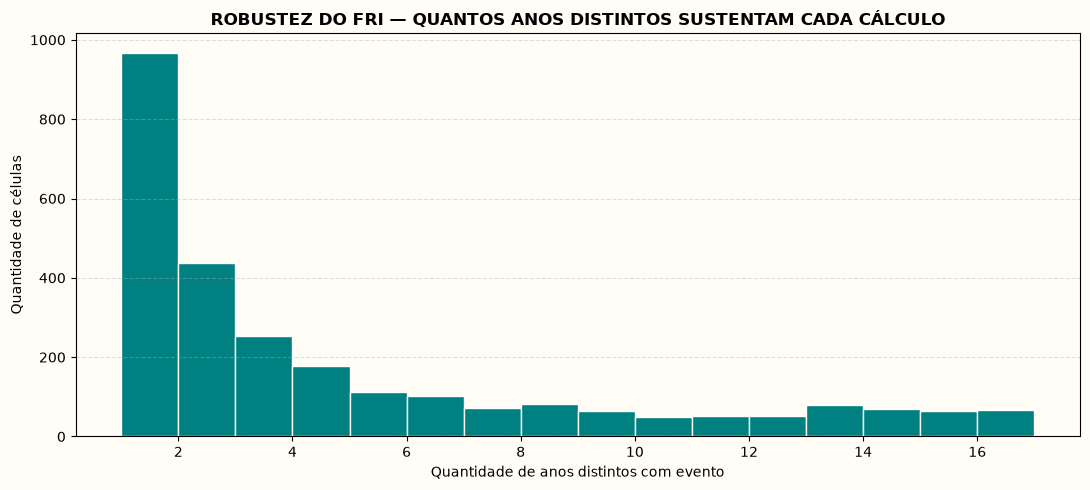

In [66]:
# Distribuição de quantas vezes (anos distintos) cada célula queimou — robustez do FRI

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor("#FFFDF5")
ax.set_facecolor("#FFFDF5")

ax.hist(fri_by_cell['n_fire_years'], bins=range(1, 18), color='teal', edgecolor='white')
ax.set_xlabel('Quantidade de anos distintos com evento')
ax.set_ylabel('Quantidade de células')
ax.set_title('ROBUSTEZ DO FRI — QUANTOS ANOS DISTINTOS SUSTENTAM CADA CÁLCULO', fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "fri_ano.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()


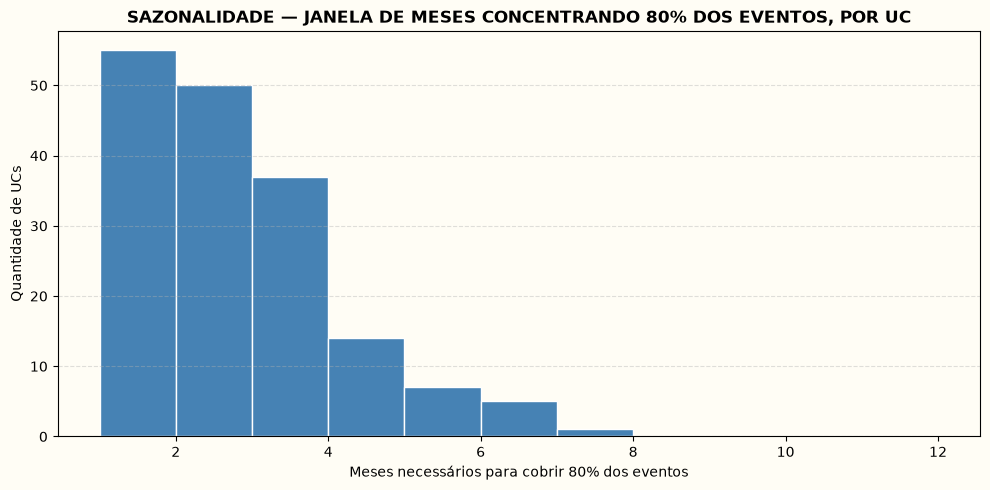

In [67]:
#  Sazonalidade — janela de meses concentrando 80% dos eventos, por UC

seasonal_by_uc = (
    gdf_aaf_metric.dropna(subset=['cnuc'])
    .groupby('cnuc')['event_month']
    .apply(lambda x: seasonal_window(x, 0.8))
    .rename('n_months_80pct')
)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#FFFDF5')
ax.set_facecolor('#FFFDF5')

ax.hist(seasonal_by_uc, bins=range(1, 13), color='steelblue', edgecolor='white')
ax.set_xlabel('Meses necessários para cobrir 80% dos eventos')
ax.set_ylabel('Quantidade de UCs')
ax.set_title('SAZONALIDADE — JANELA DE MESES CONCENTRANDO 80% DOS EVENTOS, POR UC', fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "sazonalidade.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

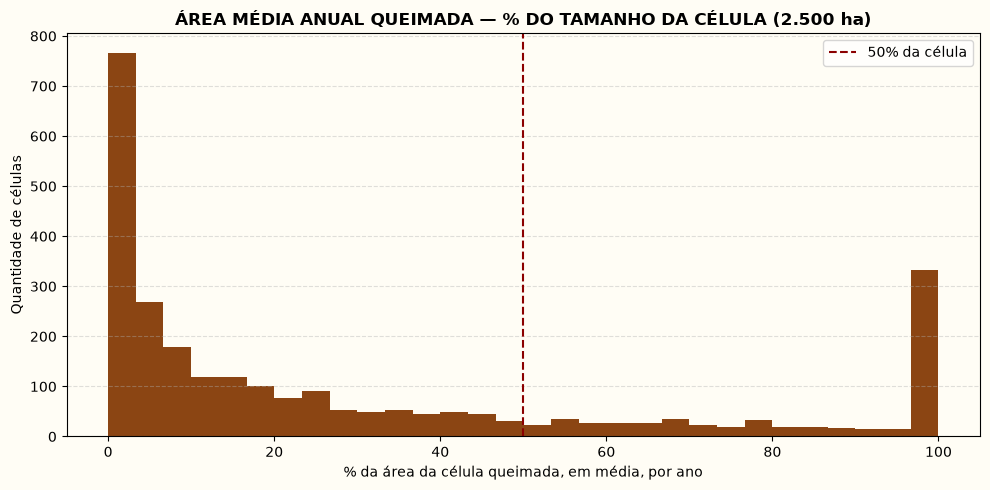

In [68]:
# Área média anual queimada — por célula, comparada ao tamanho da célula (2.500 ha)

CELL_AREA_HA = 2500  # 5km x 5km

annual_area_by_cell = gdf_aaf_metric.groupby(['cell_id', 'event_year'])['area_ha_cell'].sum().reset_index()
mean_annual_area_by_cell = annual_area_by_cell.groupby('cell_id')['area_ha_cell'].mean()
pct_of_cell_burned = (mean_annual_area_by_cell / CELL_AREA_HA * 100).clip(upper=100)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#FFFDF5')
ax.set_facecolor('#FFFDF5')

ax.hist(pct_of_cell_burned, bins=30, color='saddlebrown')
ax.axvline(50, color='darkred', linestyle='--', label='50% da célula')
ax.set_xlabel('% da área da célula queimada, em média, por ano')
ax.set_ylabel('Quantidade de células')
ax.set_title('ÁREA MÉDIA ANUAL QUEIMADA — % DO TAMANHO DA CÉLULA (2.500 ha)', fontweight='bold')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "area_media_anual_queimada.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

In [69]:
# Mapa interativo (geemap) — top 10 UCs, reaproveitando top10_area e seasonal_by_uc já calculados

top10_ucs_geom = gdf_ucs_metric[gdf_ucs_metric['cnuc'].isin(top10_area['cnuc'])].to_crs(4326)

n_events_by_uc = aaf_events_unique.groupby('cnuc').size().rename('n_events')
max_event_by_uc = aaf_events_unique.groupby('cnuc')['area_ha'].max().rename('max_event_ha')
n_years_by_uc = aaf_events_unique.groupby('cnuc')['event_year'].nunique().rename('n_years_with_fire')

def mean_return_interval(years_list):
    if len(years_list) < 2:
        return np.nan
    return np.diff(sorted(years_list)).mean()

fri_by_uc = (
    aaf_events_unique.groupby('cnuc')['event_year']
    .apply(lambda x: mean_return_interval(x.unique()))
    .rename('fri_mean')
)

annual_area_by_uc_year = gdf_aaf_metric.groupby(['cnuc', 'event_year'])['area_ha_cell'].sum().reset_index()
annual_area_mean_by_uc = annual_area_by_uc_year.groupby('cnuc')['area_ha_cell'].mean().rename('annual_area_mean')

frp_by_uc = (
    gdf_inpe_with_cell.merge(cell_uc_membership, on='cell_id', how='left')
    .groupby('cnuc')['frp']
    .mean()
    .rename('frp_mean')
)

top10_ucs_geom = (
    top10_ucs_geom
    .merge(top10_area[['cnuc', 'aaf_area_ha', 'hotspot_count']], on='cnuc', how='left')
    .merge(n_events_by_uc, on='cnuc', how='left')
    .merge(max_event_by_uc, on='cnuc', how='left')
    .merge(n_years_by_uc, on='cnuc', how='left')
    .merge(fri_by_uc, on='cnuc', how='left')
    .merge(seasonal_by_uc, on='cnuc', how='left')
    .merge(annual_area_mean_by_uc, on='cnuc', how='left')
    .merge(frp_by_uc, on='cnuc', how='left')
)

tooltip_gdf = top10_ucs_geom[[
    'nomeuc', 'bioma_pred', 'areahaalb', 'aaf_area_ha',
    'hotspot_count', 'n_events', 'max_event_ha', 'n_years_with_fire',
    'fri_mean', 'frp_mean', 'n_months_80pct', 'annual_area_mean',
    'geometry'
]].rename(columns={
    'nomeuc': 'Nome',
    'bioma_pred': 'Bioma',
    'areahaalb': 'Área total UC (ha)',
    'aaf_area_ha': 'Área queimada acumulada AAF (ha)',
    'hotspot_count': 'Focos de calor',
    'n_events': 'Eventos únicos AAF',
    'max_event_ha': 'Maior evento único registrado (ha)',
    'n_years_with_fire': 'Anos distintos com fogo',
    'fri_mean': 'FRI médio (anos)',
    'frp_mean': 'FRP médio',
    'n_months_80pct': 'Sazonalidade (meses p/ 80% dos eventos)',
    'annual_area_mean': 'Área média anual queimada (ha)',
})

for col in ['Área total UC (ha)', 'Área queimada acumulada AAF (ha)', 'Maior evento único registrado (ha)', 'Área média anual queimada (ha)']:
    tooltip_gdf[col] = tooltip_gdf[col].round(0)

for col in ['FRI médio (anos)', 'FRP médio']:
    tooltip_gdf[col] = tooltip_gdf[col].round(2)

Map = geemap.Map()

Map.add_gdf(
    tooltip_gdf,
    layer_name="Top 10 UCs (AAF)",
    style={"color": "crimson", "fillColor": "crimson", "fillOpacity": 0.3, "weight": 2},
    info_mode="on_hover",
)

Map.centerObject(geemap.gdf_to_ee(tooltip_gdf), zoom=5)
Map.add_basemap('HYBRID')
Map

Map(center=[-9.858185784342313, -52.229732302860505], controls=(WidgetControl(options=['position', 'transparen…

In [70]:
# Limpeza de memória

del (
    aaf_area_by_uc,
    hotspot_count_by_uc,
    top10_area,
    uc_info,
    top10_events_bioma,
    biomas_unicos,
    cores_bioma,
    cores_barras,
    top10_events_size,
    annual_area,
    monthly_area,
    min_year,
    max_year,
    events_by_yearmonth,
    full_range,
    x_labels,
    aaf_by_year,
    inpe_by_year,
    aaf_by_month,
    inpe_by_month,
    event_type_counts,
    frp_by_cell_period,
    aaf_with_frp,
    occurrence_by_type,
    frp_mean_by_type,
    combo_df,
    frp_by_cell_full,
    total_cells,
    cells_with_hotspot,
    cells_with_frp,
    cells_no_hotspot,
    frp_bins,
    frp_labels,
    frp_range_counts,
    years_by_cell,
    fri_by_cell,
    cells_with_aaf,
    cells_never_burned,
    cells_single_year,
    cells_fri_calculable,
    fri_valid,
    seasonal_by_uc,
    CELL_AREA_HA,
    annual_area_by_cell,
    mean_annual_area_by_cell,
    pct_of_cell_burned,
)
gc.collect()

0

# Etapa 04 - Pré-processamento

Transforma o resultado da análise exploratória nas cinco variáveis do regime de fogo, calculadas célula a célula, com critério explícito de quando confiar em cada valor e quando não confiar.

**O que é feito nessa etapa:**

- **Cálculo das cinco variáveis**, FRI, sazonalidade, tamanho e área média anual vêm do AAF, FRP vem do foco de calor do INPE, cada uma calculada de forma independente, com sua própria contagem de observações que sustentam o valor.

- **Thresholds de robustez**, cada variável exige um mínimo de observações pra ser considerada confiável, mínimo de 3 anos distintos com evento pra FRI e área anual, mínimo de 3 eventos pra sazonalidade, mínimo de 5 focos de calor detectados pra FRP. Tamanho máximo não tem threshold, um único evento já é um valor físico real, não uma estimativa que precisa de repetição.

- **União num vetor único**, as cinco variáveis são unidas numa única tabela, cobrindo o universo completo da grade, não só as células que tinham dado.

- **Tratamento da ausência**, pra FRP, tamanho e área média, célula sem evento vira zero, valor com significado físico real. Pra FRI e sazonalidade não existe número honesto pra "nunca aconteceu", então essas duas viram categoria própria, distinguindo célula sem nenhum registro de célula com registro insuficiente.

- **Segmentação em dois grupos**, só as células confiáveis nas cinco variáveis ao mesmo tempo entram na etapa de modelagem, Grupo A. O restante recebe rótulo fixo de dado insuficiente, Grupo B, sem passar por nenhum algoritmo. Grupo A ficou em 5,7% do total de células da grade.

- **Normalização**, variáveis com distribuição de cauda longa, FRP, tamanho, área média, passam por transformação logarítmica antes da padronização, suavizando o efeito de valores extremos. FRI e sazonalidade são padronizadas direto, por z-score.

In [9]:
(
    gdf_grid,
    cell_uc_membership,
    gdf_aaf_metric,
    aaf_events_unique,
    gdf_inpe_with_cell,
    gdf_ucs_metric,
) = load_prepared_data(FILES_DIR)

Grid: (22687, 2)
Cell-UC membership: (24279, 2)
AAF (recortado por célula): (59124, 41)
AAF (eventos únicos): (32136, 41)
INPE: (2565209, 13)
UCs: (347, 22)


In [10]:
# Thresholds de robustez: mínimo de observações para considerar cada variável confiável

MIN_YEARS_FOR_FRI = 3  # anos distintos com evento
MIN_HOTSPOTS_FOR_FRP = 5  # focos de calor detectados
MIN_EVENTS_FOR_SEASONALITY = 3
MIN_YEARS_FOR_AREA = 3

In [11]:
ucs_com_aaf = gdf_aaf_metric['cnuc'].dropna().unique()
print("UCs com pelo menos 1 evento AAF:", len(ucs_com_aaf))

UCs com pelo menos 1 evento AAF: 169


In [12]:
# Universo final: todas as células da grade
TOTAL_CELLS = len(gdf_grid)
print("Total de células:", TOTAL_CELLS)

Total de células: 22687


In [13]:
# FRI — intervalo médio de retorno (AAF)

def mean_return_interval(years_list):
    # média dos intervalos entre anos consecutivos com evento; exige 2+ anos
    if len(years_list) < 2:
        return np.nan
    return np.diff(years_list).mean()


years_by_cell = gdf_aaf_metric.groupby("cell_id")["event_year"].apply(
    lambda x: sorted(x.unique())
)

fri_raw = pd.DataFrame(
    {
        "cell_id": years_by_cell.index,
        "n_fire_years": years_by_cell.apply(len),
        "fri_mean": years_by_cell.apply(mean_return_interval),
    }
).reset_index(drop=True)

fri_raw["fri_reliable"] = fri_raw["n_fire_years"] >= MIN_YEARS_FOR_FRI

print("Células com evento AAF:", len(fri_raw))
print(
    f"Células com FRI confiável (>={MIN_YEARS_FOR_FRI} anos):",
    fri_raw["fri_reliable"].sum(),
)

Células com evento AAF: 2704
Células com FRI confiável (>=3 anos): 1298


In [14]:
# FRP — intensidade média e máxima (INPE)
frp_raw = (
    gdf_inpe_with_cell.groupby("cell_id")["frp"]
    .agg(frp_mean="mean", frp_max="max", n_hotspots="count")
    .reset_index()
    .dropna(subset=["frp_mean"])
)

frp_raw["frp_reliable"] = frp_raw["n_hotspots"] >= MIN_HOTSPOTS_FOR_FRP

print("Células com FRP calculável:", len(frp_raw))
print(
    f"Células com FRP confiável (>={MIN_HOTSPOTS_FOR_FRP} hotspots):",
    frp_raw["frp_reliable"].sum(),
)

Células com FRP calculável: 6838
Células com FRP confiável (>=5 hotspots): 5062


In [15]:
#  Sazonalidade — janela de meses concentrando 80% dos eventos (AAF)

seasonality_raw = (
    gdf_aaf_metric.groupby('cell_id')['event_month']
    .agg(n_months_80pct=lambda x: seasonal_window(x, 0.8), n_events='size')
    .reset_index()
)

seasonality_raw['seasonality_reliable'] = seasonality_raw['n_events'] >= MIN_EVENTS_FOR_SEASONALITY

print("Células com sazonalidade calculável:", len(seasonality_raw))
print(f"Células com sazonalidade confiável (>={MIN_EVENTS_FOR_SEASONALITY} eventos):", seasonality_raw['seasonality_reliable'].sum())

Células com sazonalidade calculável: 2704
Células com sazonalidade confiável (>=3 eventos): 1836


In [16]:
# Tamanho — maior evento por célula (AAF)

size_raw = (
    gdf_aaf_metric.groupby('cell_id')['area_ha_cell']
    .agg(size_max='max', n_events='size')
    .reset_index()
)

print("Células com evento AAF:", len(size_raw))

Células com evento AAF: 2704


In [17]:
# Área média anual queimada (AAF)

annual_area_by_year = gdf_aaf_metric.groupby(['cell_id', 'event_year'])['area_ha_cell'].sum().reset_index()

annual_area_raw = (
    annual_area_by_year.groupby('cell_id')['area_ha_cell']
    .agg(annual_area_mean='mean', n_years='size')
    .reset_index()
)

annual_area_raw['area_reliable'] = annual_area_raw['n_years'] >= MIN_YEARS_FOR_AREA

print("Células com área anual calculável:", len(annual_area_raw))
print(f"Células com área anual confiável (>={MIN_YEARS_FOR_AREA} anos):", annual_area_raw['area_reliable'].sum())

Células com área anual calculável: 2704
Células com área anual confiável (>=3 anos): 1298


In [18]:
# União das 5 variáveis num único vetor por célula, cobrindo o universo completo (82.045)

fire_regime_vector = gdf_grid[['cell_id']].copy()

fire_regime_vector = fire_regime_vector.merge(
    fri_raw[['cell_id', 'fri_mean', 'n_fire_years', 'fri_reliable']], on='cell_id', how='left'
)
fire_regime_vector = fire_regime_vector.merge(
    frp_raw[['cell_id', 'frp_mean', 'frp_max', 'n_hotspots', 'frp_reliable']], on='cell_id', how='left'
)
fire_regime_vector = fire_regime_vector.merge(
    seasonality_raw[['cell_id', 'n_months_80pct', 'seasonality_reliable']], on='cell_id', how='left'
)
fire_regime_vector = fire_regime_vector.merge(
    size_raw[['cell_id', 'size_max']], on='cell_id', how='left'
)
fire_regime_vector = fire_regime_vector.merge(
    annual_area_raw[['cell_id', 'annual_area_mean', 'area_reliable']], on='cell_id', how='left'
)

print("Total de células no vetor final:", len(fire_regime_vector))


Total de células no vetor final: 22687


In [19]:
# Codificar ausência de dado por variável:
# - FRP, tamanho, área média: zero tem significado físico real (nunca houve fogo/energia detectada)
# - FRI e sazonalidade: não existe número honesto para "nunca aconteceu" — viram categoria à parte

fire_regime_vector['frp_mean'] = fire_regime_vector['frp_mean'].fillna(0)
fire_regime_vector['frp_max'] = fire_regime_vector['frp_max'].fillna(0)
fire_regime_vector['size_max'] = fire_regime_vector['size_max'].fillna(0)
fire_regime_vector['annual_area_mean'] = fire_regime_vector['annual_area_mean'].fillna(0)

# Categoria de status para FRI — separa "sem registro nenhum" de "registro insuficiente" de "confiável"
def fri_status(row):
    if pd.isna(row['n_fire_years']):
        return 'sem_registro'
    elif not row['fri_reliable']:
        return 'insuficiente'
    else:
        return 'confiavel'

fire_regime_vector['fri_status'] = fire_regime_vector.apply(fri_status, axis=1)

# Mesma lógica para sazonalidade
def seasonality_status(row):
    if pd.isna(row['n_months_80pct']):
        return 'sem_registro'
    elif not row['seasonality_reliable']:
        return 'insuficiente'
    else:
        return 'confiavel'

fire_regime_vector['seasonality_status'] = fire_regime_vector.apply(seasonality_status, axis=1)

# Preencher os flags booleanos restantes (frp_reliable) onde ficaram NaN
fire_regime_vector['frp_reliable'] = fire_regime_vector['frp_reliable'].fillna(False)
fire_regime_vector['area_reliable'] = fire_regime_vector['area_reliable'].fillna(False)

print(fire_regime_vector[['fri_status', 'seasonality_status']].apply(lambda col: col.value_counts()))
fire_regime_vector.head(10)

              fri_status  seasonality_status
confiavel           1298                1836
insuficiente        1406                 868
sem_registro       19983               19983


,cell_id,fri_mean,n_fire_years,fri_reliable,frp_mean,frp_max,n_hotspots,frp_reliable,n_months_80pct,seasonality_reliable,size_max,annual_area_mean,area_reliable,fri_status,seasonality_status
0,0_287,NaN,NaN,NaN,0.000000,0.000000,NaN,False,NaN,NaN,0.000000,0.000000,False,sem_registro,sem_registro
1,0_288,NaN,NaN,NaN,0.000000,0.000000,NaN,False,NaN,NaN,0.000000,0.000000,False,sem_registro,sem_registro
2,0_289,NaN,NaN,NaN,0.000000,0.000000,NaN,False,NaN,NaN,0.000000,0.000000,False,sem_registro,sem_registro
3,0_290,NaN,NaN,NaN,0.000000,0.000000,NaN,False,NaN,NaN,0.000000,0.000000,False,sem_registro,sem_registro
4,100_252,NaN,NaN,NaN,0.000000,0.000000,NaN,False,NaN,NaN,0.000000,0.000000,False,sem_registro,sem_registro
5,100_253,NaN,NaN,NaN,24.782499,68.400002,40.0,True,NaN,NaN,0.000000,0.000000,False,sem_registro,sem_registro
6,100_254,1.0,2.0,False,22.317301,357.000000,237.0,True,2.0,False,55.565902,43.801882,False,insuficiente,insuficiente
7,100_255,NaN,NaN,NaN,49.295792,654.000000,95.0,True,NaN,NaN,0.000000,0.000000,False,sem_registro,sem_registro
8,100_256,NaN,NaN,NaN,31.960869,115.300003,23.0,True,NaN,NaN,0.000000,0.000000,False,sem_registro,sem_registro
9,100_268,NaN,NaN,NaN,5.587179,51.000000,156.0,True,NaN,NaN,0.000000,0.000000,False,sem_registro,sem_registro


In [20]:
# Segmentação em dois grupos:
# Grupo A — confiável nas 5 variáveis simultaneamente, entra no clustering real
# Grupo B — o resto, recebe classificação fixa de "regime raro/sem dado suficiente"

fire_regime_vector['group'] = np.where(
    (fire_regime_vector['fri_status'] == 'confiavel') &
    (fire_regime_vector['frp_reliable'] == True) &
    (fire_regime_vector['seasonality_status'] == 'confiavel') &
    (fire_regime_vector['area_reliable'] == True),
    'A_confiavel',
    'B_insuficiente'
)

total_group_a = (fire_regime_vector['group'] == 'A_confiavel').sum()
total_group_b = (fire_regime_vector['group'] == 'B_insuficiente').sum()

print("Total de células:", len(gdf_grid))
print("Total no Grupo A:", total_group_a)
print("Total no Grupo B:", total_group_b)
print(f"\nPercentual Grupo A: {total_group_a / TOTAL_CELLS * 100:.1f}%")
print(f"Percentual Grupo B: {total_group_b / TOTAL_CELLS * 100:.1f}%")

Total de células: 22687
Total no Grupo A: 1285
Total no Grupo B: 21402

Percentual Grupo A: 5.7%
Percentual Grupo B: 94.3%


In [21]:
# Isolar o Grupo A para normalização e clustering

group_a = fire_regime_vector[fire_regime_vector['group'] == 'A_confiavel'].copy()

print("Células no Grupo A:", len(group_a))
print(group_a[['fri_mean', 'frp_mean', 'n_months_80pct', 'size_max', 'annual_area_mean']].describe())

Células no Grupo A: 1285
          fri_mean     frp_mean  n_months_80pct      size_max  annual_area_mean
count  1285.000000  1285.000000     1285.000000   1285.000000       1285.000000
mean      2.101060    36.194962        3.137743   2007.631307       1329.098882
std       1.234700    20.291018        1.174303   2102.545482       1373.098910
min       1.000000     5.291129        1.000000      6.393734          6.761474
25%       1.153846    21.662090        2.000000    427.826205        287.336772
50%       1.666667    32.764061        3.000000   1286.189281        849.899189
75%       2.666667    46.165337        4.000000   2822.851406       1951.993116
max       7.500000   177.457977        7.000000  10000.000000       8618.917068


In [22]:
# Normalização — log1p nas variáveis com cauda longa, depois z-score em todas

# Colunas com forte assimetria (desvio padrão > média, cauda longa) recebem log1p antes do z-score
log_transform_cols = ['frp_mean', 'size_max', 'annual_area_mean']
direct_zscore_cols = ['fri_mean', 'n_months_80pct']

group_a_norm = group_a[['cell_id']].copy()

for col in log_transform_cols:
    logged = np.log1p(group_a[col])
    group_a_norm[f'{col}_norm'] = (logged - logged.mean()) / logged.std()

for col in direct_zscore_cols:
    group_a_norm[f'{col}_norm'] = (group_a[col] - group_a[col].mean()) / group_a[col].std()

print(group_a_norm.describe())
group_a_norm.head(10)

       frp_mean_norm  size_max_norm  annual_area_mean_norm  fri_mean_norm  n_months_80pct_norm
count   1.285000e+03   1.285000e+03           1.285000e+03   1.285000e+03         1.285000e+03
mean    2.582713e-07   3.704775e-16           3.041233e-16   9.953128e-17         4.423612e-17
std     9.999999e-01   1.000000e+00           1.000000e+00   1.000000e+00         1.000000e+00
min    -3.087873e+00  -3.634748e+00          -3.318015e+00  -8.917632e-01        -1.820436e+00
25%    -6.758057e-01  -6.381172e-01          -6.378831e-01  -7.671611e-01        -9.688669e-01
50%     7.461167e-02   1.730777e-01           1.644343e-01  -3.518209e-01        -1.172978e-01
75%     7.037410e-01   7.528887e-01           7.804083e-01   4.580924e-01         7.342713e-01
max     3.208299e+00   1.686164e+00           1.881175e+00   4.372674e+00         3.288979e+00


,cell_id,frp_mean_norm,size_max_norm,annual_area_mean_norm,fri_mean_norm,n_months_80pct_norm
16,100_275,-0.931275,-1.240302,-1.095968,-0.351821,-0.117298
18,100_277,0.636585,0.472120,0.183742,2.077919,-0.117298
19,100_278,0.894189,0.692011,0.870967,1.133020,-0.117298
20,100_279,-0.288097,1.189969,0.512667,0.566081,-0.968867
56,101_277,0.901267,0.361346,0.531849,1.133020,-0.117298
57,101_278,1.492723,0.477581,0.508442,2.077919,-0.968867
281,106_301,-0.602964,-0.621775,-0.529959,0.728064,-0.117298
282,106_302,-0.653080,-0.336119,-0.807483,0.728064,-0.117298
302,107_270,-0.033124,-1.251985,-1.509943,-0.891763,-0.968867
346,108_269,0.904295,-0.992733,-1.003646,-0.597249,-0.117298


In [23]:
# Matriz de entrada para clusterização — reaproveitável por qualquer algoritmo testado depois

feature_cols = ['frp_mean_norm', 'size_max_norm', 'annual_area_mean_norm', 'fri_mean_norm', 'n_months_80pct_norm']
X = group_a_norm[feature_cols].values

print("Shape da matriz de entrada:", X.shape)

Shape da matriz de entrada: (1285, 5)


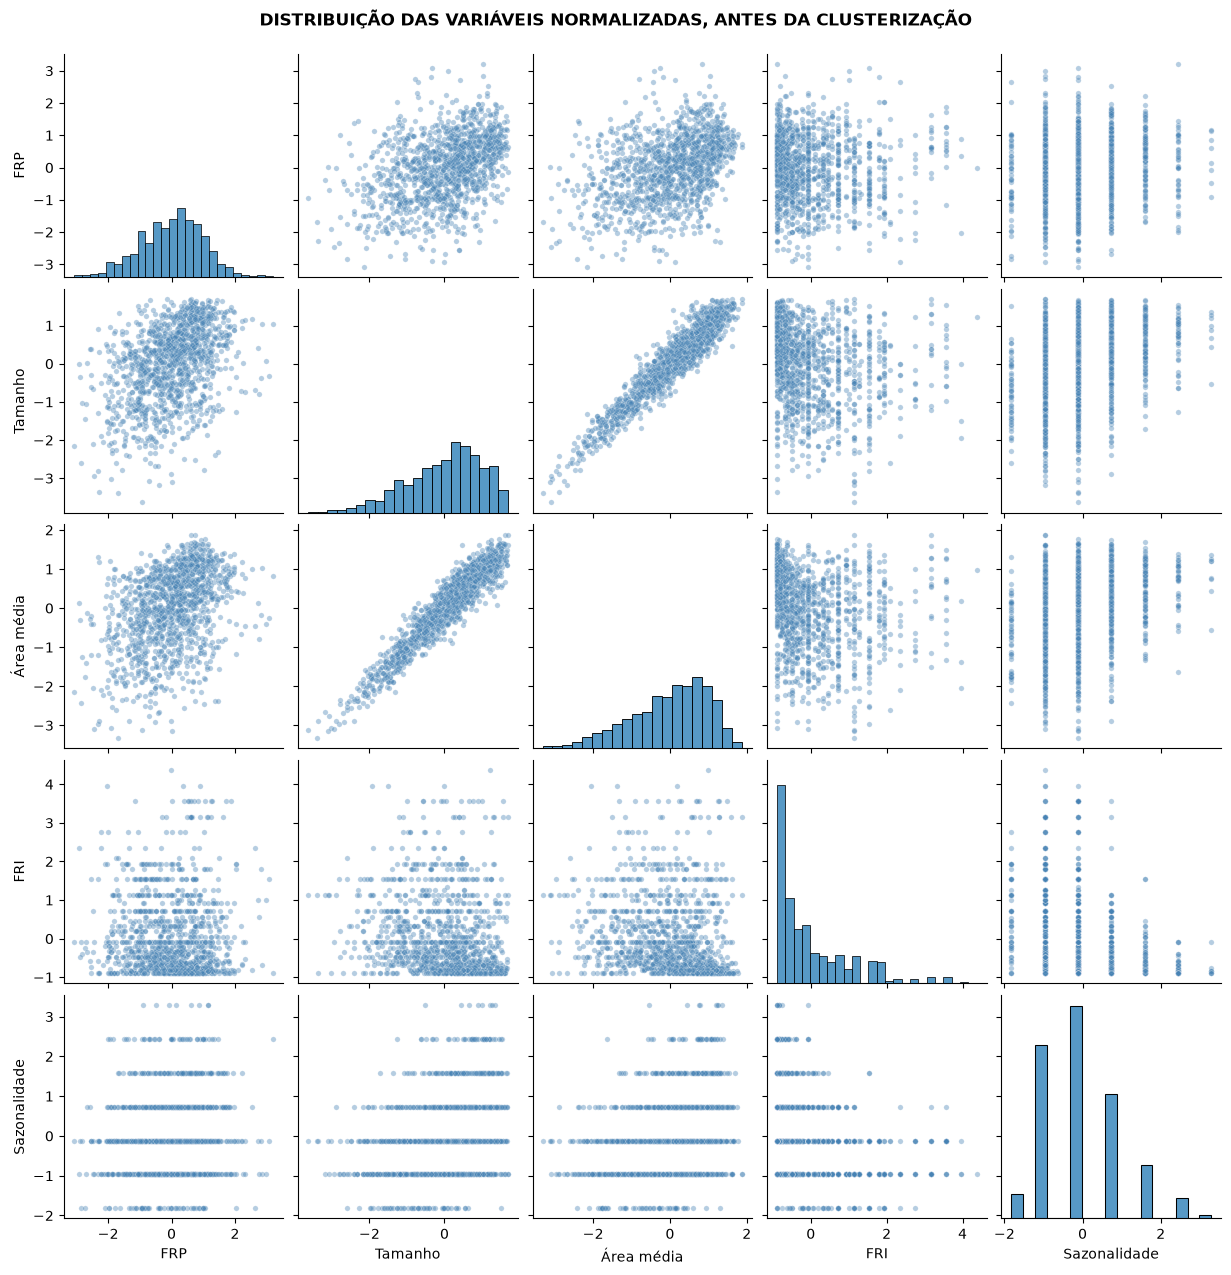

In [24]:
# Gráfico de pares — distribuição bruta das cinco variáveis normalizadas, antes do clustering

pairplot_df = group_a_norm[feature_cols].copy()
pairplot_df.columns = ['FRP', 'Tamanho', 'Área média', 'FRI', 'Sazonalidade']

fig = sns.pairplot(pairplot_df, diag_kind='hist', plot_kws={'alpha': 0.4, 's': 15, 'color': 'steelblue'})
fig.figure.suptitle('DISTRIBUIÇÃO DAS VARIÁVEIS NORMALIZADAS, ANTES DA CLUSTERIZAÇÃO', fontweight='bold', y=1.02)

plt.savefig(os.path.join(PRINTS_DIR, "pairplot_antes_clustering.png"), dpi=200, bbox_inches='tight')
plt.show()

# Etapa 05 - Modelagem

Foi testado três algoritmos de clustering sobre a mesma matriz normalizada das cinco variáveis, usando só o Grupo A, pra comparar qual encontra o agrupamento mais consistente entre as células com dado confiável. Os três recebem exatamente o mesmo insumo de entrada, garantindo que a comparação entre eles seja justa.

## Classificação com K-means

O algoritmo posiciona um centro pra cada grupo e atribui cada célula ao centro mais próximo, recalculando os centros até a atribuição parar de mudar. Testado de K=3 a K=8, usando inércia e silhouette score como critério de escolha. K=3 teve o melhor silhouette entre todos os valores testados,  com um silhouette de 0.29, e foi o algoritmo escolhido como resultado principal do projeto.

In [62]:
# K-means — testar K de 3 a 8, usando inércia (cotovelo) e silhouette score

kmeans_results = []

for k in range(3, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    inertia = kmeans.inertia_
    silhouette = silhouette_score(X, labels)

    kmeans_results.append({'k': k, 'inertia': inertia, 'silhouette': silhouette})
    print(f"K={k} | Inércia={inertia:.1f} | Silhouette={silhouette:.3f}")

kmeans_results_df = pd.DataFrame(kmeans_results)

K=3 | Inércia=3495.3 | Silhouette=0.295
K=4 | Inércia=3001.8 | Silhouette=0.228
K=5 | Inércia=2660.0 | Silhouette=0.226
K=6 | Inércia=2400.6 | Silhouette=0.225
K=7 | Inércia=2231.0 | Silhouette=0.227
K=8 | Inércia=2078.0 | Silhouette=0.215


In [63]:
# K-means final com K=3, interpretação dos clusters

KMEANS_BEST_K  = 3

kmeans_final = KMeans(n_clusters=KMEANS_BEST_K , random_state=42, n_init=10)
group_a_norm['cluster_kmeans'] = kmeans_final.fit_predict(X)

print("Distribuição de células por cluster:")
print(group_a_norm['cluster_kmeans'].value_counts().sort_index())

Distribuição de células por cluster:
cluster_kmeans
0    233
1    640
2    412
Name: count, dtype: int64


In [64]:
# Trazer as variáveis originais (não normalizadas) para interpretar o significado de cada cluster

kmeans_summary = (
    group_a.merge(group_a_norm[['cell_id', 'cluster_kmeans']], on='cell_id', how='left')
    .groupby('cluster_kmeans')[['fri_mean', 'frp_mean', 'n_months_80pct', 'size_max', 'annual_area_mean']]
    .agg(['mean', 'median', 'count'])
)

kmeans_summary

fri_mean                   frp_mean                  n_months_80pct                  size_max                    annual_area_mean                   
                    mean    median count       mean     median count           mean median count         mean       median count             mean       median count
cluster_kmeans                                                                                                                                                      
0               3.985980  4.000000   233  40.235836  36.068420   233       2.278970    2.0   233  1915.273190  1265.662668   233      1370.186603   876.027166   233
1               1.401099  1.181818   640  41.554344  38.203285   640       3.768750    4.0   640  3115.545418  2448.439360   640      2025.993690  1709.354127   640
2               2.122392  2.000000   412  25.584461  22.449596   412       2.643204    3.0   412   338.831331   236.793154   412       223.307339   171.132817   412

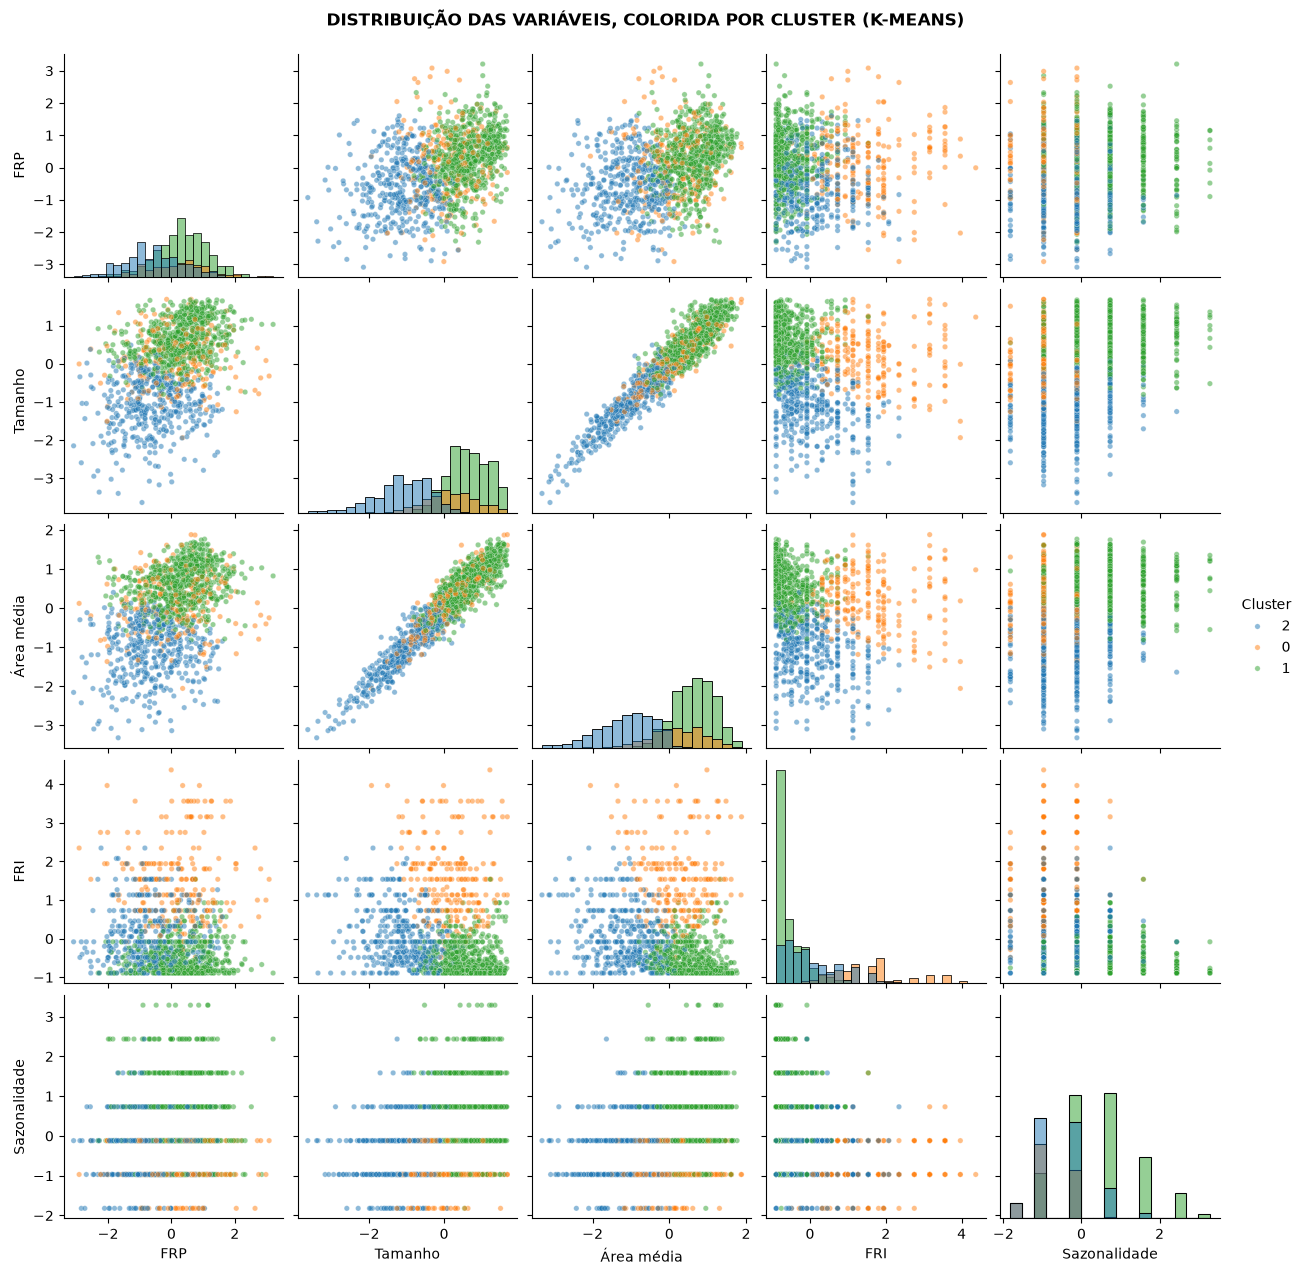

In [65]:
# Gráfico de pares — mesma distribuição, agora colorida pelos clusters do K-means

pairplot_cluster_df = group_a_norm[feature_cols + ['cluster_kmeans']].copy()
pairplot_cluster_df.columns = ['FRP', 'Tamanho', 'Área média', 'FRI', 'Sazonalidade', 'Cluster']
pairplot_cluster_df['Cluster'] = pairplot_cluster_df['Cluster'].astype(str)

fig = sns.pairplot(
    pairplot_cluster_df, hue='Cluster', diag_kind='hist',
    plot_kws={'alpha': 0.5, 's': 15}, palette='tab10'
)
fig.figure.suptitle('DISTRIBUIÇÃO DAS VARIÁVEIS, COLORIDA POR CLUSTER (K-MEANS)', fontweight='bold', y=1.02)

plt.savefig(os.path.join(PRINTS_DIR, "pairplot_depois_clustering_k-means.png"), dpi=200, bbox_inches='tight')
plt.show()

## Clustering hierárquico

Constrói uma árvore de agrupamento, começando com cada célula isolada e fundindo progressivamente as mais parecidas, até que tudo esteja num único grupo. Usa o critério de linkage de Ward, que escolhe, a cada fusão, o par de grupos que resultaria no menor aumento possível de variância interna. Testado nos mesmos valores de K, teve silhouette mais baixo que o K-means, de 0.23 no melhor caso, mas convergiu pro mesmo padrão de três grupos, com perfis muito parecidos. Essa convergência entre dois algoritmos de lógica matemática diferente reforça que a estrutura de três regimes de fogo é real, não um artefato da escolha de método.

In [66]:
# Linkage de Ward
Z = linkage(X, method='ward')

print("Linkage calculado, shape:", Z.shape)

Linkage calculado, shape: (1284, 4)


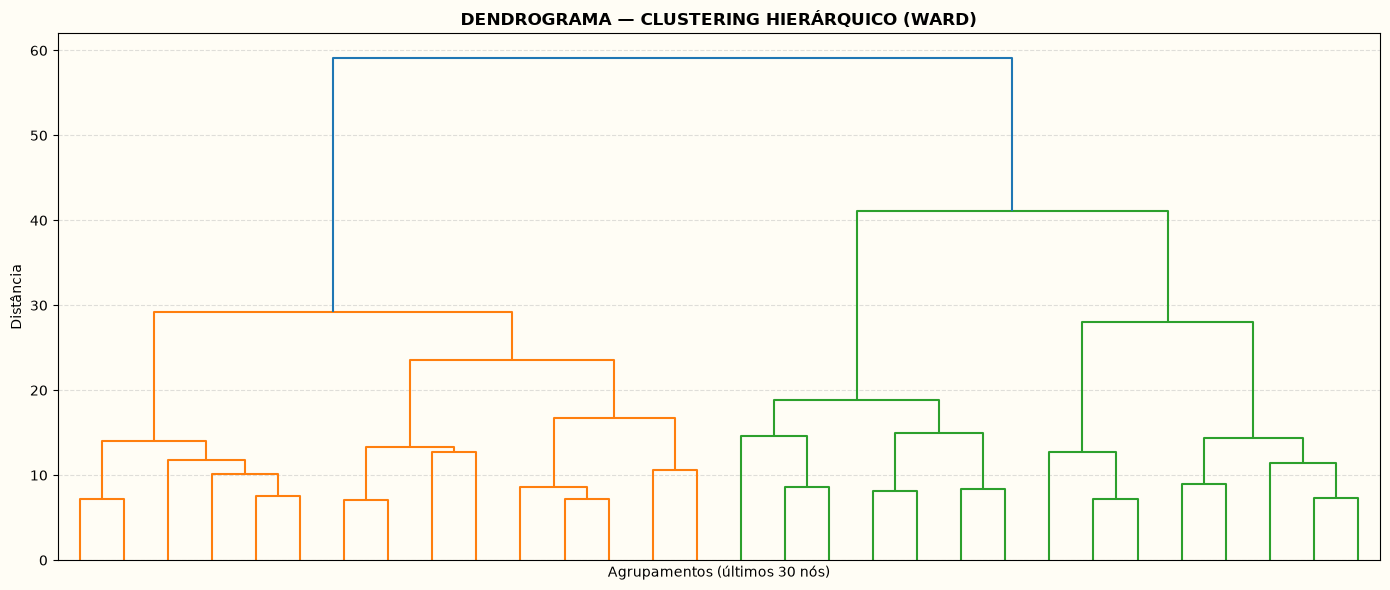

In [67]:
# Dendrograma — visualização da estrutura hierárquica completa

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#FFFDF5')
ax.set_facecolor('#FFFDF5')

dendrogram(Z, truncate_mode='lastp', p=30, ax=ax, no_labels=True)

ax.set_title('DENDROGRAMA — CLUSTERING HIERÁRQUICO (WARD)', fontweight='bold')
ax.set_xlabel('Agrupamentos (últimos 30 nós)')
ax.set_ylabel('Distância')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(PRINTS_DIR, "dendrograma_hierarquico.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

In [68]:
# Testar diferentes cortes (número de clusters)

hierarchical_results = []

for k in range(3, 9):
    labels = fcluster(Z, t=k, criterion='maxclust')
    
    silhouette = silhouette_score(X, labels)
    davies_bouldin = davies_bouldin_score(X, labels)
    
    hierarchical_results.append({'k': k, 'silhouette': silhouette, 'davies_bouldin': davies_bouldin})
    print(f"K={k} | Silhouette={silhouette:.3f} | Davies-Bouldin={davies_bouldin:.3f}")

hierarchical_results_df = pd.DataFrame(hierarchical_results)

K=3 | Silhouette=0.234 | Davies-Bouldin=1.400
K=4 | Silhouette=0.189 | Davies-Bouldin=1.513
K=5 | Silhouette=0.168 | Davies-Bouldin=1.467
K=6 | Silhouette=0.173 | Davies-Bouldin=1.450
K=7 | Silhouette=0.178 | Davies-Bouldin=1.570
K=8 | Silhouette=0.178 | Davies-Bouldin=1.498


In [69]:
HIERARCHICAL_BEST_K = 3

group_a_norm['cluster_hierarchical'] = fcluster(Z, t=HIERARCHICAL_BEST_K, criterion='maxclust') - 1

print("Distribuição de células por cluster (Hierárquico):")
print(group_a_norm['cluster_hierarchical'].value_counts().sort_index())


Distribuição de células por cluster (Hierárquico):
cluster_hierarchical
0    531
1    240
2    514
Name: count, dtype: int64


In [70]:
hierarchical_summary = (
    group_a.merge(group_a_norm[['cell_id', 'cluster_hierarchical']], on='cell_id', how='left')
    .groupby('cluster_hierarchical')[['fri_mean', 'frp_mean', 'n_months_80pct', 'size_max', 'annual_area_mean']]
    .agg(['mean', 'median', 'count'])
)

print(hierarchical_summary)

                      fri_mean                   frp_mean                  n_months_80pct                  size_max                    annual_area_mean                   
                          mean    median count       mean     median count           mean median count         mean       median count             mean       median count
cluster_hierarchical                                                                                                                                                      
0                     2.160213  1.857143   531  24.709488  20.972311   531       2.890772    3.0   531   541.045078   369.891249   531       372.880443   238.171253   531
1                     3.691708  3.500000   240  48.608616  44.832878   240       2.479167    2.0   240  2478.243966  1681.617378   240      1666.385825  1226.919430   240
2                     1.297235  1.153846   514  42.264053  38.385208   514       3.700389    4.0   514  3302.981986  2704.087941   514      2159.

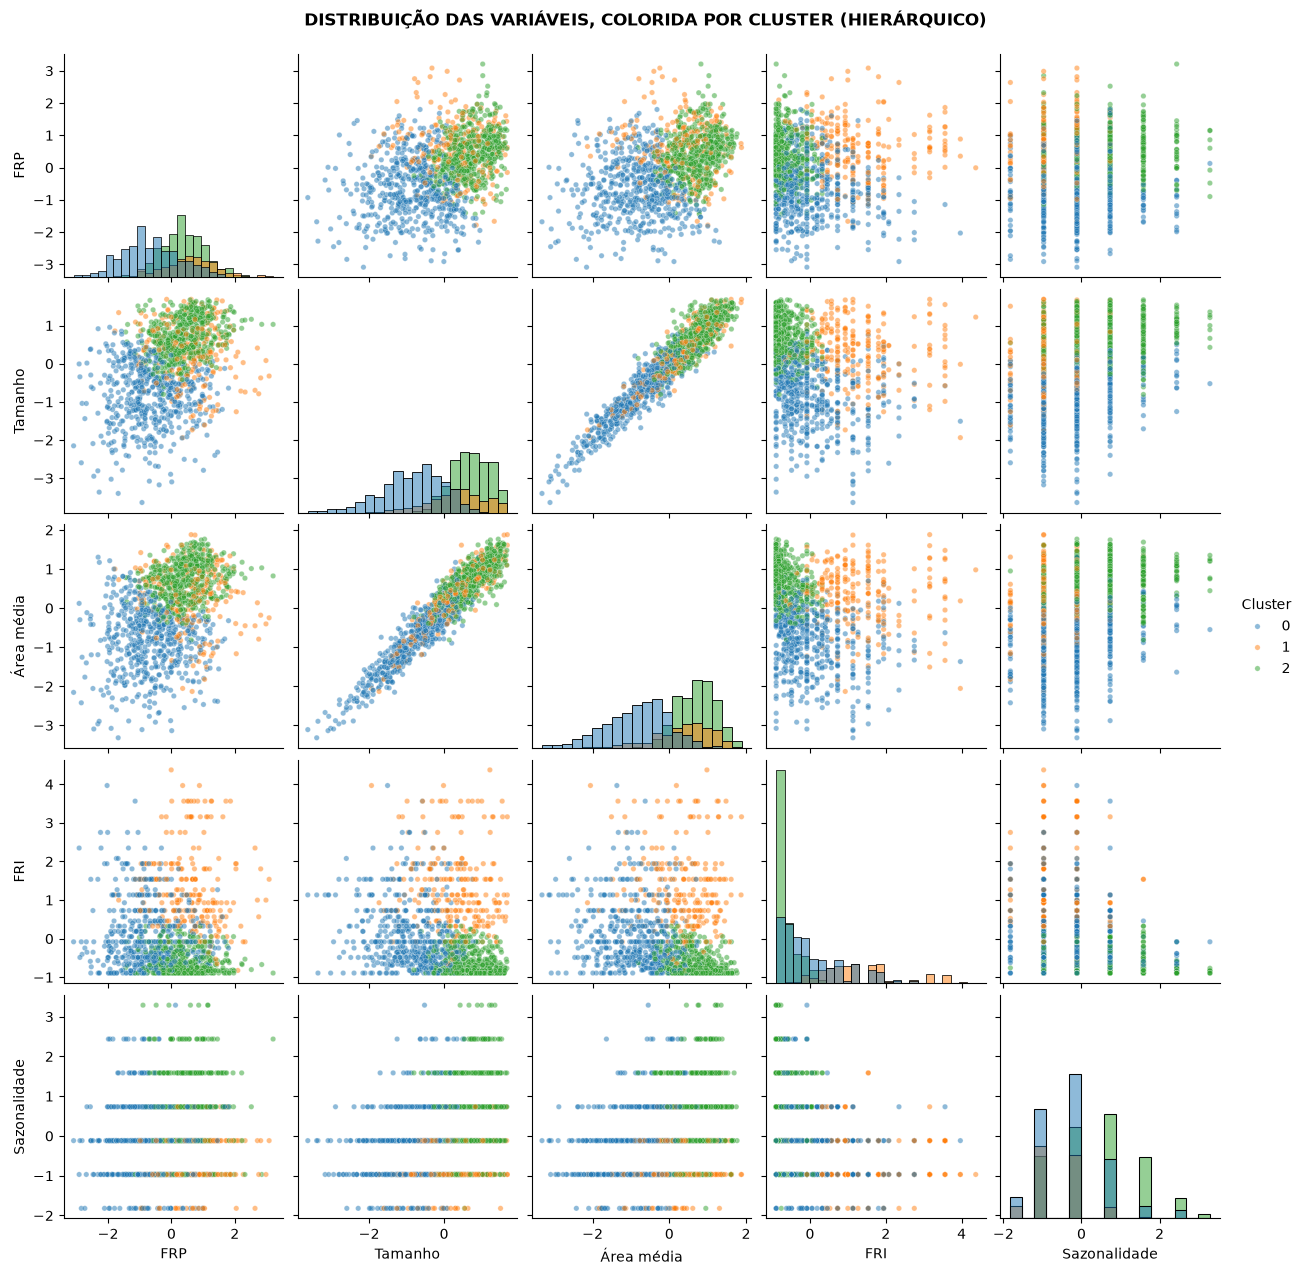

In [71]:
# Gráfico de pares 

pairplot_cluster_df = group_a_norm[feature_cols + ['cluster_hierarchical']].copy()
pairplot_cluster_df.columns = ['FRP', 'Tamanho', 'Área média', 'FRI', 'Sazonalidade', 'Cluster']
pairplot_cluster_df['Cluster'] = pairplot_cluster_df['Cluster'].astype(str)

fig = sns.pairplot(
    pairplot_cluster_df, hue='Cluster', diag_kind='hist',
    plot_kws={'alpha': 0.5, 's': 15}, palette='tab10'
)
fig.figure.suptitle('DISTRIBUIÇÃO DAS VARIÁVEIS, COLORIDA POR CLUSTER (HIERÁRQUICO)', fontweight='bold', y=1.02)

plt.savefig(os.path.join(PRINTS_DIR, "pairplot_depois_clustering_hierarquico.png"), dpi=200, bbox_inches='tight')
plt.show()

## GMM (Gaussian Mixture Model)

Assume que cada cluster segue uma distribuição gaussiana própria, e calcula a probabilidade de cada célula pertencer a cada grupo, em vez de uma atribuição rígida e exclusiva. Avaliado com AIC e BIC, critérios que medem o ajuste do modelo penalizando complexidade excessiva, além do silhouette. Teve desempenho bem inferior aos outros dois algoritmos, silhouette máximo de 0,094. A causa provável está na natureza de duas das cinco variáveis, FRI e sazonalidade têm distribuição discreta, com poucos valores possíveis, distante do formato de sino que o método pressupõe, o que prejudicou o ajuste das gaussianas aos dados reais.


In [72]:
# Testar diferentes números de componentes, usando AIC, BIC e silhouette

gmm_results = []

for k in range(3, 9):
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=10)
    labels = gmm.fit_predict(X)

    aic = gmm.aic(X)
    bic = gmm.bic(X)
    silhouette = silhouette_score(X, labels)

    gmm_results.append({'k': k, 'aic': aic, 'bic': bic, 'silhouette': silhouette})
    print(f"K={k} | AIC={aic:.1f} | BIC={bic:.1f} | Silhouette={silhouette:.3f}")

gmm_results_df = pd.DataFrame(gmm_results)

K=3 | AIC=12969.4 | BIC=13289.2 | Silhouette=0.080
K=4 | AIC=12852.1 | BIC=13280.2 | Silhouette=0.064
K=5 | AIC=12838.1 | BIC=13374.6 | Silhouette=0.094
K=6 | AIC=12810.6 | BIC=13455.4 | Silhouette=0.089
K=7 | AIC=12783.5 | BIC=13536.6 | Silhouette=0.063
K=8 | AIC=12784.0 | BIC=13645.5 | Silhouette=0.033


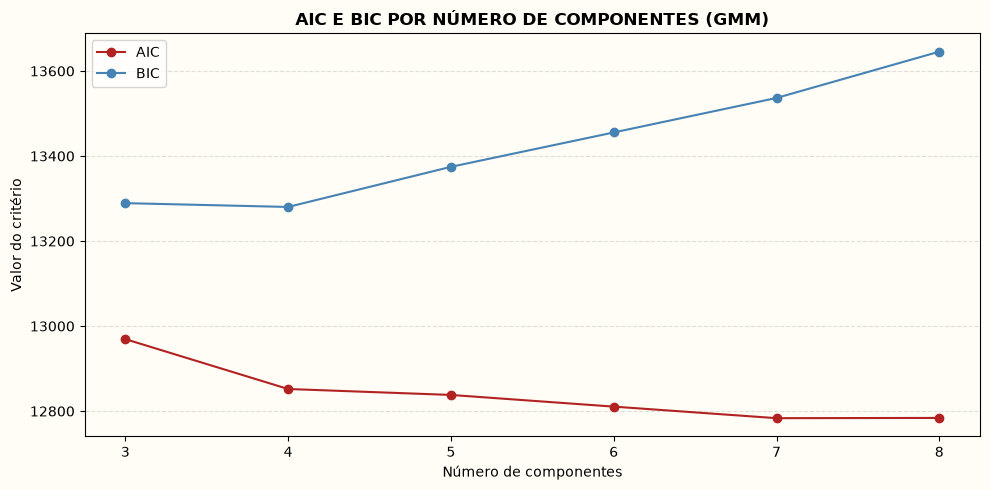

In [73]:
# Gráfico comparando AIC e BIC por número de componentes, ajuda a visualizar o ponto de melhor equilíbrio

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#FFFDF5')
ax.set_facecolor('#FFFDF5')

ax.plot(gmm_results_df['k'], gmm_results_df['aic'], marker='o', label='AIC', color='firebrick')
ax.plot(gmm_results_df['k'], gmm_results_df['bic'], marker='o', label='BIC', color='steelblue')

ax.set_xlabel('Número de componentes')
ax.set_ylabel('Valor do critério')
ax.set_title('AIC E BIC POR NÚMERO DE COMPONENTES (GMM)', fontweight='bold')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(PRINTS_DIR, "gmm_aic_bic.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

In [74]:
GMM_BEST_K = 3

gmm_final = GaussianMixture(n_components=GMM_BEST_K, random_state=42, n_init=10)
group_a_norm['cluster_gmm'] = gmm_final.fit_predict(X)

# Probabilidade de pertencimento a cada componente, guardada à parte para uso futuro (soft clustering)
gmm_probabilities = gmm_final.predict_proba(X)
group_a_norm['gmm_max_probability'] = gmm_probabilities.max(axis=1)

print("Distribuição de células por cluster (GMM):")
print(group_a_norm['cluster_gmm'].value_counts().sort_index())

print("\nProbabilidade média do componente atribuído:", group_a_norm['gmm_max_probability'].mean().round(3))
print("Células com atribuição pouco confiante (probabilidade < 0.6):", (group_a_norm['gmm_max_probability'] < 0.6).sum())

Distribuição de células por cluster (GMM):
cluster_gmm
0    458
1    323
2    504
Name: count, dtype: int64

Probabilidade média do componente atribuído: 0.885
Células com atribuição pouco confiante (probabilidade < 0.6): 83


In [75]:
gmm_summary = (
    group_a.merge(group_a_norm[['cell_id', 'cluster_gmm']], on='cell_id', how='left')
    .groupby('cluster_gmm')[['fri_mean', 'frp_mean', 'n_months_80pct', 'size_max', 'annual_area_mean']]
    .agg(['mean', 'median', 'count'])
)

print(gmm_summary)

             fri_mean                   frp_mean                  n_months_80pct                  size_max                    annual_area_mean                   
                 mean    median count       mean     median count           mean median count         mean       median count             mean       median count
cluster_gmm                                                                                                                                                      
0            3.357699  3.250000   458  35.623978  30.799227   458       2.460699    2.0   458  1316.802771   509.078317   458       900.063562   347.646833   458
1            1.057405  1.071429   323  40.944496  38.461781   323       3.941176    4.0   323  3365.694318  2712.767820   323      2436.163020  2167.537804   323
2            1.627964  1.571429   504  33.669987  29.876801   504       3.238095    3.0   504  1765.062094  1173.914318   504      1009.488684   646.659036   504


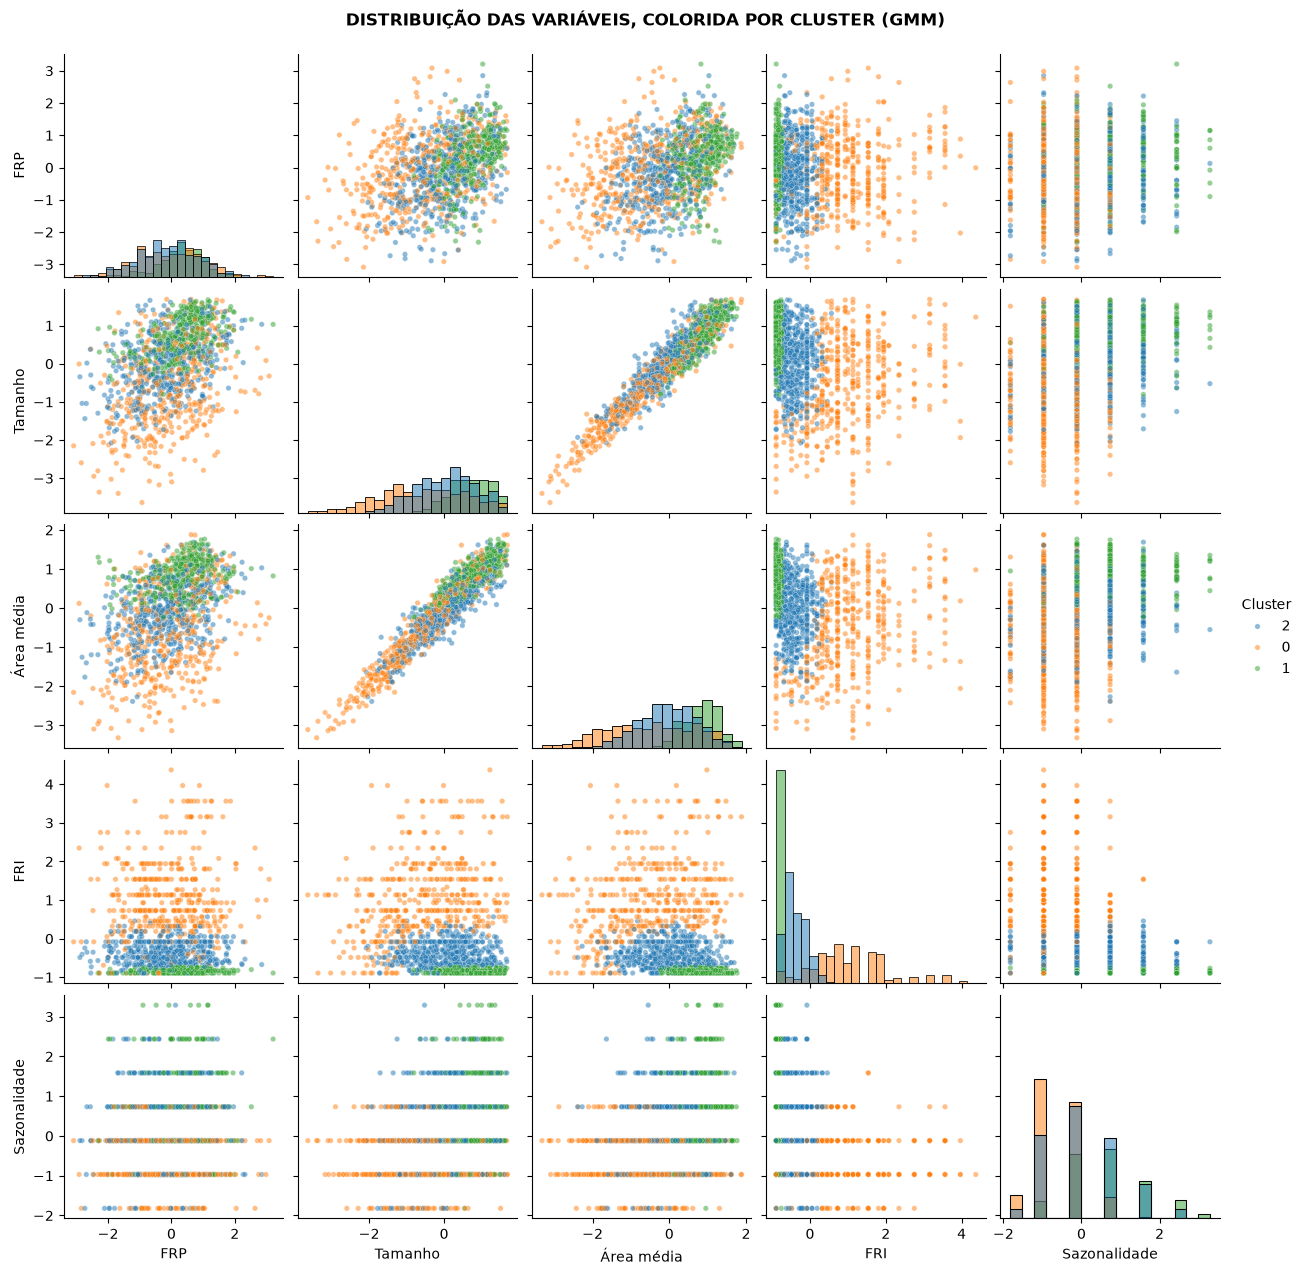

In [76]:
pairplot_cluster_df = group_a_norm[feature_cols + ['cluster_gmm']].copy()
pairplot_cluster_df.columns = ['FRP', 'Tamanho', 'Área média', 'FRI', 'Sazonalidade', 'Cluster']
pairplot_cluster_df['Cluster'] = pairplot_cluster_df['Cluster'].astype(str)

fig = sns.pairplot(
    pairplot_cluster_df, hue='Cluster', diag_kind='hist',
    plot_kws={'alpha': 0.5, 's': 15}, palette='tab10'
)
fig.figure.suptitle('DISTRIBUIÇÃO DAS VARIÁVEIS, COLORIDA POR CLUSTER (GMM)', fontweight='bold', y=1.02)

plt.savefig(os.path.join(PRINTS_DIR, "pairplot_depois_clustering_gmm.png"), dpi=200, bbox_inches='tight')
plt.show()

# Etapa 06 - Avaliação do modelo

Compara os três algoritmos testados na modelagem, e investiga o que o resultado escolhido, K-means com K=3, realmente representa, tanto em termos de qualidade estatística quanto de significado geográfico e prático.

K-means teve o melhor silhouette entre os três, 0.29, seguido do hierárquico, 0.23, e do GMM, bem abaixo, 0.094. A convergência entre K-means e hierárquico pro mesmo padrão de três grupos, mesmo vindo de lógicas matemáticas diferentes, foi o principal argumento pra confiar na estrutura encontrada como real. K-means foi confirmado como algoritmo definitivo do projeto.

In [77]:
# Reordenar os rótulos de cada algoritmo por FRI médio, para comparação justa entre métodos

def reorder_by_fri(df, cluster_col):
    fri_order = (
        group_a.merge(df[['cell_id', cluster_col]], on='cell_id', how='left')
        .groupby(cluster_col)['fri_mean'].mean()
        .sort_values(ascending=False)
    )
    relabel_map = {old: new for new, old in enumerate(fri_order.index)}
    return df[cluster_col].map(relabel_map)

group_a_norm['cluster_kmeans_ord'] = reorder_by_fri(group_a_norm, 'cluster_kmeans')
group_a_norm['cluster_hierarchical_ord'] = reorder_by_fri(group_a_norm, 'cluster_hierarchical')
group_a_norm['cluster_gmm_ord'] = reorder_by_fri(group_a_norm, 'cluster_gmm')

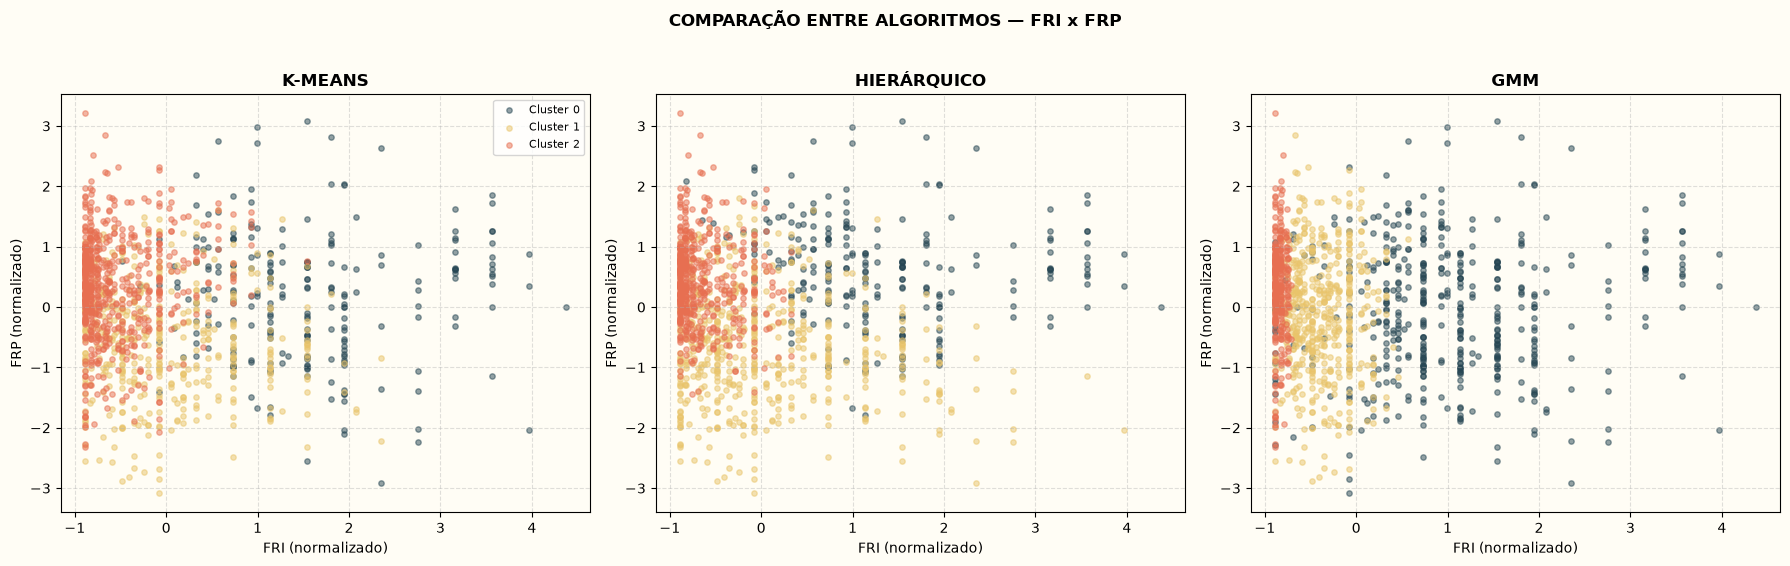

In [78]:
# Comparação visual dos três algoritmos, mesmo par de variáveis, lado a lado

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.patch.set_facecolor('#FFFDF5')

algo_cols = ['cluster_kmeans_ord', 'cluster_hierarchical_ord', 'cluster_gmm_ord']
algo_titles = ['K-MEANS', 'HIERÁRQUICO', 'GMM']
palette = {0: '#264653', 1: '#e9c46a', 2: '#e76f51'}

for ax, col, title in zip(axes, algo_cols, algo_titles):
    ax.set_facecolor('#FFFDF5')
    for cluster_val, color in palette.items():
        subset = group_a_norm[group_a_norm[col] == cluster_val]
        ax.scatter(subset['fri_mean_norm'], subset['frp_mean_norm'], s=15, alpha=0.5, color=color, label=f'Cluster {cluster_val}')
    ax.set_xlabel('FRI (normalizado)')
    ax.set_ylabel('FRP (normalizado)')
    ax.set_title(title, fontweight='bold')
    ax.grid(linestyle='--', alpha=0.4)

axes[0].legend(fontsize=8)
fig.suptitle('COMPARAÇÃO ENTRE ALGORITMOS — FRI x FRP', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PRINTS_DIR, "comparacao_algoritmos_fri_frp.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

In [79]:
# Mapa final — só K-means, incluindo o Grupo B com rótulo de dado insuficiente

# Grupo A, com o cluster já atribuído
group_a_map = group_a.merge(
    group_a_norm[['cell_id', 'cluster_kmeans_ord']], on='cell_id', how='left'
)
group_a_map['fire_regime_label'] = group_a_map['cluster_kmeans_ord']

# Grupo B, com rótulo fixo
group_b_map = fire_regime_vector[fire_regime_vector['group'] == 'B_insuficiente'][['cell_id']].copy()
group_b_map['fire_regime_label'] = 'insuficiente'

# União dos dois, com geometria
fire_regime_map = pd.concat([
    group_a_map[['cell_id', 'fire_regime_label']],
    group_b_map[['cell_id', 'fire_regime_label']]
], ignore_index=True)

fire_regime_map = fire_regime_map.merge(gdf_grid[['cell_id', 'geometry']], on='cell_id', how='left')
fire_regime_map = gpd.GeoDataFrame(fire_regime_map, geometry='geometry', crs=gdf_grid.crs).to_crs(4326)

print("Total de células no mapa:", len(fire_regime_map))
print(fire_regime_map['fire_regime_label'].value_counts())

# %%
cluster_colors = {0: '#264653', 1: '#e9c46a', 2: '#e76f51', 'insuficiente': '#d9d9d9'}
cluster_labels = {0: 'Fogo raro/intenso', 1: 'Intermediário', 2: 'Fogo frequente/extenso', 'insuficiente': 'Dado insuficiente'}

Map = geemap.Map(center=[-14.2350, -51.9253], zoom=4)

Map.add_gdf(
    gdf_ucs_metric.to_crs(4326),
    layer_name="Limites das UCs",
    style={"color": "black", "fillOpacity": 0, "weight": 1},
    info_mode=None,
)

for label_val, color in cluster_colors.items():
    subset = fire_regime_map[fire_regime_map['fire_regime_label'] == label_val]
    Map.add_gdf(
        subset[['fire_regime_label', 'geometry']],
        layer_name=cluster_labels[label_val],
        style={"color": color, "fillColor": color, "fillOpacity": 0.6, "weight": 0},
        info_mode=None,
    )

Map.add_basemap('HYBRID')
Map

Total de células no mapa: 22687
fire_regime_label
insuficiente    21402
2                 640
1                 412
0                 233
Name: count, dtype: int64


Map(center=[-14.235, -51.9253], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topr…

### K-means: Cruzamento cluster x tipo de evento harmonizado

In [80]:
# Pega o event_type predominante por célula
event_type_by_cell = (
    gdf_aaf_metric.dropna(subset=['event_type'])
    .groupby('cell_id')['event_type']
    .agg(lambda x: x.value_counts().idxmax())
    .rename('event_type_predominant')
)

cluster_with_type = (
    group_a.merge(group_a_norm[['cell_id', 'cluster_kmeans']], on='cell_id', how='left')
    .merge(event_type_by_cell, on='cell_id', how='left')
)

print("Células com event_type predominante identificado:", cluster_with_type['event_type_predominant'].notna().sum(), "de", len(cluster_with_type))

Células com event_type predominante identificado: 1272 de 1285


In [81]:
cluster_type_crosstab = pd.crosstab(
    cluster_with_type['cluster_kmeans'],
    cluster_with_type['event_type_predominant'],
    margins=True
)

cluster_type_crosstab

event_type_predominant,antropica,incendio,natural,queima controlada,queima prescrita,All
cluster_kmeans,,,,,,
0,13,184,10,0,26,233
1,11,478,3,7,138,637
2,6,370,1,6,19,402
All,30,1032,14,13,183,1272


In [82]:
cluster_type_pct = pd.crosstab(
    cluster_with_type['cluster_kmeans'],
    cluster_with_type['event_type_predominant'],
    normalize='index'
) * 100

cluster_type_pct.round(1)

event_type_predominant,antropica,incendio,natural,queima controlada,queima prescrita
cluster_kmeans,,,,,
0,5.6,79.0,4.3,0.0,11.2
1,1.7,75.0,0.5,1.1,21.7
2,1.5,92.0,0.2,1.5,4.7


# Etapa 07 - Ajuste de hiperparâmetros

Testa a sensibilidade do resultado final a mudanças nos thresholds de robustez definidos no pré-processamento, verificando se a escolha original, mínimo de 3 anos ou 3 eventos, 5 focos de calor, é a mais adequada ou se outro valor traria ganho relevante.

**O que foi testado**

Três cenários de threshold comparados, um mais permissivo, exigindo menos observações mínimas, o cenário atual, e um mais rigoroso, exigindo mais. Pra cada cenário, o Grupo A foi reconstruído, normalizado, e o K-means com K=3 foi rodado novamente, comparando tamanho do Grupo A resultante e silhouette score.

**Resultado**

| Threshold | Grupo A | Silhouette |
|---|---|---|
| Mais permissivo | 7,6% | 0,304 |
| Atual | 5,7% | 0,295 |
| Mais rigoroso | 4,5% | 0,284 |

A cobertura varia de forma esperada, threshold mais permissivo aumenta o Grupo A, mais rigoroso diminui. O silhouette varia pouco entre os três cenários, sem uma diferença que justifique mudança. O perfil dos três clusters se manteve coerente nos três cenários testados, mesmo padrão geral de fogo frequente e extenso, intermediário, e raro e intenso.

**Decisão**

Threshold original mantido. O ganho marginal de silhouette no cenário mais permissivo, 0,304 contra 0,295, não compensa a perda de robustez individual por célula, principalmente no cluster de fogo raro, onde um threshold mais frouxo permite intervalos calculados com apenas dois pontos de observação, mais instáveis e menos confiáveis que os calculados com o mínimo de três anos already exigido.

Esse teste não altera o pipeline definitivo, fica registrado como validação de que o resultado é razoavelmente estável dentro da faixa testada, reforçando a escolha original em vez de motivar mudança.

In [46]:
# Teste de sensibilidade dos thresholds

threshold_scenarios = [
    {'min_years_fri': 2, 'min_hotspots_frp': 3, 'min_events_seasonality': 2, 'min_years_area': 2},
    {'min_years_fri': 3, 'min_hotspots_frp': 5, 'min_events_seasonality': 3, 'min_years_area': 3},  #  atual
    {'min_years_fri': 4, 'min_hotspots_frp': 8, 'min_events_seasonality': 4, 'min_years_area': 4},
]

hyperparam_results = []

for scenario in threshold_scenarios:

    # Reaplicar os thresholds 
    fri_reliable_test = fri_raw['n_fire_years'] >= scenario['min_years_fri']
    frp_reliable_test = frp_raw['n_hotspots'] >= scenario['min_hotspots_frp']
    seasonality_reliable_test = seasonality_raw['n_events'] >= scenario['min_events_seasonality']
    area_reliable_test = annual_area_raw['n_years'] >= scenario['min_years_area']

    fri_ok_cells = set(fri_raw.loc[fri_reliable_test, 'cell_id'])
    frp_ok_cells = set(frp_raw.loc[frp_reliable_test, 'cell_id'])
    seasonality_ok_cells = set(seasonality_raw.loc[seasonality_reliable_test, 'cell_id'])
    area_ok_cells = set(annual_area_raw.loc[area_reliable_test, 'cell_id'])

    group_a_cells_test = fri_ok_cells & frp_ok_cells & seasonality_ok_cells & area_ok_cells

    # Montar o vetor normalizado só para essas células
    group_a_test = fire_regime_vector[fire_regime_vector['cell_id'].isin(group_a_cells_test)].copy()

    if len(group_a_test) < 10:
        print(f"Cenário {scenario} — Grupo A pequeno demais ({len(group_a_test)} células), pulado")
        continue

    group_a_test_norm = group_a_test[['cell_id']].copy()
    for col in log_transform_cols:
        logged = np.log1p(group_a_test[col])
        group_a_test_norm[f'{col}_norm'] = (logged - logged.mean()) / logged.std()
    for col in direct_zscore_cols:
        group_a_test_norm[f'{col}_norm'] = (group_a_test[col] - group_a_test[col].mean()) / group_a_test[col].std()

    X_test = group_a_test_norm[feature_cols].values

    kmeans_test = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels_test = kmeans_test.fit_predict(X_test)
    silhouette_test = silhouette_score(X_test, labels_test)

    hyperparam_results.append({
        'thresholds': str(scenario),
        'n_group_a': len(group_a_test),
        'pct_group_a': len(group_a_test) / TOTAL_CELLS * 100,
        'silhouette_k3': silhouette_test,
    })

    print(f"Thresholds {scenario}")
    print(f"  Grupo A: {len(group_a_test)} células ({len(group_a_test) / TOTAL_CELLS * 100:.1f}%)")
    print(f"  Silhouette (K=3): {silhouette_test:.3f}")
    print()

hyperparam_results_df = pd.DataFrame(hyperparam_results)
hyperparam_results_df

Thresholds {'min_years_fri': 2, 'min_hotspots_frp': 3, 'min_events_seasonality': 2, 'min_years_area': 2}
  Grupo A: 1713 células (7.6%)
  Silhouette (K=3): 0.304

Thresholds {'min_years_fri': 3, 'min_hotspots_frp': 5, 'min_events_seasonality': 3, 'min_years_area': 3}
  Grupo A: 1285 células (5.7%)
  Silhouette (K=3): 0.295

Thresholds {'min_years_fri': 4, 'min_hotspots_frp': 8, 'min_events_seasonality': 4, 'min_years_area': 4}
  Grupo A: 1032 células (4.5%)
  Silhouette (K=3): 0.284



,thresholds,n_group_a,pct_group_a,silhouette_k3
0,"{'min_years_fri': 2, 'min_hotspots_frp': 3, 'm...",1713,7.550580,0.304166
1,"{'min_years_fri': 3, 'min_hotspots_frp': 5, 'm...",1285,5.664037,0.294561
2,"{'min_years_fri': 4, 'min_hotspots_frp': 8, 'm...",1032,4.548861,0.283605


In [47]:
# Perfil dos clusters no cenário de threshold mais permissivo, para comparar com o atual

scenario_permissive = {'min_years_fri': 2, 'min_hotspots_frp': 3, 'min_events_seasonality': 2, 'min_years_area': 2}

fri_reliable_perm = fri_raw['n_fire_years'] >= scenario_permissive['min_years_fri']
frp_reliable_perm = frp_raw['n_hotspots'] >= scenario_permissive['min_hotspots_frp']
seasonality_reliable_perm = seasonality_raw['n_events'] >= scenario_permissive['min_events_seasonality']
area_reliable_perm = annual_area_raw['n_years'] >= scenario_permissive['min_years_area']

fri_ok_cells_perm = set(fri_raw.loc[fri_reliable_perm, 'cell_id'])
frp_ok_cells_perm = set(frp_raw.loc[frp_reliable_perm, 'cell_id'])
seasonality_ok_cells_perm = set(seasonality_raw.loc[seasonality_reliable_perm, 'cell_id'])
area_ok_cells_perm = set(annual_area_raw.loc[area_reliable_perm, 'cell_id'])

group_a_cells_perm = fri_ok_cells_perm & frp_ok_cells_perm & seasonality_ok_cells_perm & area_ok_cells_perm

group_a_permissive = fire_regime_vector[fire_regime_vector['cell_id'].isin(group_a_cells_perm)].copy()

print("Grupo A (threshold permissivo):", len(group_a_permissive))

Grupo A (threshold permissivo): 1713


In [48]:
# Normalizar e rodar K-means com K=3

group_a_permissive_norm = group_a_permissive[['cell_id']].copy()

for col in log_transform_cols:
    logged = np.log1p(group_a_permissive[col])
    group_a_permissive_norm[f'{col}_norm'] = (logged - logged.mean()) / logged.std()

for col in direct_zscore_cols:
    group_a_permissive_norm[f'{col}_norm'] = (group_a_permissive[col] - group_a_permissive[col].mean()) / group_a_permissive[col].std()

X_permissive = group_a_permissive_norm[feature_cols].values

kmeans_permissive = KMeans(n_clusters=3, random_state=42, n_init=10)
group_a_permissive_norm['cluster_kmeans'] = kmeans_permissive.fit_predict(X_permissive)

print("Distribuição de células por cluster (threshold permissivo):")
print(group_a_permissive_norm['cluster_kmeans'].value_counts().sort_index())

Distribuição de células por cluster (threshold permissivo):
cluster_kmeans
0    870
1    543
2    300
Name: count, dtype: int64


In [49]:
# Perfil dos clusters

permissive_summary = (
    group_a_permissive.merge(group_a_permissive_norm[['cell_id', 'cluster_kmeans']], on='cell_id', how='left')
    .groupby('cluster_kmeans')[['fri_mean', 'frp_mean', 'n_months_80pct', 'size_max', 'annual_area_mean']]
    .agg(['mean', 'median', 'count'])
)

print(permissive_summary)

                fri_mean                   frp_mean                  n_months_80pct                  size_max                    annual_area_mean                   
                    mean    median count       mean     median count           mean median count         mean       median count             mean       median count
cluster_kmeans                                                                                                                                                      
0               1.648199  1.333333   870  40.228767  37.013226   870       3.514943    3.0   870  2718.836725  2002.431598   870      1792.302125  1402.154481   870
1               2.657143  2.000000   543  23.550732  20.488157   543       2.263352    2.0   543   208.814514   152.858681   543       149.342546   105.715211   543
2               6.174667  6.000000   300  40.664013  34.719482   300       1.896667    2.0   300  1392.981650   833.599434   300      1221.271174   655.316060   300


# Etapa 08 - Validação final

Consolida o resultado definitivo do projeto, reunindo tudo que foi decidido nas etapas anteriores num único vetor completo.

**Nomenclatura aproximada aos pyromas do artigo de referência:** os três clusters do K-means receberam nomes descritivos combinados com a sigla do pyroma mais próximo em perfil, frequência, intensidade e tamanho.

| Cluster | FRI médio (anos) | FRP médio | Sazonalidade (meses) | Tamanho máximo (ha) | Área média anual (ha) | Nome atribuído |
|---|---|---|---|---|---|---|
| 1 | 1,40 | 41,6 | 3,8 | 3.116 | 2.026 | Frequente e extenso, aproximação de FIL |
| 2 | 2,12 | 25,6 | 2,6 | 339 | 223 | Frequente e pequeno, aproximação de FCS |
| 0 | 3,99 | 40,2 | 2,3 | 1.915 | 1.370 | Raro e extenso, aproximação de RIL |

Reforço que essa é uma aproximação conceitual, não uma equivalência direta, dado que o artigo original trabalha em escala global, com décadas de série e métrica de intensidade própria.

**Reanexação de geometria e bioma**, o vetor final volta a ser um GeoDataFrame completo, com a informação de bioma predominante da UC associada, pronto pra qualquer visualização espacial.

**Métricas de qualidade do resultado definitivo**, silhouette, Davies-Bouldin e Calinski-Harabasz calculados sobre a classificação final, além do silhouette individual por célula, que mostra a fração de células em zona de transição entre clusters, quantificando de forma honesta o quanto a separação entre grupos é sólida ou fraca.

**Resumo numérico e perfil consolidado dos clusters**, junto do cruzamento final com bioma, reunindo o que antes estava espalhado em testes exploratórios, agora como parte oficial do resultado.

**Persistência final**, o vetor completo salvo em Parquet, e o mapa interativo mostrando o território das UCs inteiro, regime classificado colorido, e dado insuficiente em cor neutra, cobrindo visualmente toda a área de estudo.

In [95]:
# Mapeamento final dos clusters para nomes descritivos, com aproximação aos pyromas do artigo original

cluster_names = {
    1: 'Frequente e extenso (aprox. FIL)',
    2: 'Frequente e pequeno (aprox. FCS)',
    0: 'Raro e extenso (aprox. RIL)',
}

In [96]:
# Atribuição: Grupo A com cluster nomeado, Grupo B com rótulo fixo

fire_regime_vector['fire_regime_final'] = 'Dado insuficiente'

cluster_map_final = dict(zip(
    group_a.merge(group_a_norm[['cell_id', 'cluster_kmeans']], on='cell_id', how='left')['cell_id'],
    group_a.merge(group_a_norm[['cell_id', 'cluster_kmeans']], on='cell_id', how='left')['cluster_kmeans'].map(cluster_names)
))

mask_group_a_final = fire_regime_vector['cell_id'].isin(cluster_map_final)
fire_regime_vector.loc[mask_group_a_final, 'fire_regime_final'] = (
    fire_regime_vector.loc[mask_group_a_final, 'cell_id'].map(cluster_map_final)
)

print(fire_regime_vector['fire_regime_final'].value_counts())

fire_regime_final
Dado insuficiente                   21402
Frequente e extenso (aprox. FIL)      640
Frequente e pequeno (aprox. FCS)      412
Raro e extenso (aprox. RIL)           233
Name: count, dtype: int64


In [97]:
# Reanexar geometria e bioma predominante

fire_regime_final = fire_regime_vector.merge(
    gdf_grid[['cell_id', 'geometry']], on='cell_id', how='left'
)

cell_biome = cell_uc_membership.merge(
    gdf_ucs_metric[['cnuc', 'bioma_pred']].drop_duplicates(), on='cnuc', how='left'
)[['cell_id', 'bioma_pred']].drop_duplicates(subset='cell_id')

fire_regime_final = fire_regime_final.merge(cell_biome, on='cell_id', how='left')

fire_regime_final = gpd.GeoDataFrame(fire_regime_final, geometry='geometry', crs=gdf_grid.crs)

print("Total de células no vetor final:", len(fire_regime_final))
print("Colunas:", fire_regime_final.columns.tolist())

Total de células no vetor final: 22687
Colunas: ['cell_id', 'fri_mean', 'n_fire_years', 'fri_reliable', 'frp_mean', 'frp_max', 'n_hotspots', 'frp_reliable', 'n_months_80pct', 'seasonality_reliable', 'size_max', 'annual_area_mean', 'area_reliable', 'fri_status', 'seasonality_status', 'group', 'fire_regime_final', 'geometry', 'bioma_pred']


In [98]:
# Resumo numérico consolidado

total_cells_final = len(fire_regime_final)
summary_final = fire_regime_final['fire_regime_final'].value_counts().reset_index()
summary_final.columns = ['categoria', 'n_celulas']
summary_final['percentual'] = (summary_final['n_celulas'] / total_cells_final * 100).round(1)

print("Total de células:", total_cells_final)
summary_final

Total de células: 22687


,categoria,n_celulas,percentual
0,Dado insuficiente,21402,94.3
1,Frequente e extenso (aprox. FIL),640,2.8
2,Frequente e pequeno (aprox. FCS),412,1.8
3,Raro e extenso (aprox. RIL),233,1.0


In [99]:
# Perfil final dos três clusters, com nome descritivo

kmeans_summary_final = (
    group_a.merge(group_a_norm[['cell_id', 'cluster_kmeans']], on='cell_id', how='left')
)
kmeans_summary_final['nome_regime'] = kmeans_summary_final['cluster_kmeans'].map(cluster_names)

cluster_profile_final = (
    kmeans_summary_final.groupby('nome_regime')[['fri_mean', 'frp_mean', 'n_months_80pct', 'size_max', 'annual_area_mean']]
    .agg(['mean', 'median', 'count'])
)

cluster_profile_final

fri_mean                   frp_mean                  n_months_80pct                  size_max                    annual_area_mean                   
                                      mean    median count       mean     median count           mean median count         mean       median count             mean       median count
nome_regime                                                                                                                                                                           
Frequente e extenso (aprox. FIL)  1.401099  1.181818   640  41.554344  38.203285   640       3.768750    4.0   640  3115.545418  2448.439360   640      2025.993690  1709.354127   640
Frequente e pequeno (aprox. FCS)  2.122392  2.000000   412  25.584461  22.449596   412       2.643204    3.0   412   338.831331   236.793154   412       223.307339   171.132817   412
Raro e extenso (aprox. RIL)       3.985980  4.000000   233  40.235836  36.068420   233       2.278970    2.0   233  1915.273190  1265.662668   233      1370.186603   876.027166   233

In [100]:
# Cruzamento com bioma, consolidado

group_a_biome_final = fire_regime_final[fire_regime_final['fire_regime_final'] != 'Dado insuficiente']

biome_crosstab_final = pd.crosstab(
    group_a_biome_final['fire_regime_final'],
    group_a_biome_final['bioma_pred'],
    margins=True
)

biome_crosstab_final

bioma_pred,Amazônia,Caatinga,Cerrado,Mata Atlântica,Pantanal,Área marinha,All
fire_regime_final,,,,,,,
Frequente e extenso (aprox. FIL),132,13,456,22,16,1,640
Frequente e pequeno (aprox. FCS),194,17,121,79,0,1,412
Raro e extenso (aprox. RIL),134,23,51,18,7,0,233
All,460,53,628,119,23,2,1285


In [101]:
biome_pct_final = pd.crosstab(
    group_a_biome_final['fire_regime_final'],
    group_a_biome_final['bioma_pred'],
    normalize='index'
) * 100

biome_pct_final.round(1)

bioma_pred,Amazônia,Caatinga,Cerrado,Mata Atlântica,Pantanal,Área marinha
fire_regime_final,,,,,,
Frequente e extenso (aprox. FIL),20.6,2.0,71.2,3.4,2.5,0.2
Frequente e pequeno (aprox. FCS),47.1,4.1,29.4,19.2,0.0,0.2
Raro e extenso (aprox. RIL),57.5,9.9,21.9,7.7,3.0,0.0


In [102]:
# Análise estatística da classificação final

# Métricas de qualidade do clustering, calculadas sobre o resultado definitivo (K=3, threshold original)
final_silhouette = silhouette_score(X, group_a_norm['cluster_kmeans'])
final_davies_bouldin = davies_bouldin_score(X, group_a_norm['cluster_kmeans'])
final_calinski_harabasz = calinski_harabasz_score(X, group_a_norm['cluster_kmeans'])

print("Métricas de qualidade do clustering final (K-means, K=3):")
print(f"Silhouette Score: {final_silhouette:.3f}")
print(f"Davies-Bouldin Index: {final_davies_bouldin:.3f}")
print(f"Calinski-Harabasz Index: {final_calinski_harabasz:.1f}")

Métricas de qualidade do clustering final (K-means, K=3):
Silhouette Score: 0.295
Davies-Bouldin Index: 1.298
Calinski-Harabasz Index: 536.4


In [103]:
group_a_norm['silhouette_individual'] = silhouette_samples(X, group_a_norm['cluster_kmeans'])

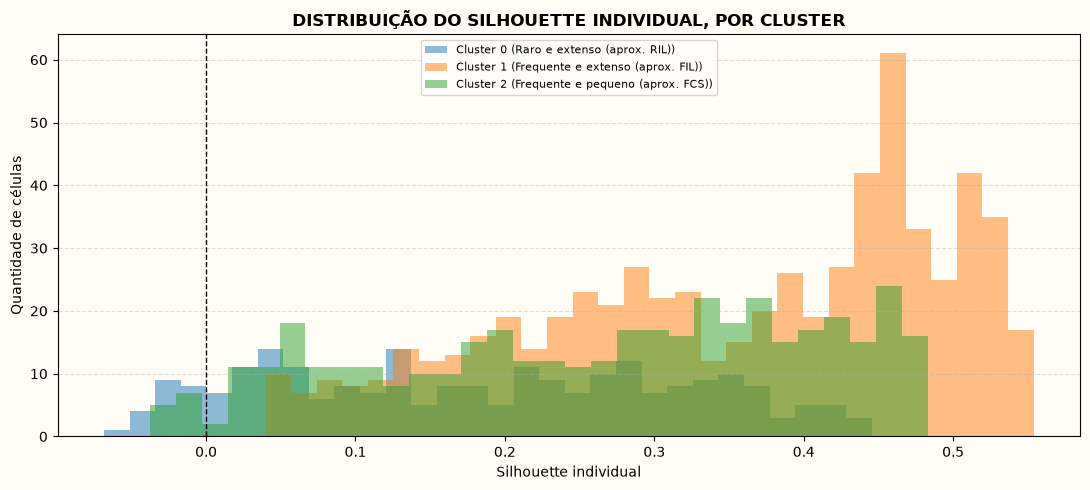

In [104]:
# Gráfico — distribuição do silhouette individual, por cluster

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#FFFDF5')
ax.set_facecolor('#FFFDF5')

for cluster_val in sorted(group_a_norm['cluster_kmeans'].unique()):
    subset = group_a_norm[group_a_norm['cluster_kmeans'] == cluster_val]['silhouette_individual']
    ax.hist(subset, bins=30, alpha=0.5, label=f'Cluster {cluster_val} ({cluster_names[cluster_val]})')

ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Silhouette individual')
ax.set_ylabel('Quantidade de células')
ax.set_title('DISTRIBUIÇÃO DO SILHOUETTE INDIVIDUAL, POR CLUSTER', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(PRINTS_DIR, "silhouette_individual_final.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

In [108]:
# Mapa final — regime de fogo classificado, com Grupo B incluído como dado insuficiente

final_colors = {
    'Raro e extenso (aprox. RIL)': '#264653',
    'Frequente e pequeno (aprox. FCS)': '#e9c46a',
    'Frequente e extenso (aprox. FIL)': '#e76f51',
    'Dado insuficiente': '#d9d9d9',
}

fire_regime_map_final = fire_regime_final.to_crs(4326)

Map = geemap.Map(center=[-14.2350, -51.9253], zoom=4)

Map.add_gdf(
    gdf_ucs_metric.to_crs(4326),
    layer_name="Limites das UCs",
    style={"color": "black", "fillOpacity": 0, "weight": 1},
    info_mode=None,
)

for label_val, color in final_colors.items():
    subset = fire_regime_map_final[fire_regime_map_final['fire_regime_final'] == label_val]

    tooltip_gdf = subset[[
        'fri_mean', 'frp_mean', 'n_months_80pct', 'size_max', 'annual_area_mean', 'bioma_pred', 'geometry'
    ]].rename(columns={
        'fri_mean': 'FRI médio (anos)',
        'frp_mean': 'FRP médio',
        'n_months_80pct': 'Sazonalidade (meses p/ 80%)',
        'size_max': 'Maior evento (ha)',
        'annual_area_mean': 'Área média anual (ha)',
        'bioma_pred': 'Bioma',
    })

    for col in ['FRI médio (anos)', 'FRP médio', 'Maior evento (ha)', 'Área média anual (ha)']:
        tooltip_gdf[col] = tooltip_gdf[col].round(2)

    Map.add_gdf(
        tooltip_gdf,
        layer_name=label_val,
        style={"color": color, "fillColor": color, "fillOpacity": 0.6, "weight": 0},
        info_mode="on_hover" if label_val != 'Dado insuficiente' else None,
    )

Map.add_legend(title="Regime de fogo", legend_dict=final_colors)
Map.add_basemap('HYBRID')
Map

Map(center=[-14.235, -51.9253], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topr…

In [105]:
# Top 10 UCs com mais células classificadas no Grupo A

cell_to_uc = cell_uc_membership.drop_duplicates(subset='cell_id')

classified_cells = fire_regime_final[fire_regime_final['fire_regime_final'] != 'Dado insuficiente']
classified_with_uc = classified_cells.merge(cell_to_uc, on='cell_id', how='left')

top10_ucs_classified_names = (
    classified_with_uc.groupby('cnuc').size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name='n_celulas_classificadas')
    .merge(gdf_ucs_metric[['cnuc', 'nomeuc']].drop_duplicates(), on='cnuc', how='left')
)

top10_ucs_classified_names

,cnuc,n_celulas_classificadas,nomeuc
0,0000.00.0156,110,PARQUE NACIONAL DAS NASCENTES DO RIO PARNAÍBA
1,0000.00.0076,101,ESTAÇÃO ECOLÓGICA SERRA GERAL DO TOCANTINS
2,0000.00.0266,91,FLORESTA NACIONAL DO JAMANXIM
3,0000.00.0168,74,PARQUE NACIONAL DO ARAGUAIA
4,0000.00.0284,47,PARQUE NACIONAL DOS CAMPOS AMAZÔNICOS
5,0000.00.0139,44,PARQUE NACIONAL DA CHAPADA DOS VEADEIROS
6,0000.00.0206,34,RESERVA BIOLÓGICA DO GUAPORÉ
7,0000.00.0024,33,ÁREA DE PROTEÇÃO AMBIENTAL DOS MEANDROS DO RIO...
8,0000.00.0144,32,PARQUE NACIONAL DA SERRA DA CANASTRA
9,0000.00.0272,30,PARQUE NACIONAL DA CHAPADA DAS MESAS


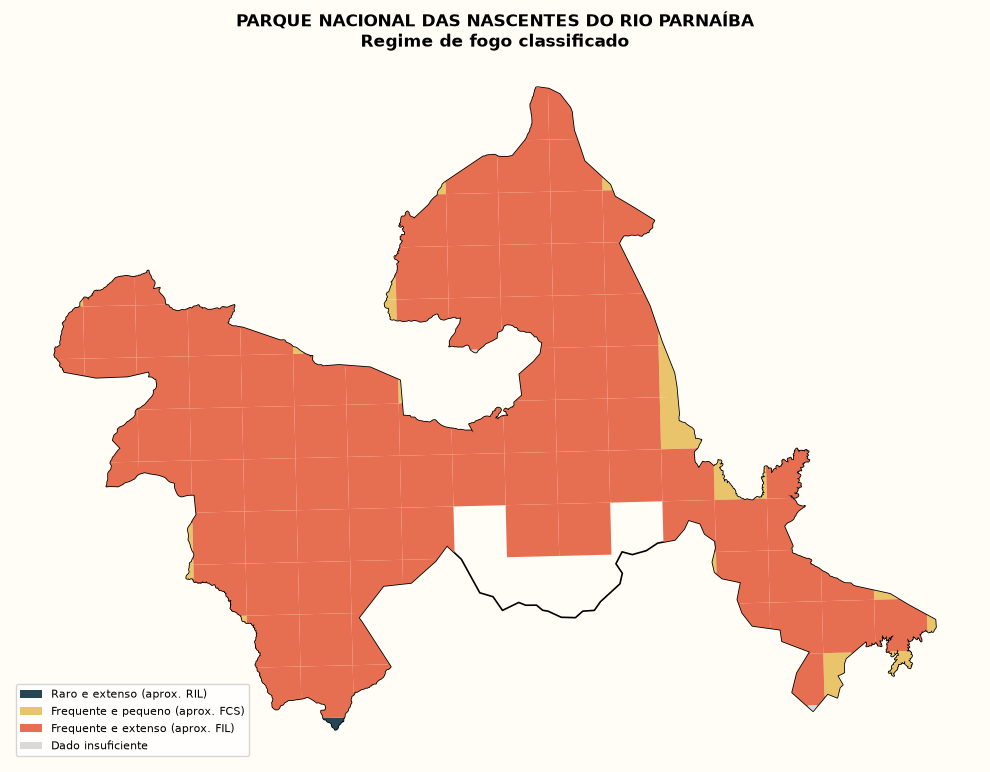

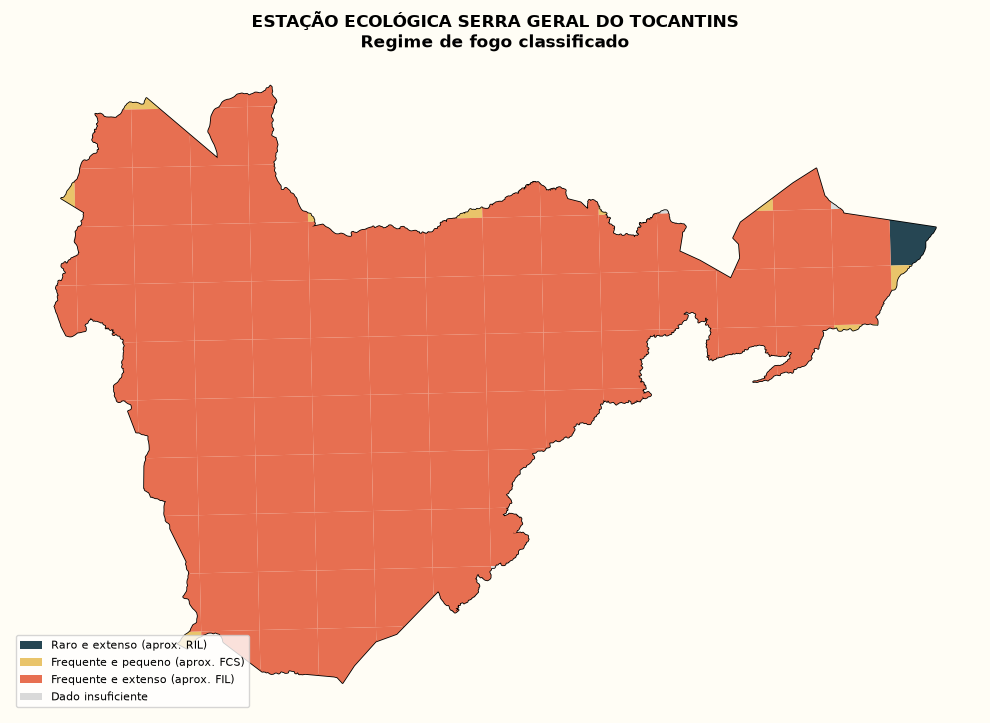

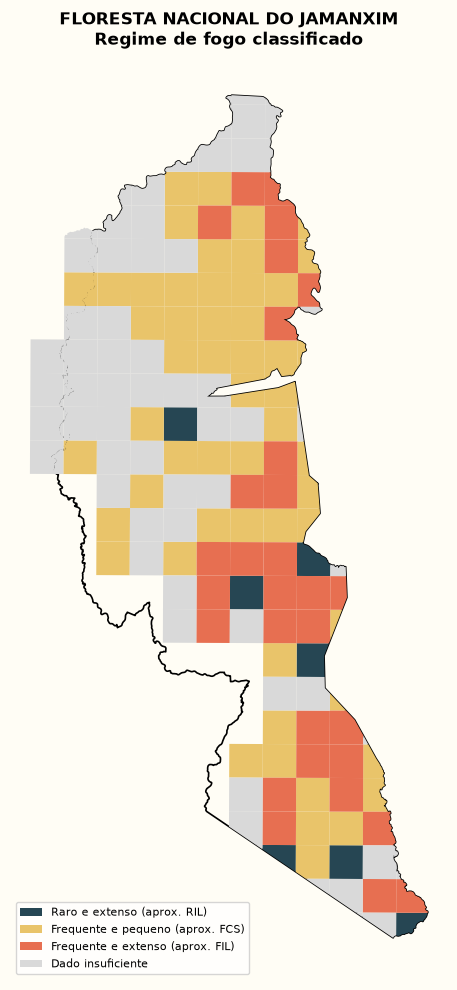

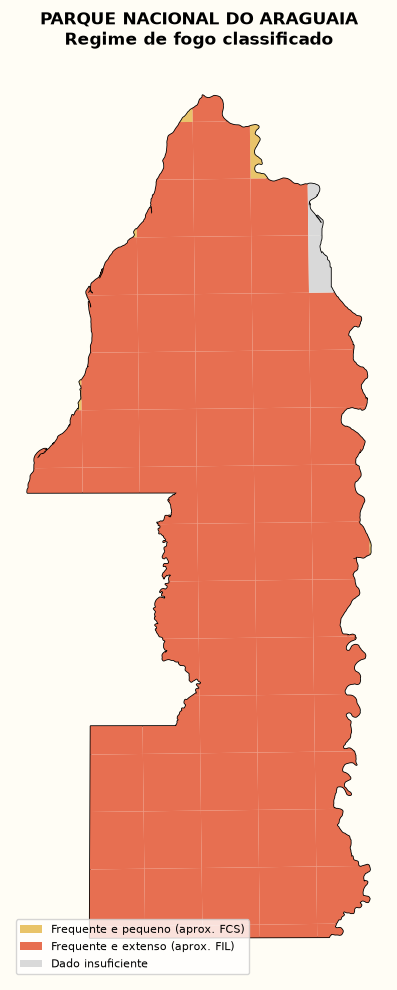

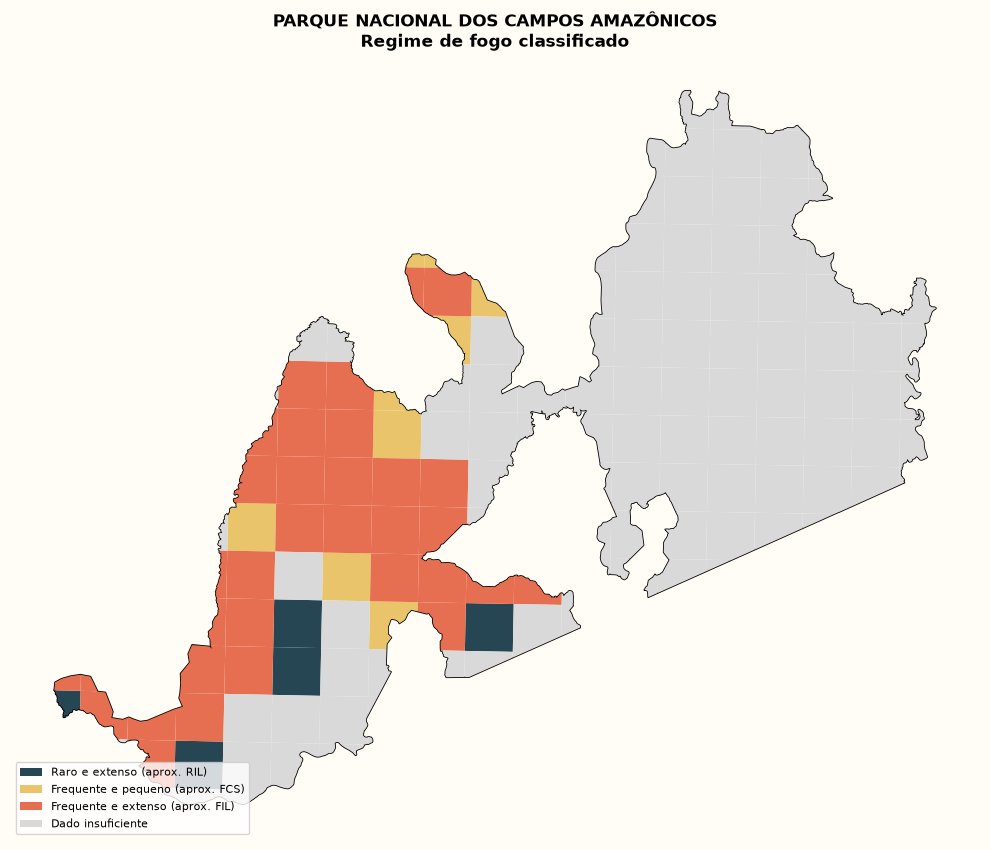

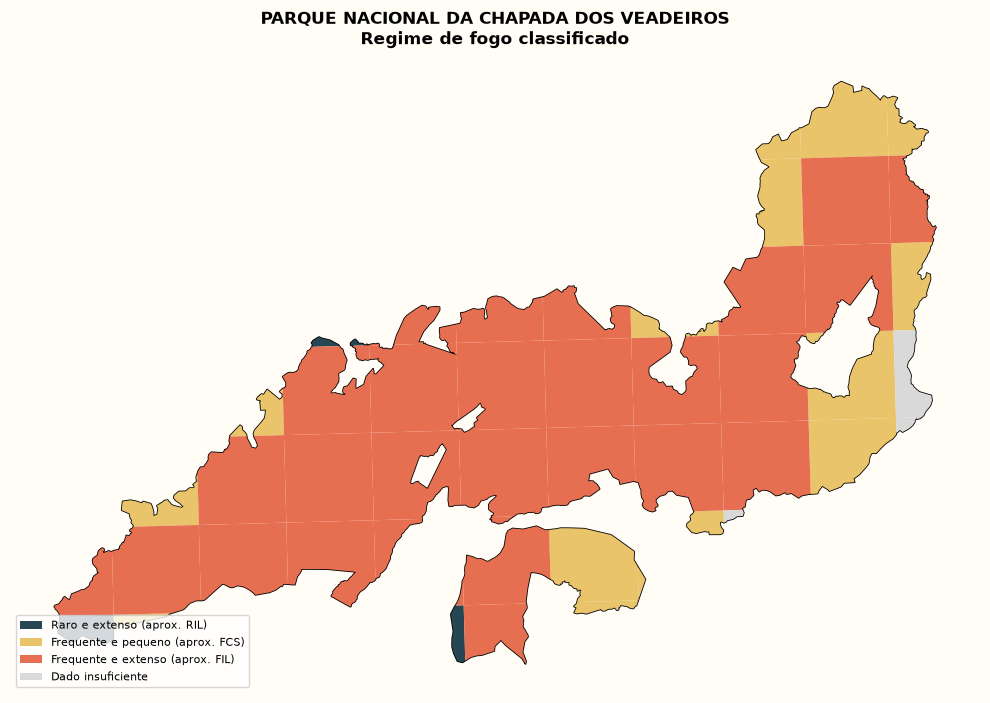

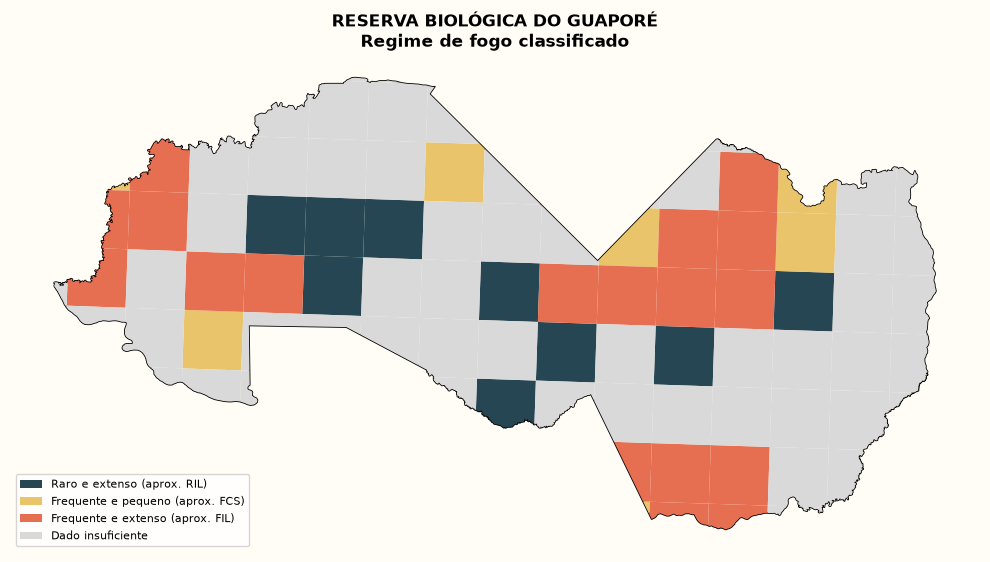

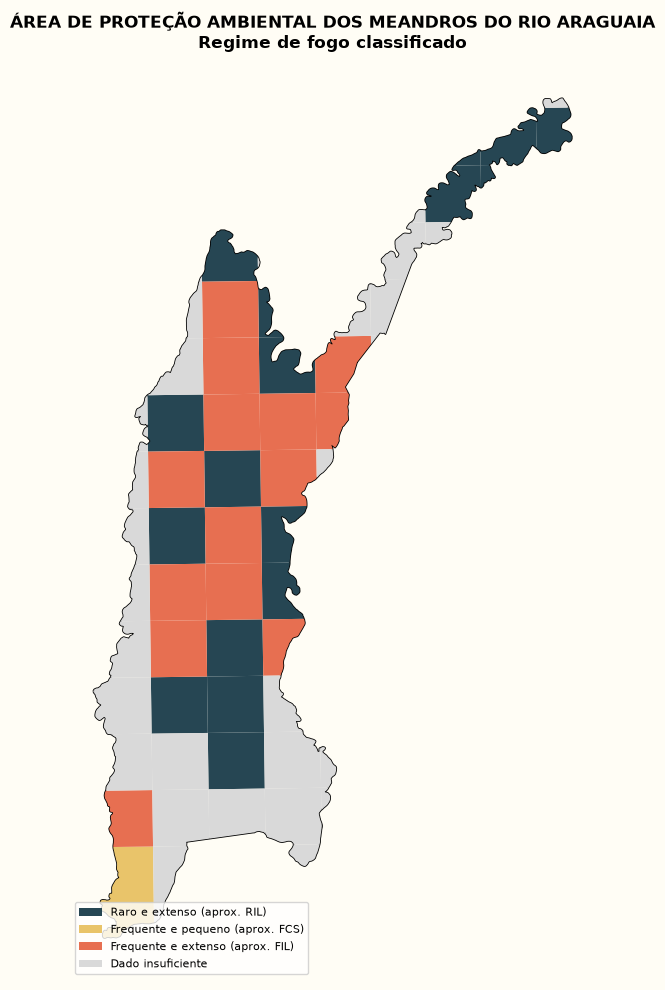

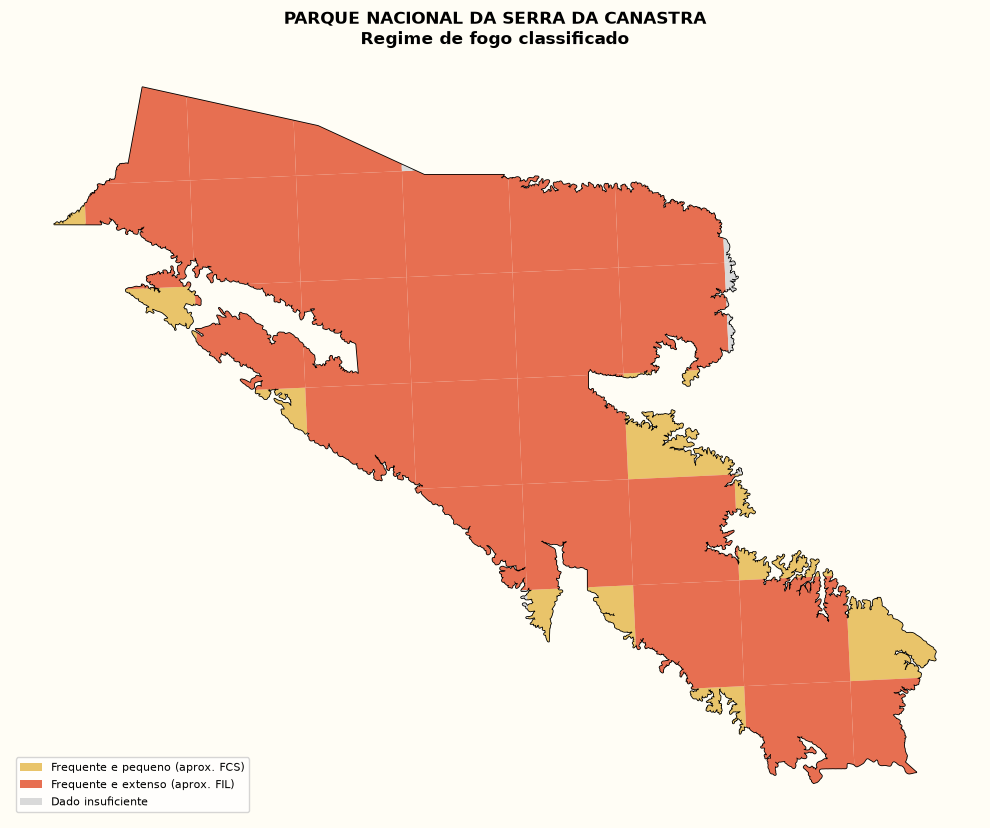

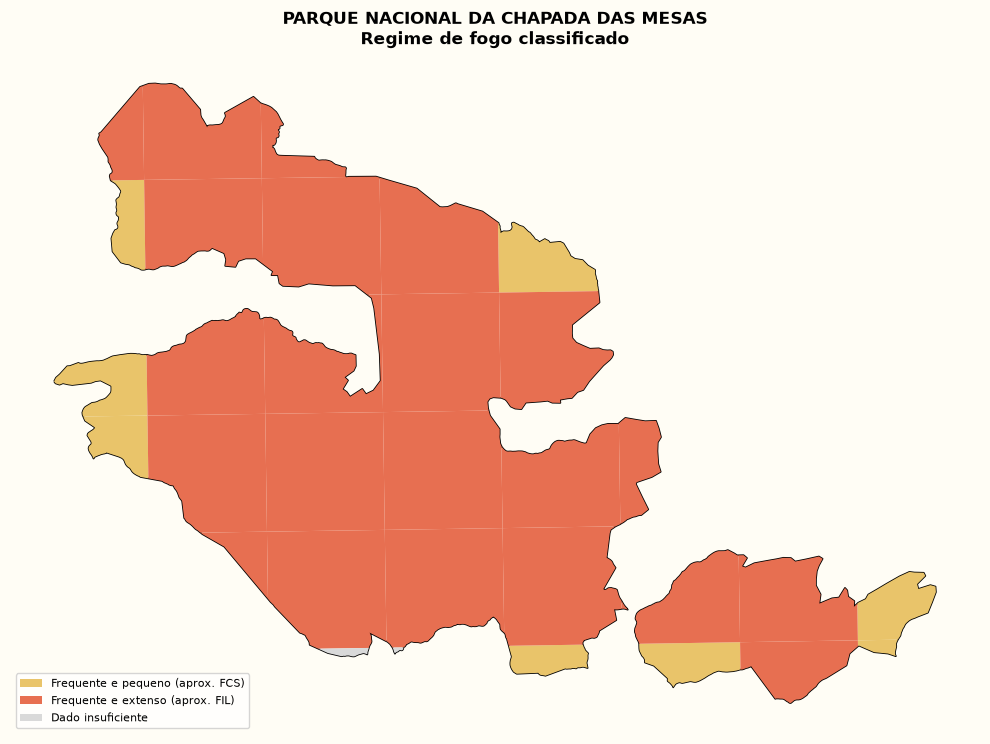

In [109]:
# Gerar um mapa estático recortado por UC, para cada uma das top 10

for _, row in top10_ucs_classified_names.iterrows():

    uc_code = row['cnuc']
    uc_name = row['nomeuc']

    uc_boundary = gdf_ucs_metric[gdf_ucs_metric['cnuc'] == uc_code].to_crs(4326)
    uc_cells = fire_regime_map_final[
        fire_regime_map_final['cell_id'].isin(
            cell_to_uc[cell_to_uc['cnuc'] == uc_code]['cell_id']
        )
    ]

    fig, ax = plt.subplots(figsize=(10, 10))
    fig.patch.set_facecolor('#FFFDF5')
    ax.set_facecolor('#FFFDF5')

    uc_boundary.boundary.plot(ax=ax, color='black', linewidth=1.2, zorder=1)

    for label_val, color in final_colors.items():
        subset = uc_cells[uc_cells['fire_regime_final'] == label_val]
        if len(subset) > 0:
            subset.plot(ax=ax, color=color, label=label_val, zorder=2)

    ax.set_title(f'{uc_name}\nRegime de fogo classificado', fontweight='bold', fontsize=12)
    ax.set_axis_off()
    ax.legend(loc='lower left', fontsize=8)

    plt.tight_layout()

    safe_filename = uc_code.replace('.', '_')
    plt.savefig(
        os.path.join(PRINTS_DIR, f"mapa_uc_{safe_filename}.png"),
        dpi=200, bbox_inches='tight', facecolor='#FFFDF5'
    )
    plt.show()

In [110]:
# Persistência final — resultado definitivo do projeto

OUTPUTS_DIR = os.path.join(FILES_DIR, "prepared")

fire_regime_final.to_parquet(os.path.join(OUTPUTS_DIR, "fire_regime_vector_final.parquet"))

print("Salvo em:", os.path.join(OUTPUTS_DIR, "fire_regime_vector_final.parquet"))
print(f"Tamanho: {os.path.getsize(os.path.join(OUTPUTS_DIR, 'fire_regime_vector_final.parquet')) / 1e6:.1f} MB")

Salvo em: files\prepared\fire_regime_vector_final.parquet
Tamanho: 24.0 MB


# Conclusão

O projeto percorreu um caminho completo, da coleta de dados brutos de três fontes distintas até uma classificação de regime de fogo célula a célula nas Unidades de Conservação, testada, comparada entre algoritmos, e validada com múltiplas métricas. Ao longo do processo, diversas decisões metodológicas precisaram ser tomadas e justificadas, tamanho de célula, thresholds de robustez, tratamento de ausência de dado, escolha de algoritmo, cada uma documentada com o raciocínio por trás, não como escolha arbitrária.

A limitação central identificada, cobertura de dado confiável em torno de 5,7% da grade, foi tratada de forma honesta ao longo de todo o trabalho, sem forçar uma classificação onde a evidência não sustentava, resultando na segmentação entre Grupo A e Grupo B. O diagnóstico final, mostrando o AAF como principal gargalo dessa cobertura, deixa um caminho concreto e documentado pra evolução futura do projeto, incorporando outras fontes de área queimada por satélite.

A convergência entre K-means e clustering hierárquico, dois algoritmos de lógica distinta encontrando o mesmo padrão de três grupos, é o resultado mais robusto que o projeto produziu, dando confiança de que a estrutura de regimes de fogo encontrada reflete algo real nos dados, não um artefato de escolha metodológica.

---
**Sobre o artigo de referência**

O trabalho se inspira na lógica de Archibald et al., caracterizar território pelo comportamento do fogo, não pela vegetação ou clima, usando as mesmas cinco variáveis centrais, frequência, intensidade, sazonalidade, tamanho e extensão média. Mas o resultado não pretende, e não deveria pretender, replicar os cinco pyromas do artigo original.

A diferença de escala é fundamental, o artigo trabalha com dado global, décadas de série histórica, cruzando savanas tropicais, florestas boreais e região mediterrânea. Este projeto trabalha com um recorte muito mais restrito, Unidades de Conservação brasileiras, concentradas principalmente em Cerrado e Amazônia pela limitação dos dados, com apenas 16 anos de série confiável. É esperado, e metodologicamente correto, que menos diversidade de contexto resulte em menos grupos distintos, três em vez de cinco, e a escolha de K não foi forçada pra bater com o artigo, foi decidida pelos próprios dados, através de métrica estatística.

A aproximação nomeada aos pyromas, FIL, FCS, RIL, serve como ponte conceitual pra situar o resultado dentro da literatura existente, sem alegar equivalência exata. O projeto entrega, com essa ressalva registrada, uma primeira caracterização de regime de fogo pra UCs federais brasileiras, com metodologia documentada, limitações explícitas, e um caminho claro de continuidade pra ampliar robustez e cobertura em versões futuras.